# Experiment 0.2 — Endpoint Tail Regularization

Analysis-only notebook. It reads finalized Exp0.2 artifacts; training and Slurm submission live in the experiment scripts.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO_ROOT = Path('..').resolve()
ARTIFACT_ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_0_2_endpoint_tail_regularization' / 'endpoint_tail_regularization_v1'
DISPLAY_SEED = 11
SAMPLE_INDEX = 4


In [2]:
manifest = json.loads((ARTIFACT_ROOT / 'manifest.json').read_text())
summary = pd.read_csv(ARTIFACT_ROOT / 'summary.csv')
comparison = pd.read_csv(ARTIFACT_ROOT / 'comparison_summary.csv')
paired = pd.read_csv(ARTIFACT_ROOT / 'paired_vs_frozen_exp01.csv')
calibration = pd.read_csv(ARTIFACT_ROOT / 'calibration_summary.csv')
history = pd.read_csv(ARTIFACT_ROOT / 'history_long.csv')
raster_index = pd.read_csv(ARTIFACT_ROOT / 'raster_index.csv')
manifest


{'architectures': ['short_mid_long', 'short_mid', 'mid_long'],
 'epochs_new_runs': 50,
 'experiment_id': 'experiment_0_2_endpoint_tail_regularization',
 'frozen_evaluation_count': 18,
 'frozen_source': 'experiment_0_1_general_comparison/general_comparison_v1',
 'gradient_calibration': {'batches': 5,
  'scope': 'hidden linear weights only',
  'target_ratio': 0.05,
  'warmup_epochs': 10},
 'new_run_count': 72,
 'objectives': ['whole_count_ce', 'timestep_ce'],
 'profiles': ['none', 'a1', 'a1_p2', 'tail', 'a1_tail'],
 'protocol_version': 'endpoint_tail_regularization_v1',
 'raster': {'final_hidden_order': 'native neuron order grouped by configured synaptic shift',
  'panels': ['final_hidden_spikes', 'output_spikes'],
  'test_sample_index': 4,
  'x_axis': 'valid segment plus 600-ms zero-input rollout'},
 'regularization': {'a1': '0.1 * Exp0.1.5 all-fixes valid hidden activity',
  'a1_p2': '0.1*A1 + 0.01*Exp0.1.5 all-fixes P2',
  'a1_tail': '0.1*A1 + 0.1*tail',
  'tail': '0.1 * normalized en

## Classification / settling tradeoff

The primary view keeps test balanced accuracy and final-hidden settling behavior visible together.

In [3]:
display_cols = [
    'architecture', 'objective', 'profile', 'seed',
    'test_balanced_accuracy', 'test_valid_hidden_activity',
    'test_tail_area_final_hidden', 'test_settling_ms_final_hidden_mean',
]
summary[display_cols].sort_values(['architecture', 'objective', 'profile', 'seed'])


,architecture,objective,profile,seed,test_balanced_accuracy,test_valid_hidden_activity,test_tail_area_final_hidden,test_settling_ms_final_hidden_mean
0,mid_long,timestep_ce,a1,11,0.137279,0.006251,0.764020,236.836473
1,mid_long,timestep_ce,a1,23,0.270804,0.030514,2.878639,515.089897
2,mid_long,timestep_ce,a1,37,0.101190,0.000678,0.029377,54.152397
3,mid_long,timestep_ce,a1_p2,11,0.130411,0.004955,0.594767,217.251712
4,mid_long,timestep_ce,a1_p2,23,0.249646,0.031034,2.995559,514.768836
...,...,...,...,...,...,...,...,...
85,short_mid_long,whole_count_ce,none,23,0.231471,0.031527,3.830854,347.281678
86,short_mid_long,whole_count_ce,none,37,0.223961,0.032782,4.279859,335.616438
87,short_mid_long,whole_count_ce,tail,11,0.152965,0.008518,0.962008,183.112158
88,short_mid_long,whole_count_ce,tail,23,0.142316,0.013662,1.372967,209.867295


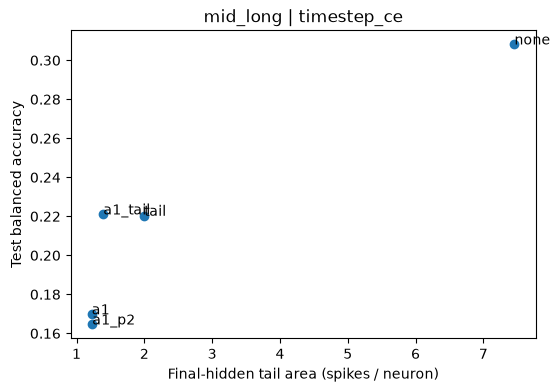

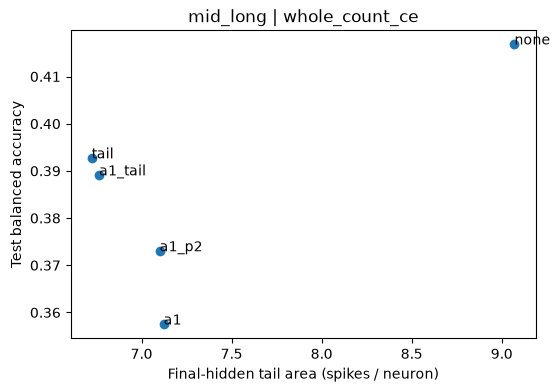

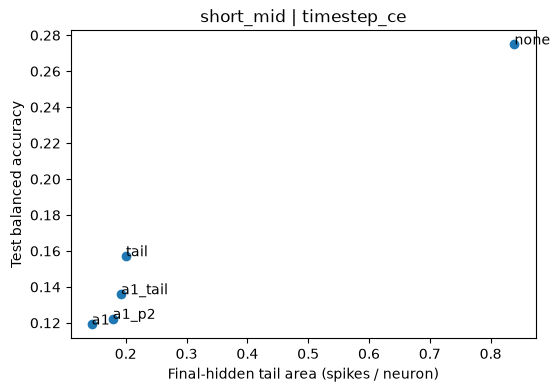

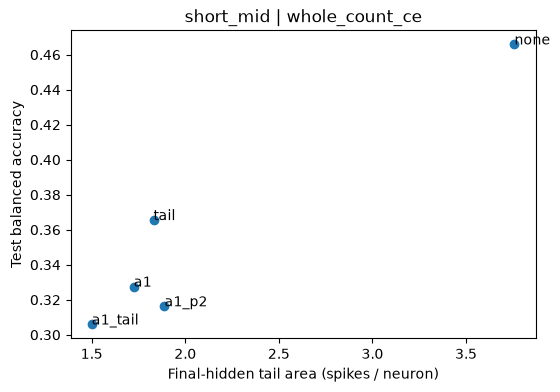

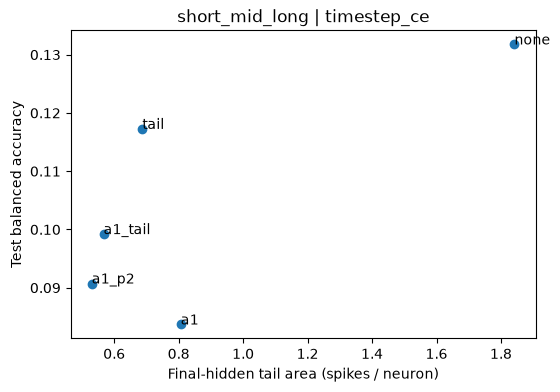

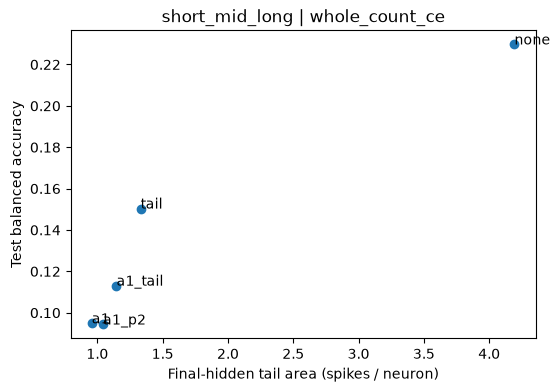

In [4]:
for (architecture, objective), frame in summary.groupby(['architecture', 'objective']):
    means = frame.groupby('profile', as_index=False)[['test_tail_area_final_hidden', 'test_balanced_accuracy']].mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(means['test_tail_area_final_hidden'], means['test_balanced_accuracy'])
    for row in means.itertuples(index=False):
        ax.annotate(row.profile, (row.test_tail_area_final_hidden, row.test_balanced_accuracy))
    ax.set_xlabel('Final-hidden tail area (spikes / neuron)')
    ax.set_ylabel('Test balanced accuracy')
    ax.set_title(f'{architecture} | {objective}')
    plt.show()


## Paired deltas versus frozen Exp0.1


In [5]:
paired.groupby(['architecture', 'objective', 'profile'])[[
    'delta_test_ba_vs_frozen_exp01',
    'delta_tail_area_vs_frozen_exp01',
    'delta_settling_ms_vs_frozen_exp01',
]].agg(['mean', 'std'])


delta_test_ba_vs_frozen_exp01            \
                                                               mean       std   
architecture   objective      profile                                           
mid_long       timestep_ce    a1                          -0.138334  0.076298   
                              a1_p2                       -0.143556  0.068902   
                              a1_tail                     -0.087134  0.035222   
                              tail                        -0.087822  0.052901   
               whole_count_ce a1                          -0.059331  0.043320   
                              a1_p2                       -0.043809  0.090956   
                              a1_tail                     -0.027740  0.032795   
                              tail                        -0.024134  0.026217   
short_mid      timestep_ce    a1                          -0.155769  0.070704   
                              a1_p2                       -0.152603  0.056962   
                              a1_tail                     -0.138950  0.050797   
                              tail                        -0.117802  0.024089   
               whole_count_ce a1                          -0.138280  0.056289   
                              a1_p2                       -0.149527  0.013026   
                              a1_tail                     -0.159930  0.009565   
                              tail                        -0.100298  0.016608   
short_mid_long timestep_ce    a1                          -0.048052  0.029307   
                              a1_p2                       -0.041017  0.025268   
                              a1_tail                     -0.032540  0.031827   
                              tail                        -0.014488  0.014473   
               whole_count_ce a1                          -0.134819  0.014811   
                              a1_p2                       -0.135360  0.009472   
                              a1_tail                     -0.116601  0.033882   
                              tail                        -0.079328  0.010523   

                                      delta_tail_area_vs_frozen_exp01  \
                                                                 mean   
architecture   objective      profile                                   
mid_long       timestep_ce    a1                            -6.235017   
                              a1_p2                         -6.227633   
                              a1_tail                       -6.064016   
                              tail                          -5.460545   
               whole_count_ce a1                            -1.948184   
                              a1_p2                         -1.970373   
                              a1_tail                       -2.306560   
                              tail                          -2.347300   
short_mid      timestep_ce    a1                            -0.695116   
                              a1_p2                         -0.660674   
                              a1_tail                       -0.646904   
                              tail                          -0.638895   
               whole_count_ce a1                            -2.034318   
                              a1_p2                         -1.870095   
                              a1_tail                       -2.258794   
                              tail                          -1.928831   
short_mid_long timestep_ce    a1                            -1.035388   
                              a1_p2                         -1.311519   
                              a1_tail                       -1.274989   
                              tail                          -1.154520   
               whole_count_ce a1                            -3.236658   
                              a1_p2                         -3.150417   
                         

## Gradient calibration


In [6]:
calibration.groupby(['architecture', 'objective', 'profile'])[[
    'calibration_ratio_median', 'kappa'
]].agg(['mean', 'std'])


calibration_ratio_median            \
                                                          mean       std   
architecture   objective      profile                                      
mid_long       timestep_ce    a1                      0.017074  0.004935   
                              a1_p2                   0.017169  0.004984   
                              a1_tail                 0.046735  0.014746   
                              tail                    0.031069  0.010461   
               whole_count_ce a1                      0.031553  0.006412   
                              a1_p2                   0.031717  0.006467   
                              a1_tail                 0.087225  0.019518   
                              tail                    0.058025  0.014760   
short_mid      timestep_ce    a1                      0.052622  0.046468   
                              a1_p2                   0.052801  0.046625   
                              a1_tail                 0.078749  0.066939   
                              tail                    0.029246  0.021342   
               whole_count_ce a1                      0.092297  0.048268   
                              a1_p2                   0.092680  0.048526   
                              a1_tail                 0.135987  0.076231   
                              tail                    0.058650  0.034935   
short_mid_long timestep_ce    a1                      0.010167  0.001832   
                              a1_p2                   0.010276  0.001867   
                              a1_tail                 0.030083  0.006644   
                              tail                    0.021662  0.005815   
               whole_count_ce a1                      0.013258  0.001332   
                              a1_p2                   0.013400  0.001353   
                              a1_tail                 0.039032  0.006576   
                              tail                    0.028548  0.005679   

                                          kappa            
                                           mean       std  
architecture   objective      profile                      
mid_long       timestep_ce    a1       3.079841  0.789474  
                              a1_p2    3.064053  0.788445  
                              a1_tail  1.137463  0.324620  
                              tail     1.729574  0.543956  
               whole_count_ce a1       1.635338  0.374391  
                              a1_p2    1.627287  0.374190  
                              a1_tail  0.595921  0.152220  
                              tail     0.907196  0.268593  
short_mid      timestep_ce    a1       1.516448  1.028591  
                              a1_p2    1.511438  1.025455  
                              a1_tail  0.984570  0.661636  
                              tail     2.386848  1.485819  
               whole_count_ce a1       0.655394  0.341537  
                              a1_p2    0.652975  0.340610  
                              a1_tail  0.478388  0.311667  
                              tail     1.222450  0.968159  
short_mid_long timestep_ce    a1       5.016286  0.818639  
                              a1_p2    4.964376  0.816328  
                              a1_tail  1.713514  0.351032  
                              tail     2.416564  0.611557  
               whole_count_ce a1       3.796555  0.377169  
                              a1_p2    3.756428  0.372288  
                              a1_tail  1.305355  0.217753  
                              tail     1.795329  0.332256

## Fixed-sample firing rasters

All panels use test sample index 4 and include the valid window plus the fixed endpoint-relative zero-input rollout.

mid_long timestep_ce a1 seed 11


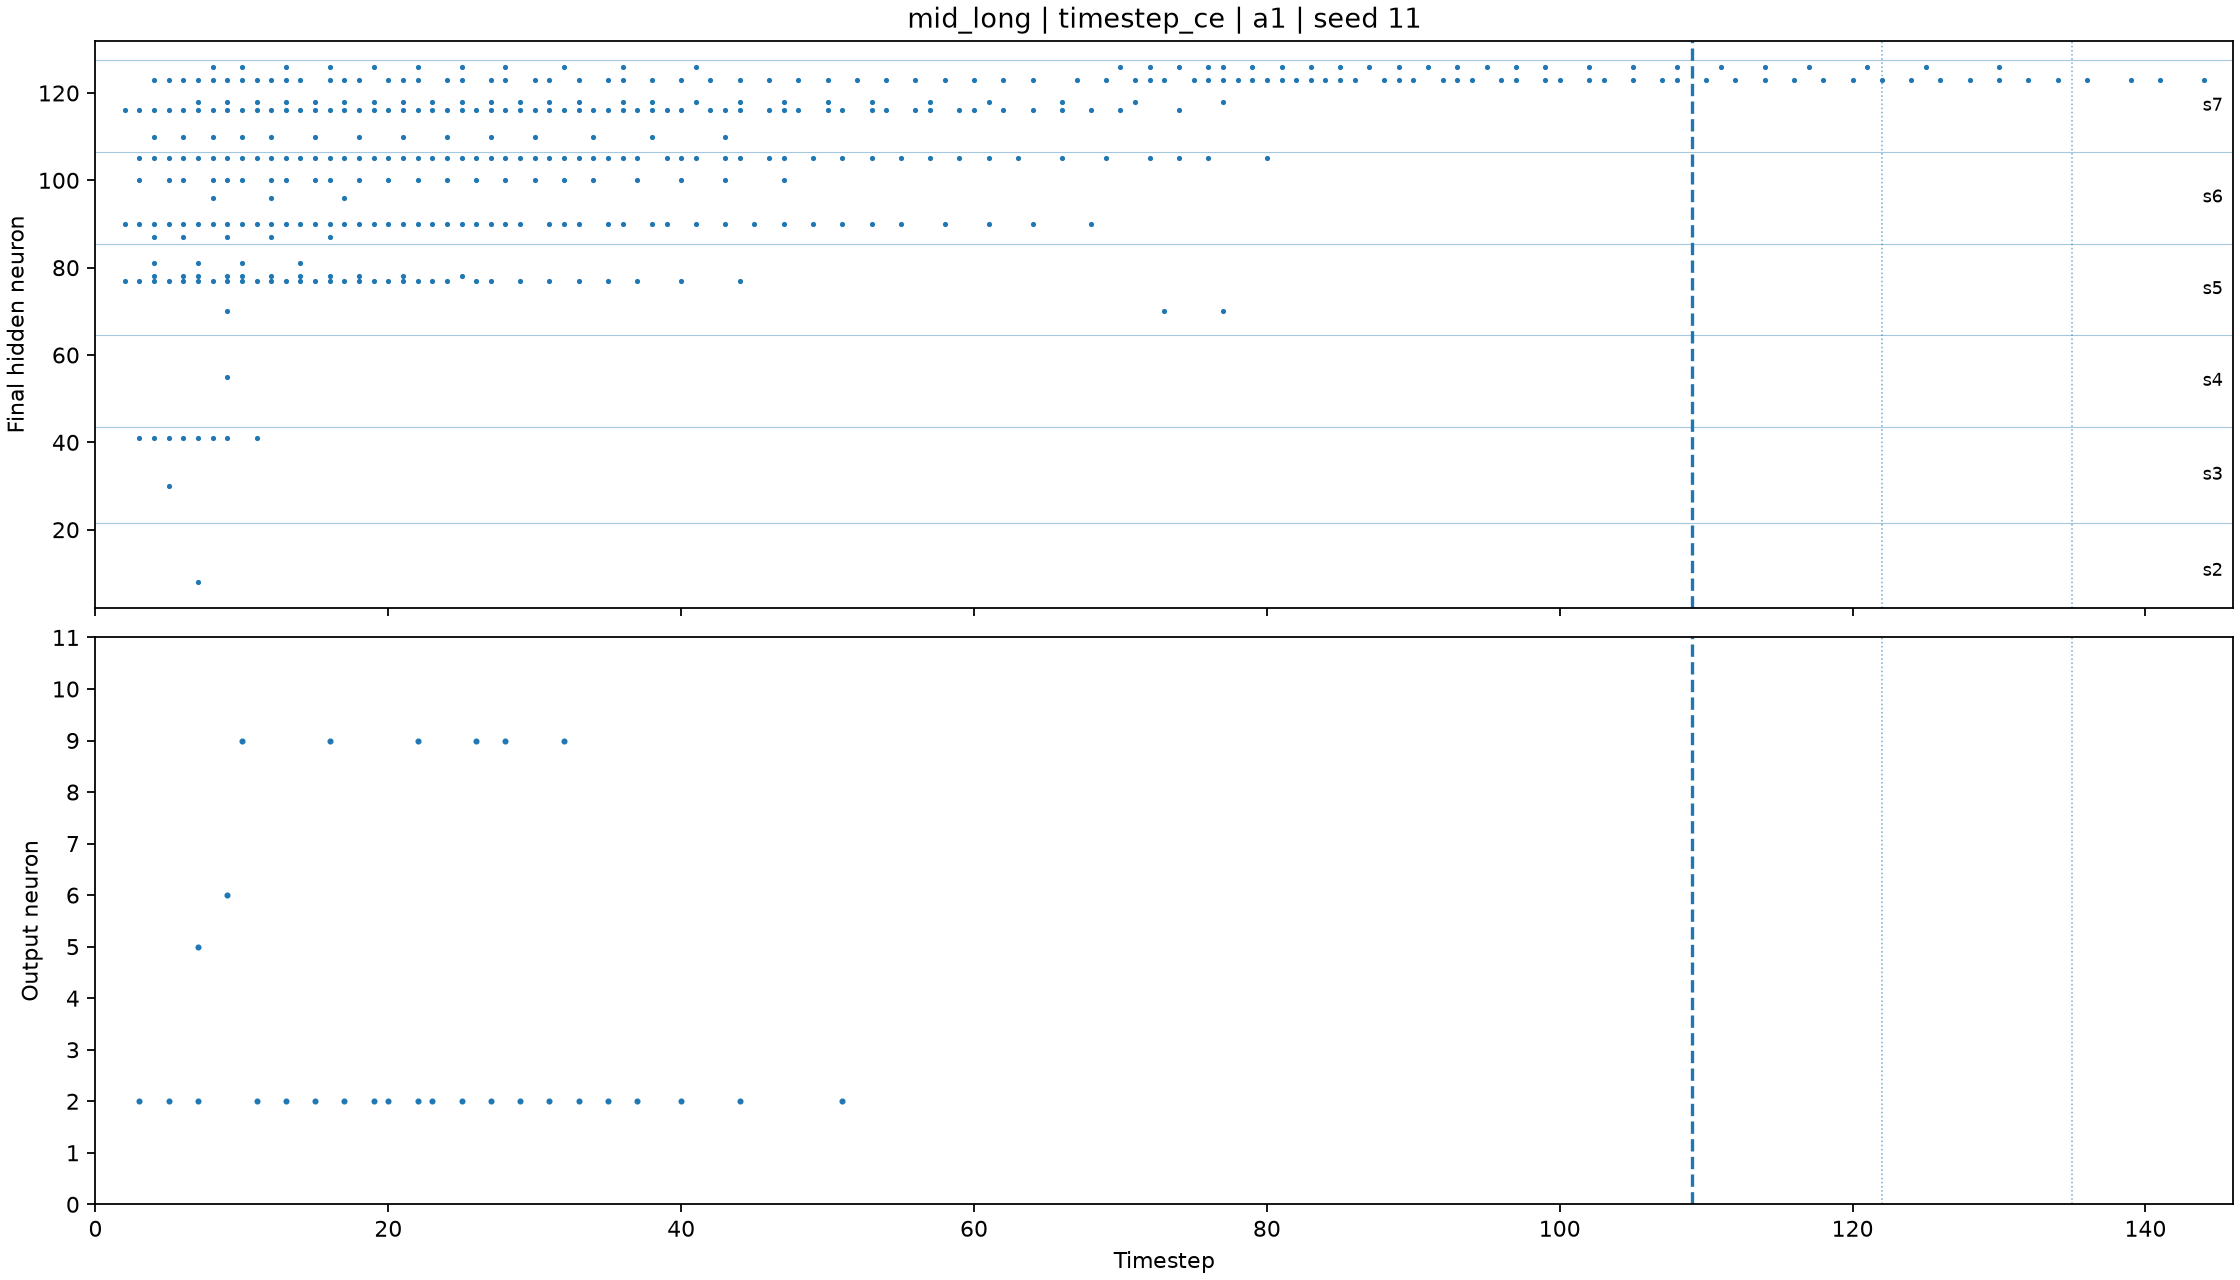

mid_long timestep_ce a1_p2 seed 11


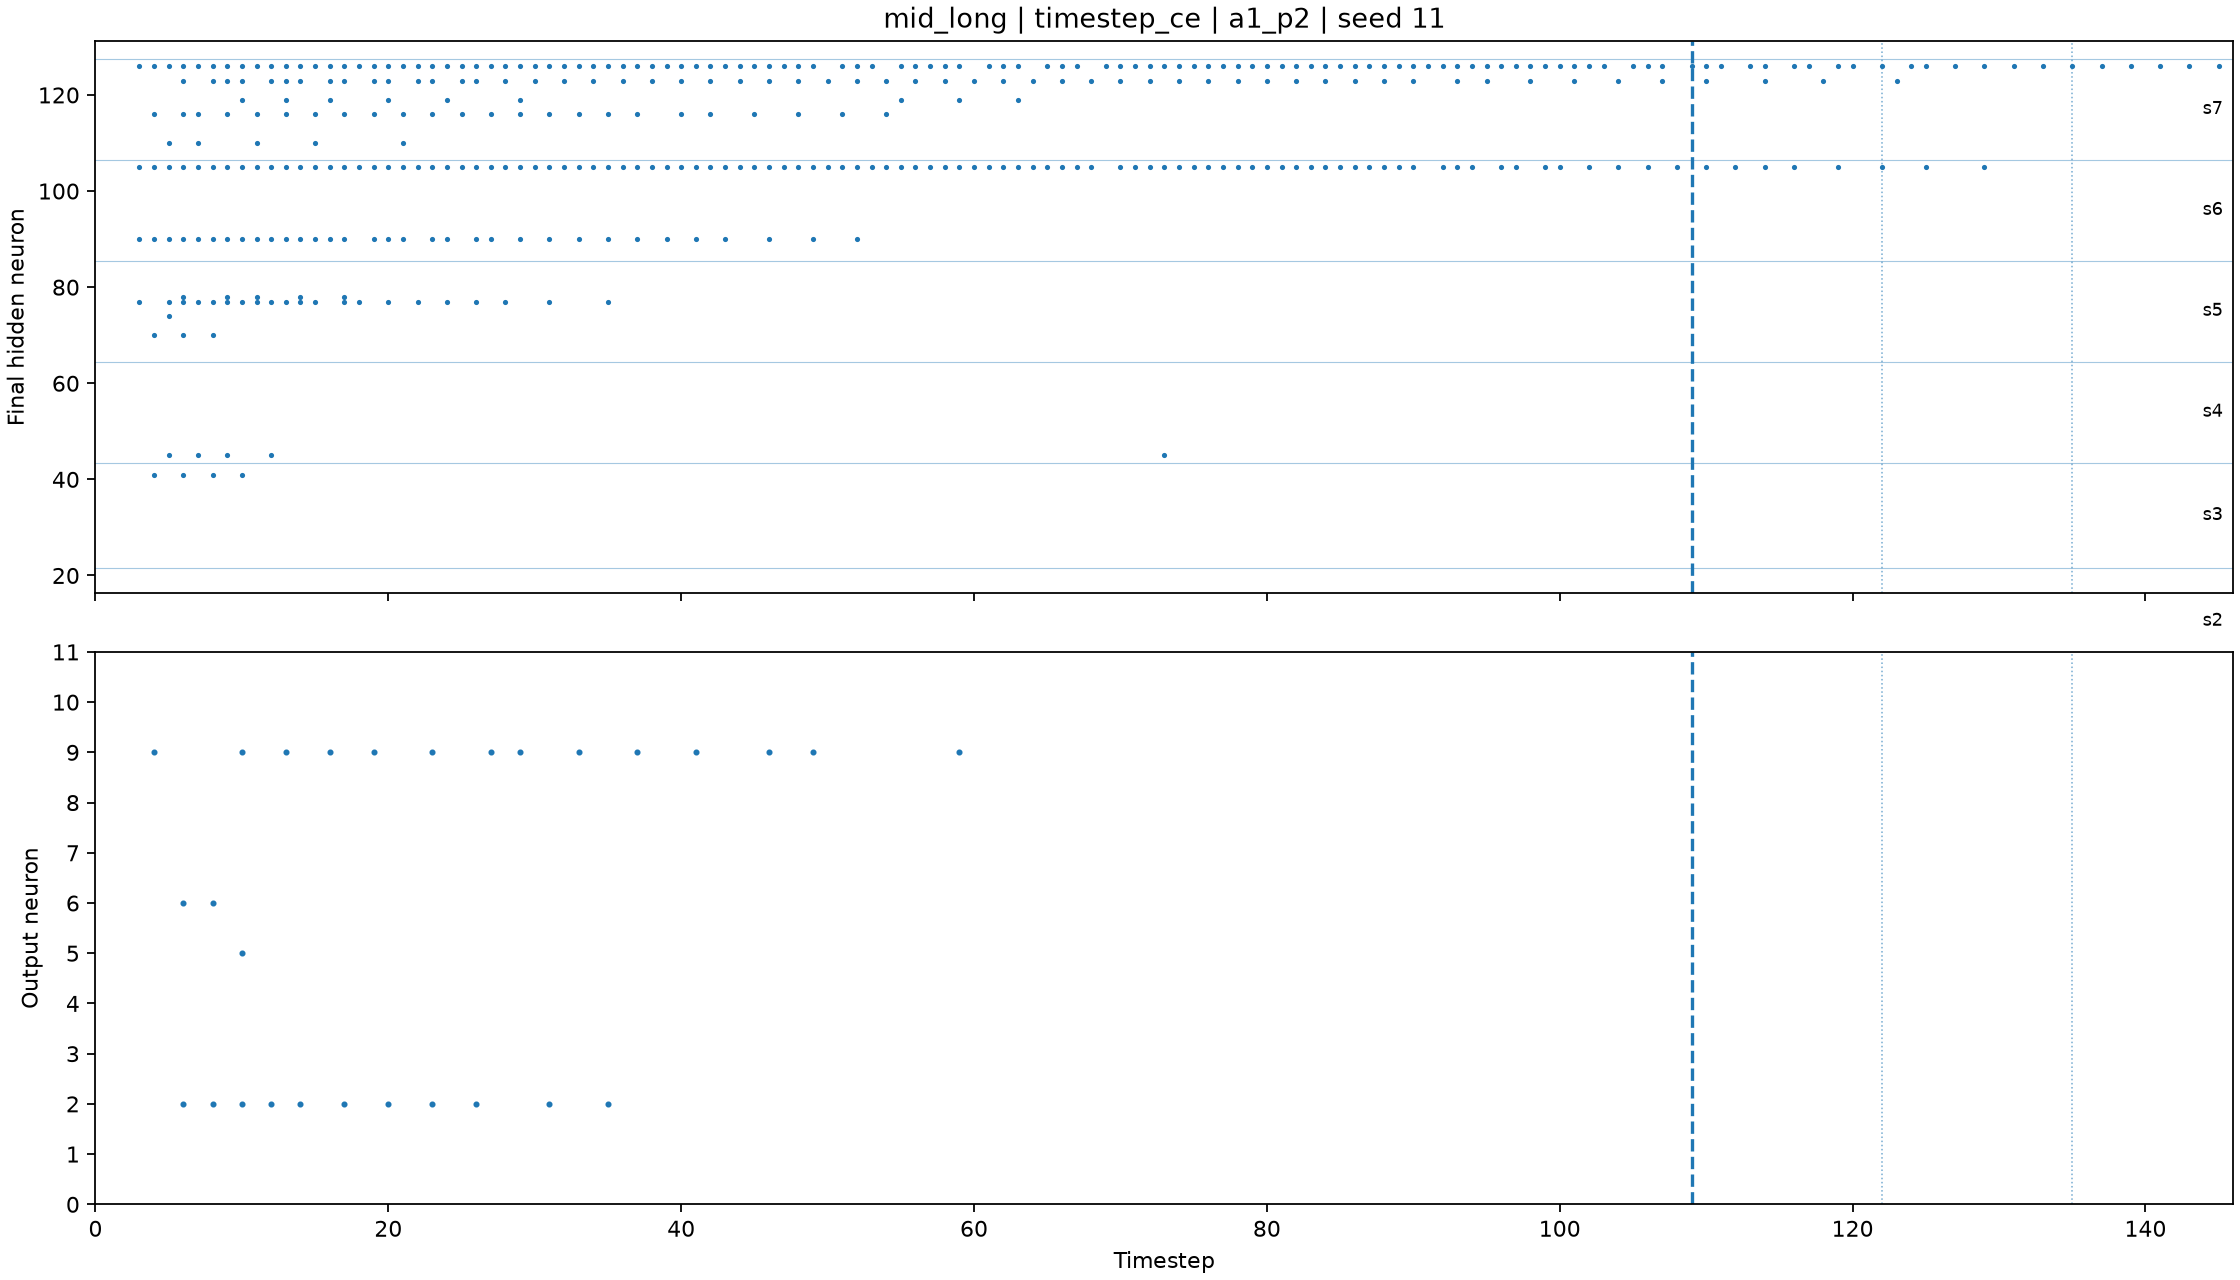

mid_long timestep_ce a1_tail seed 11


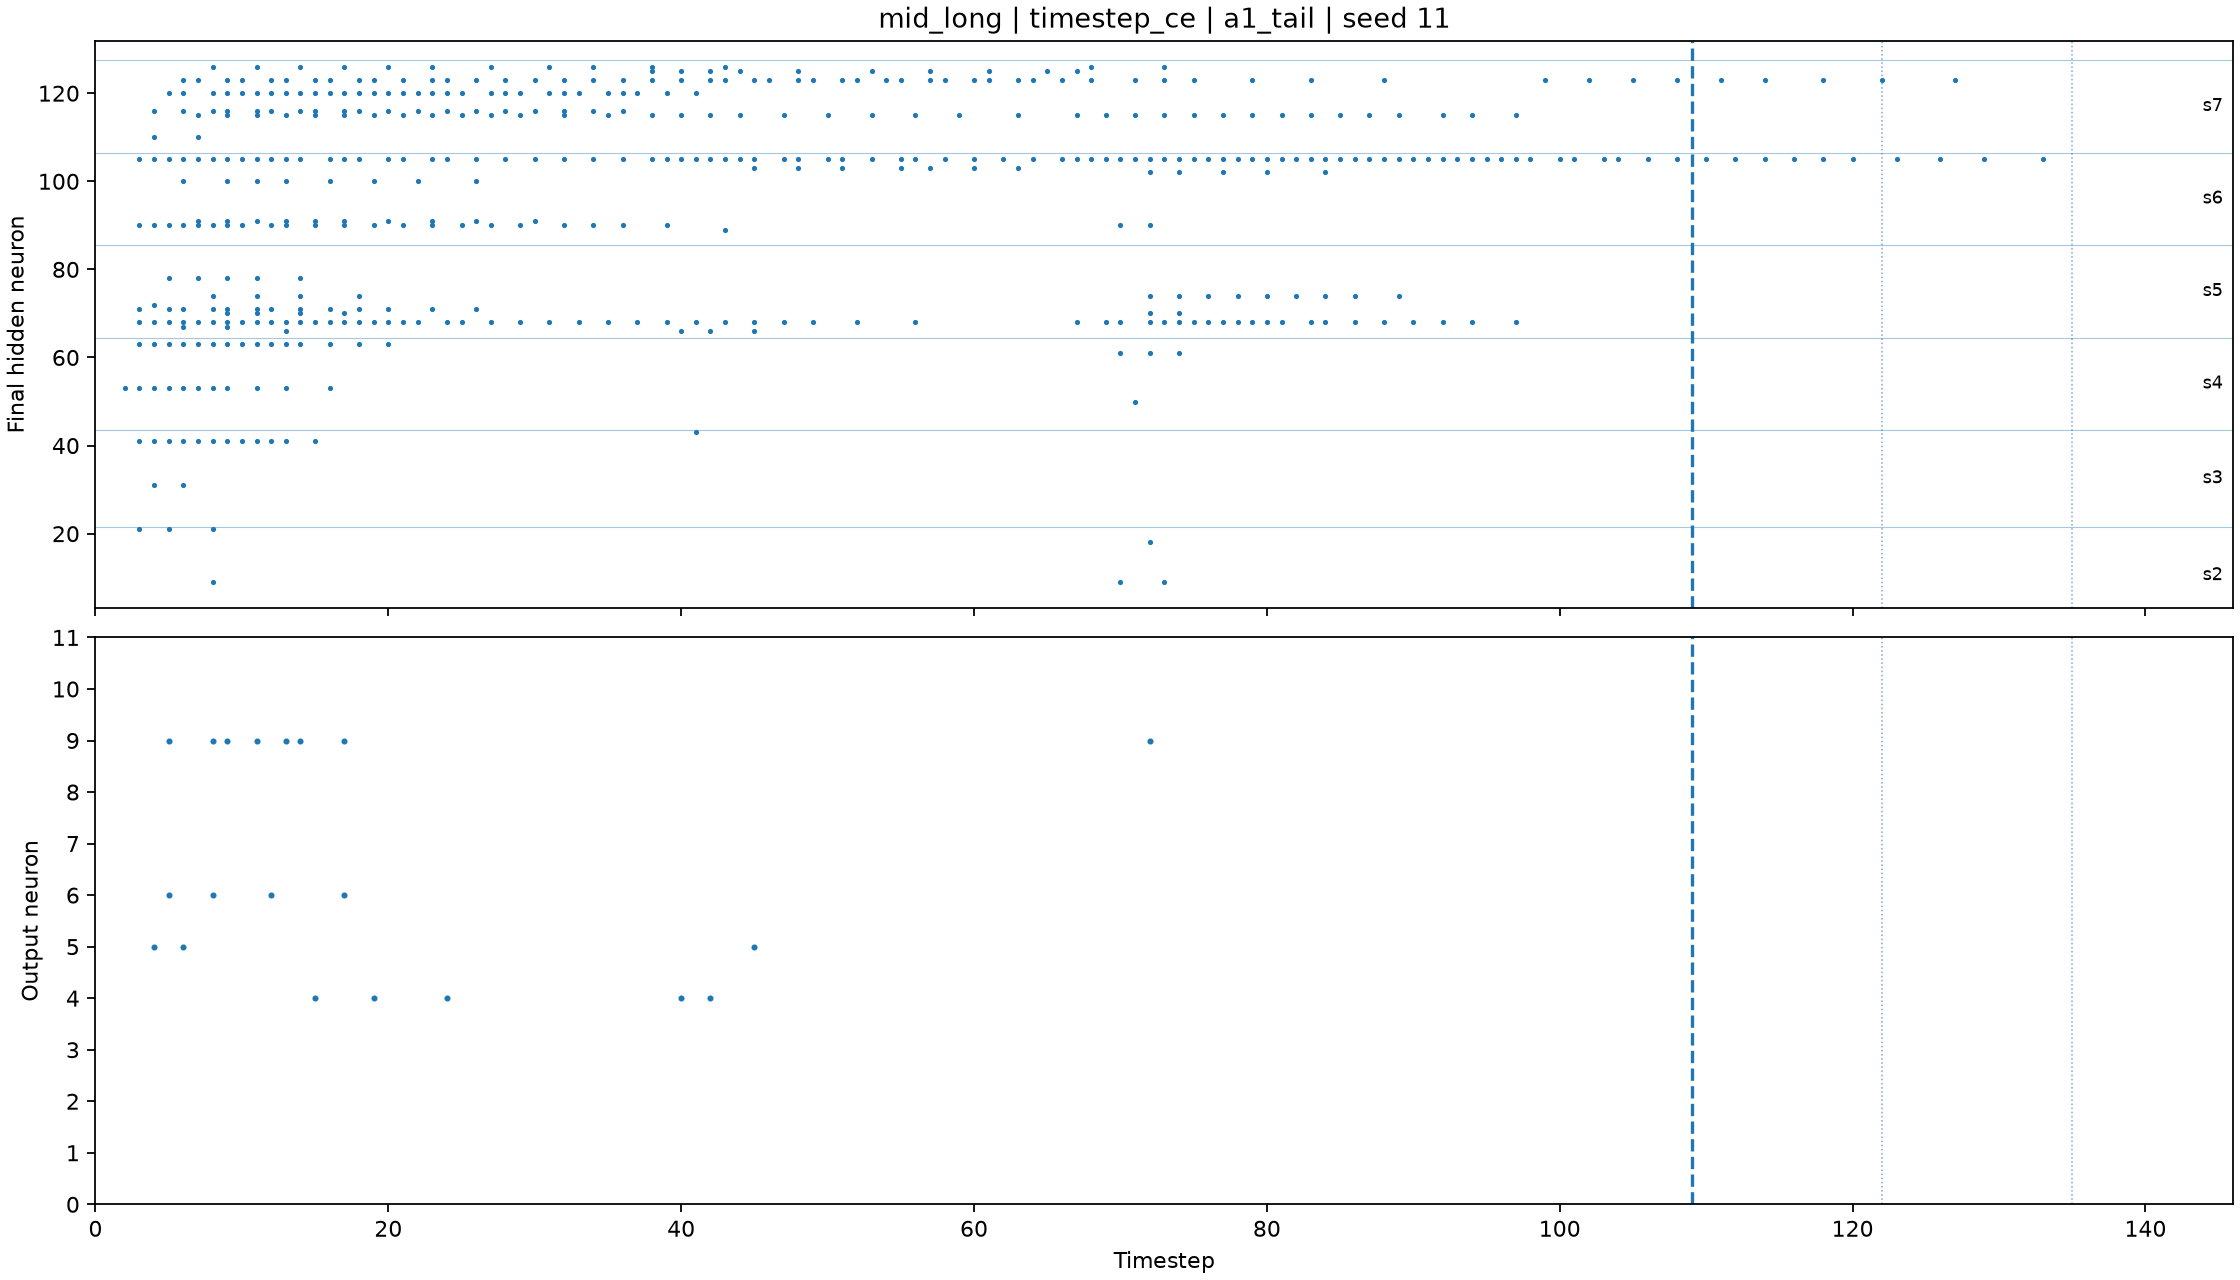

mid_long timestep_ce none seed 11


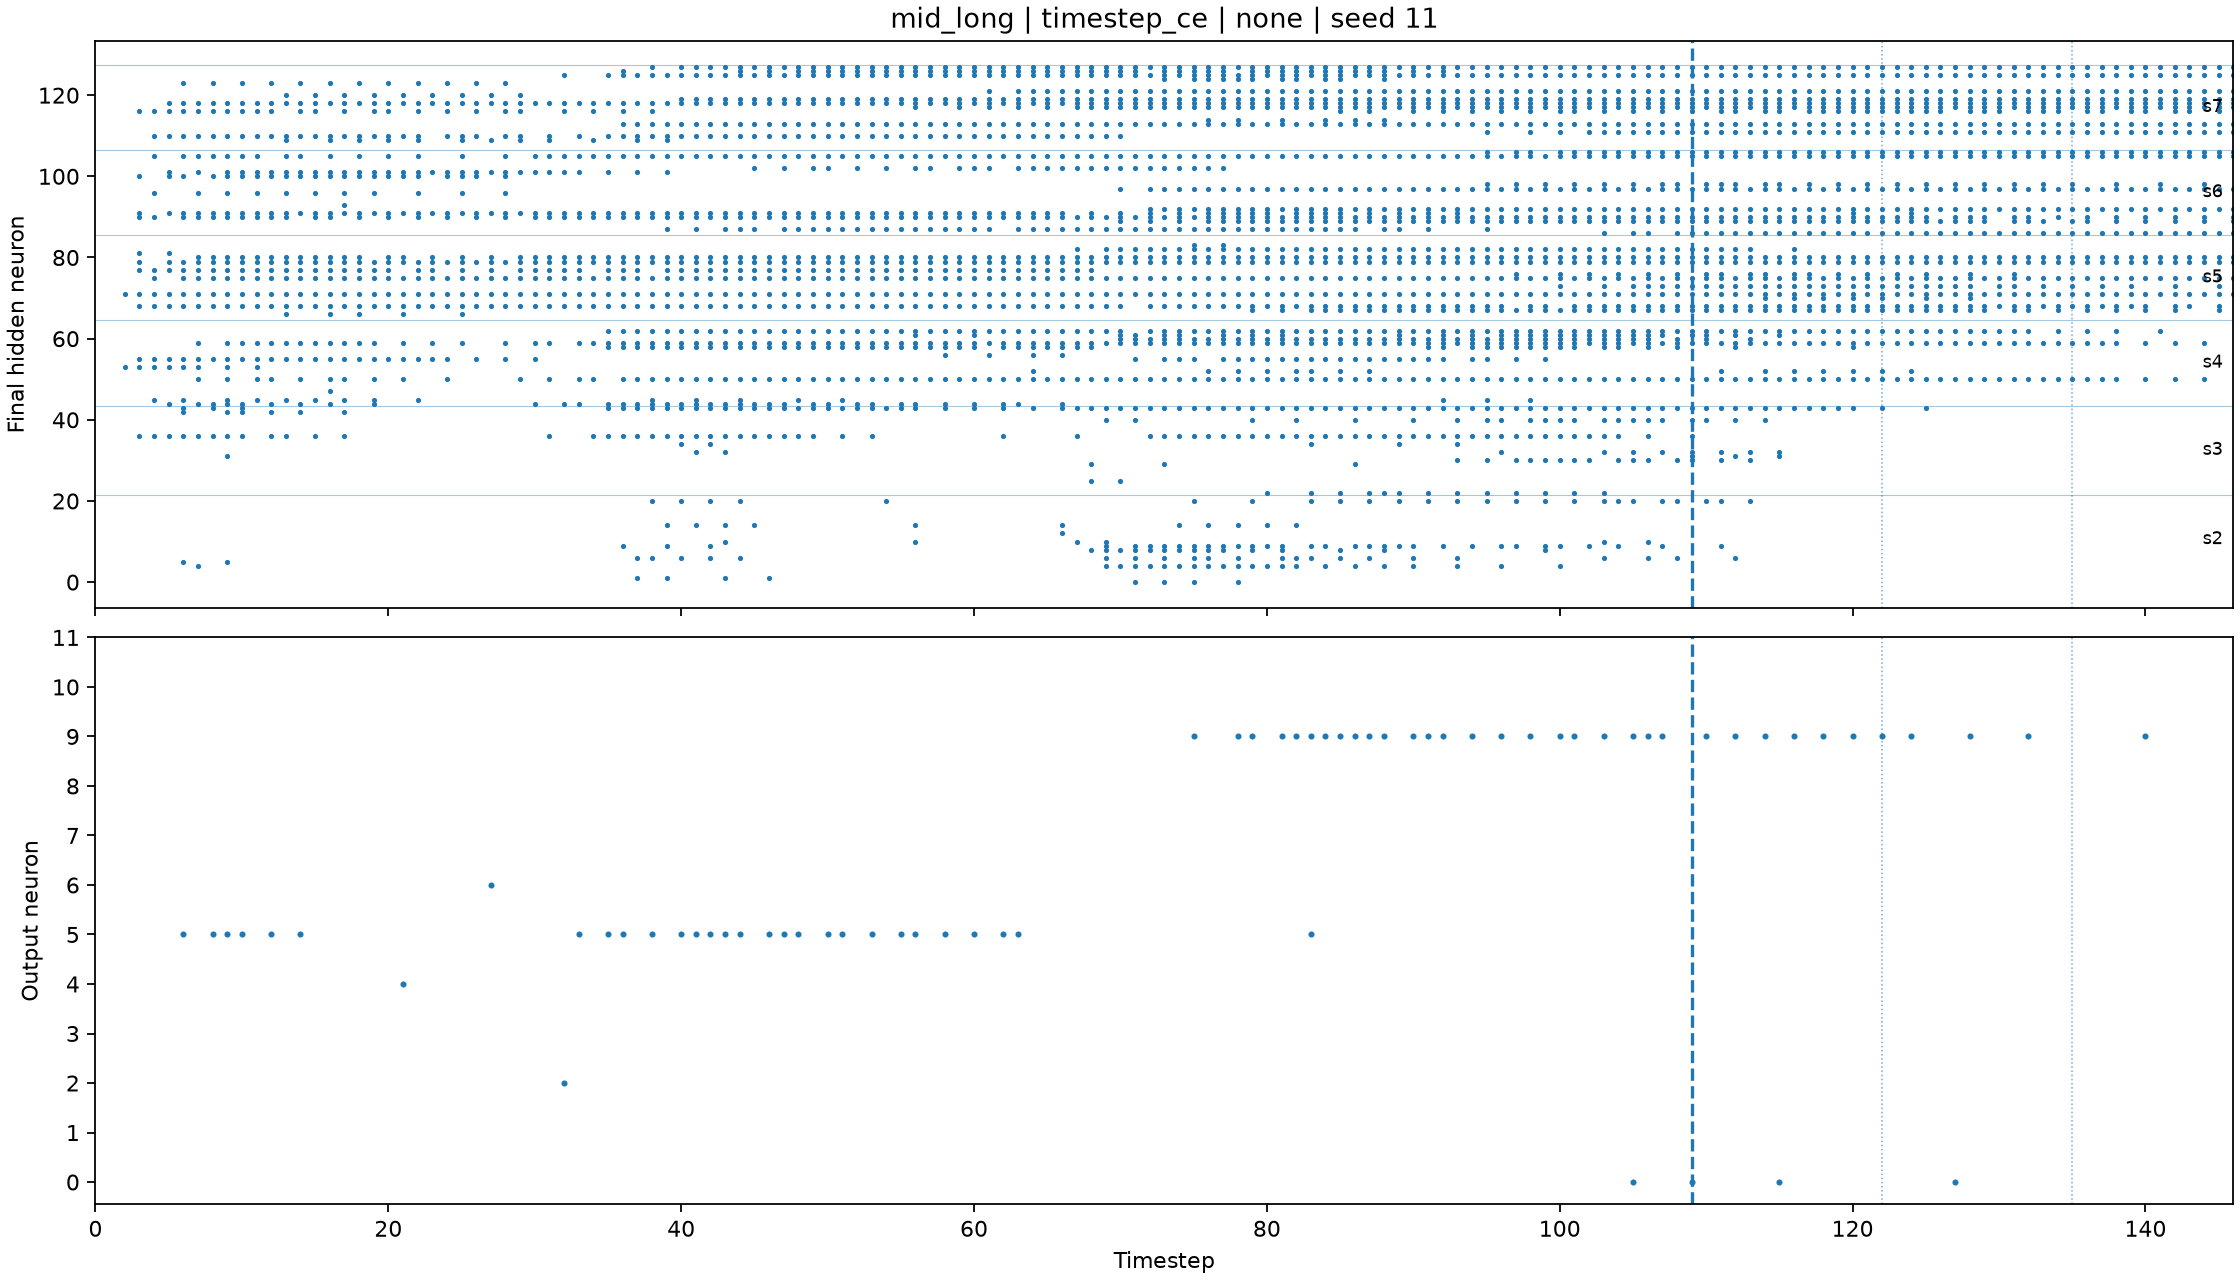

mid_long timestep_ce tail seed 11


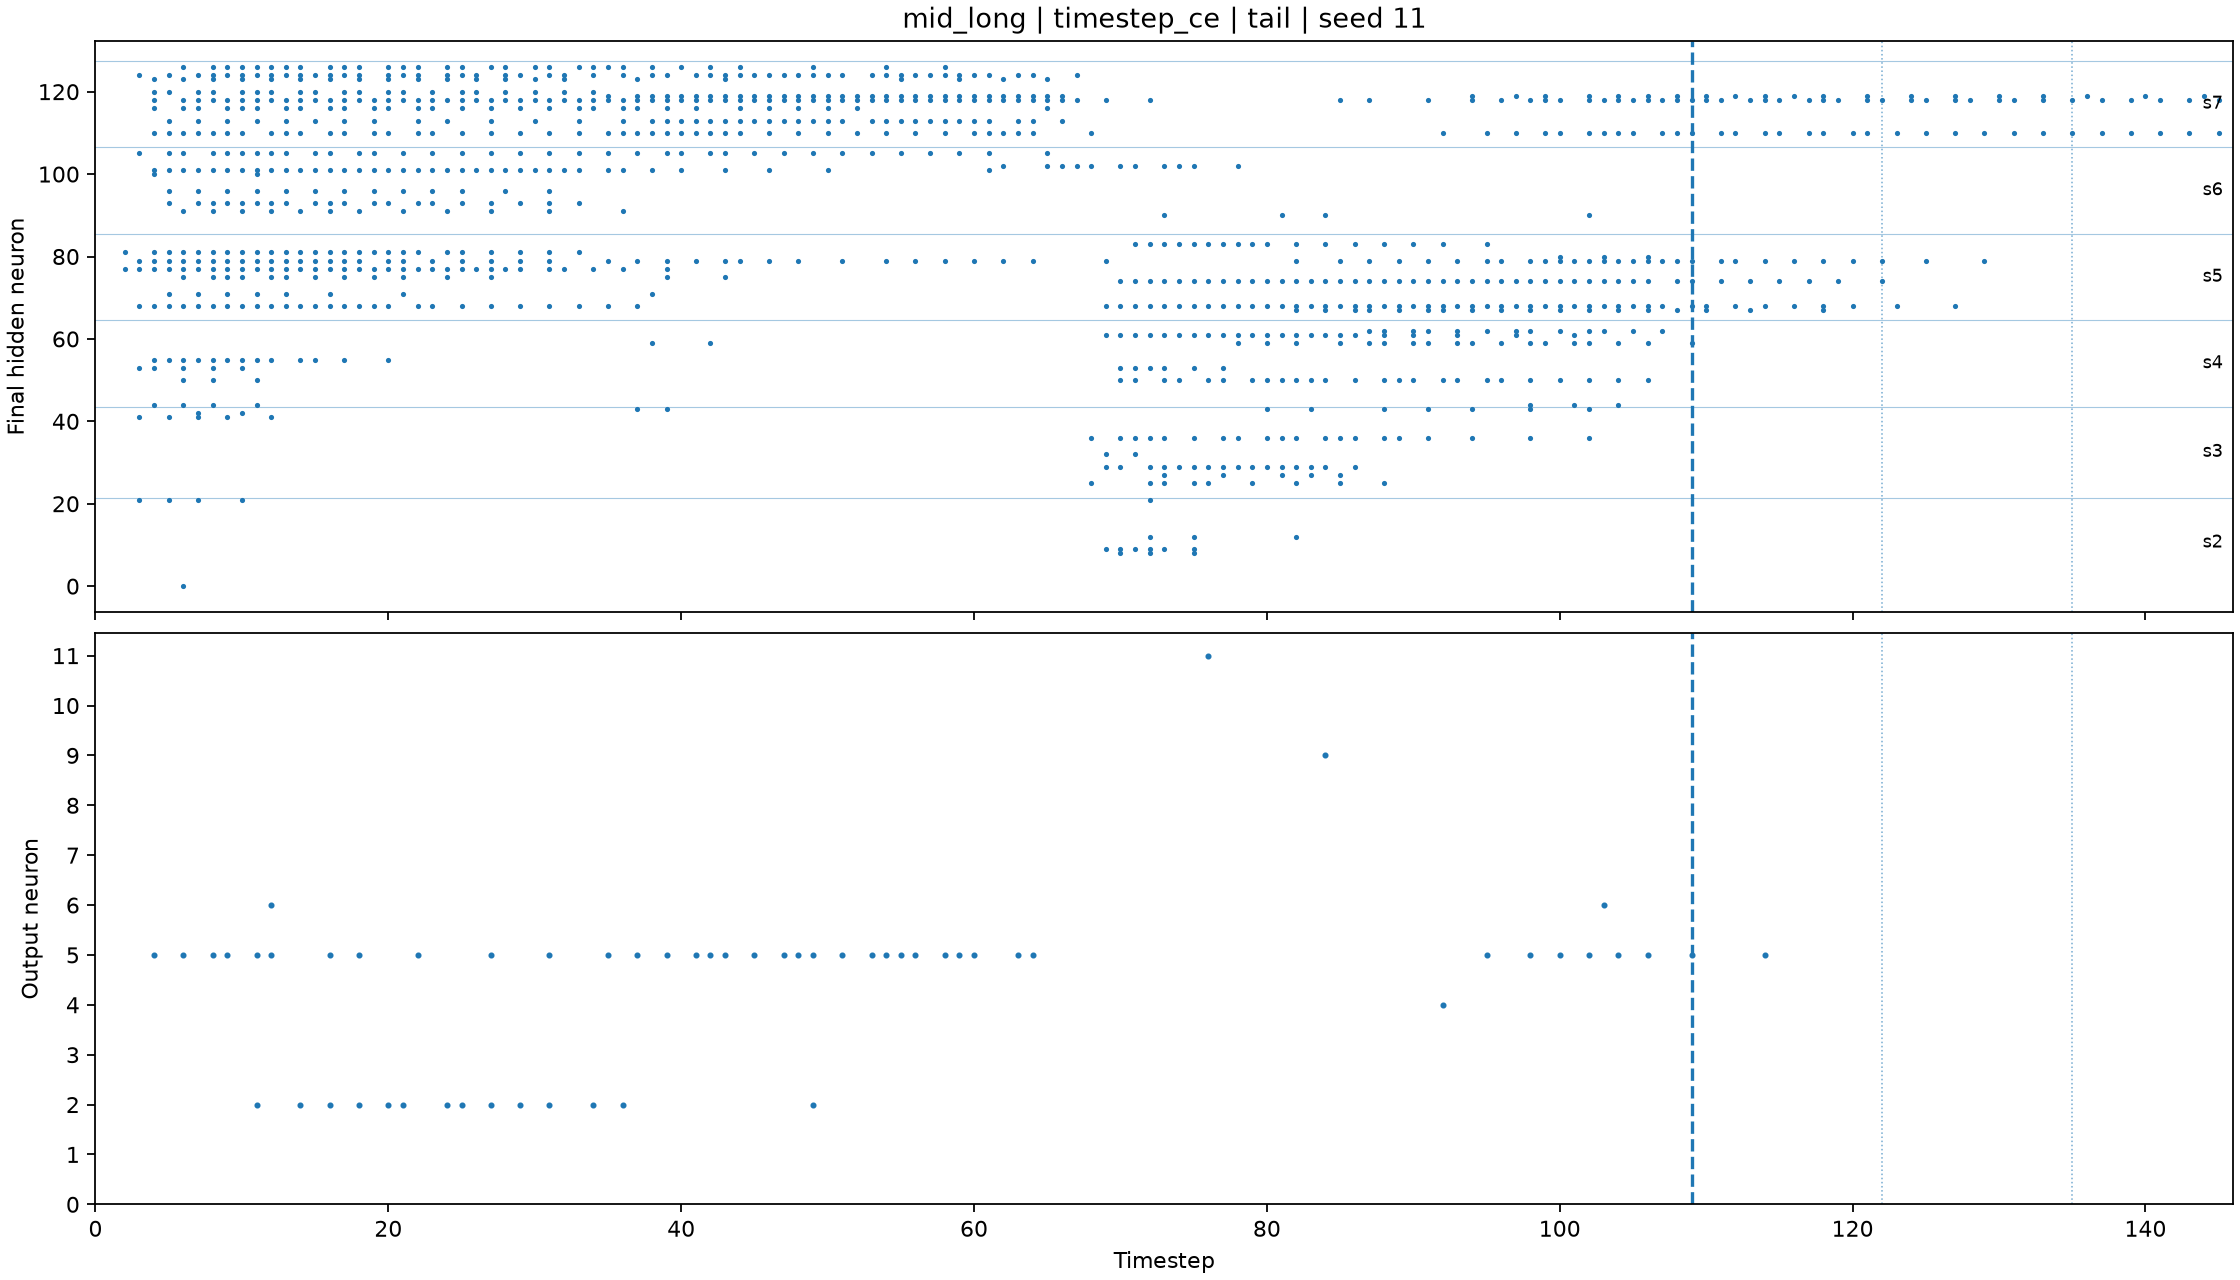

mid_long whole_count_ce a1 seed 11


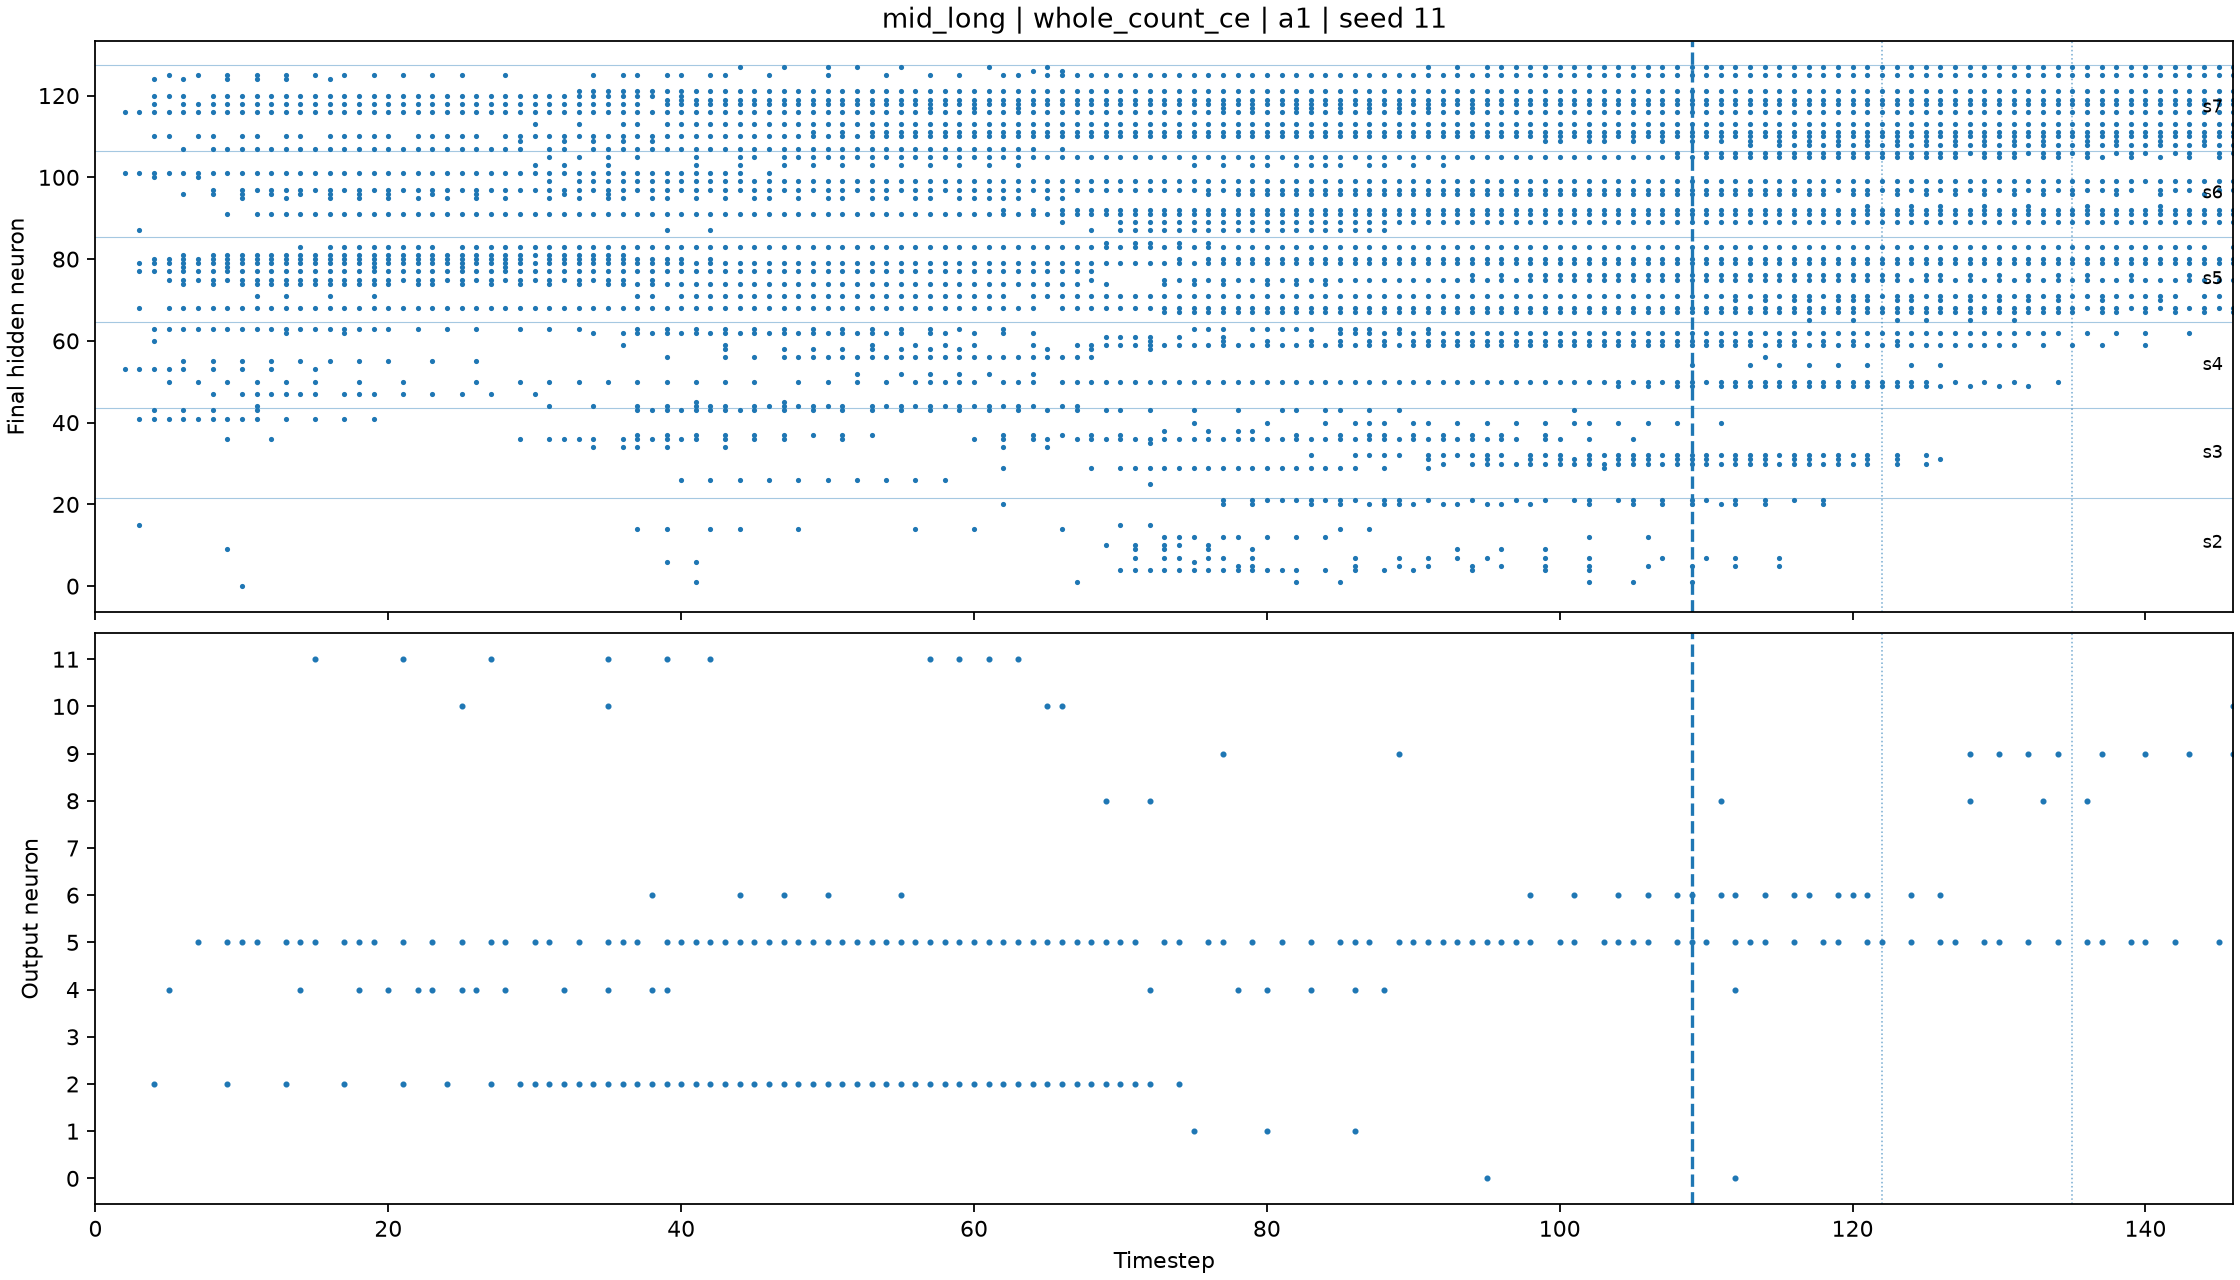

mid_long whole_count_ce a1_p2 seed 11


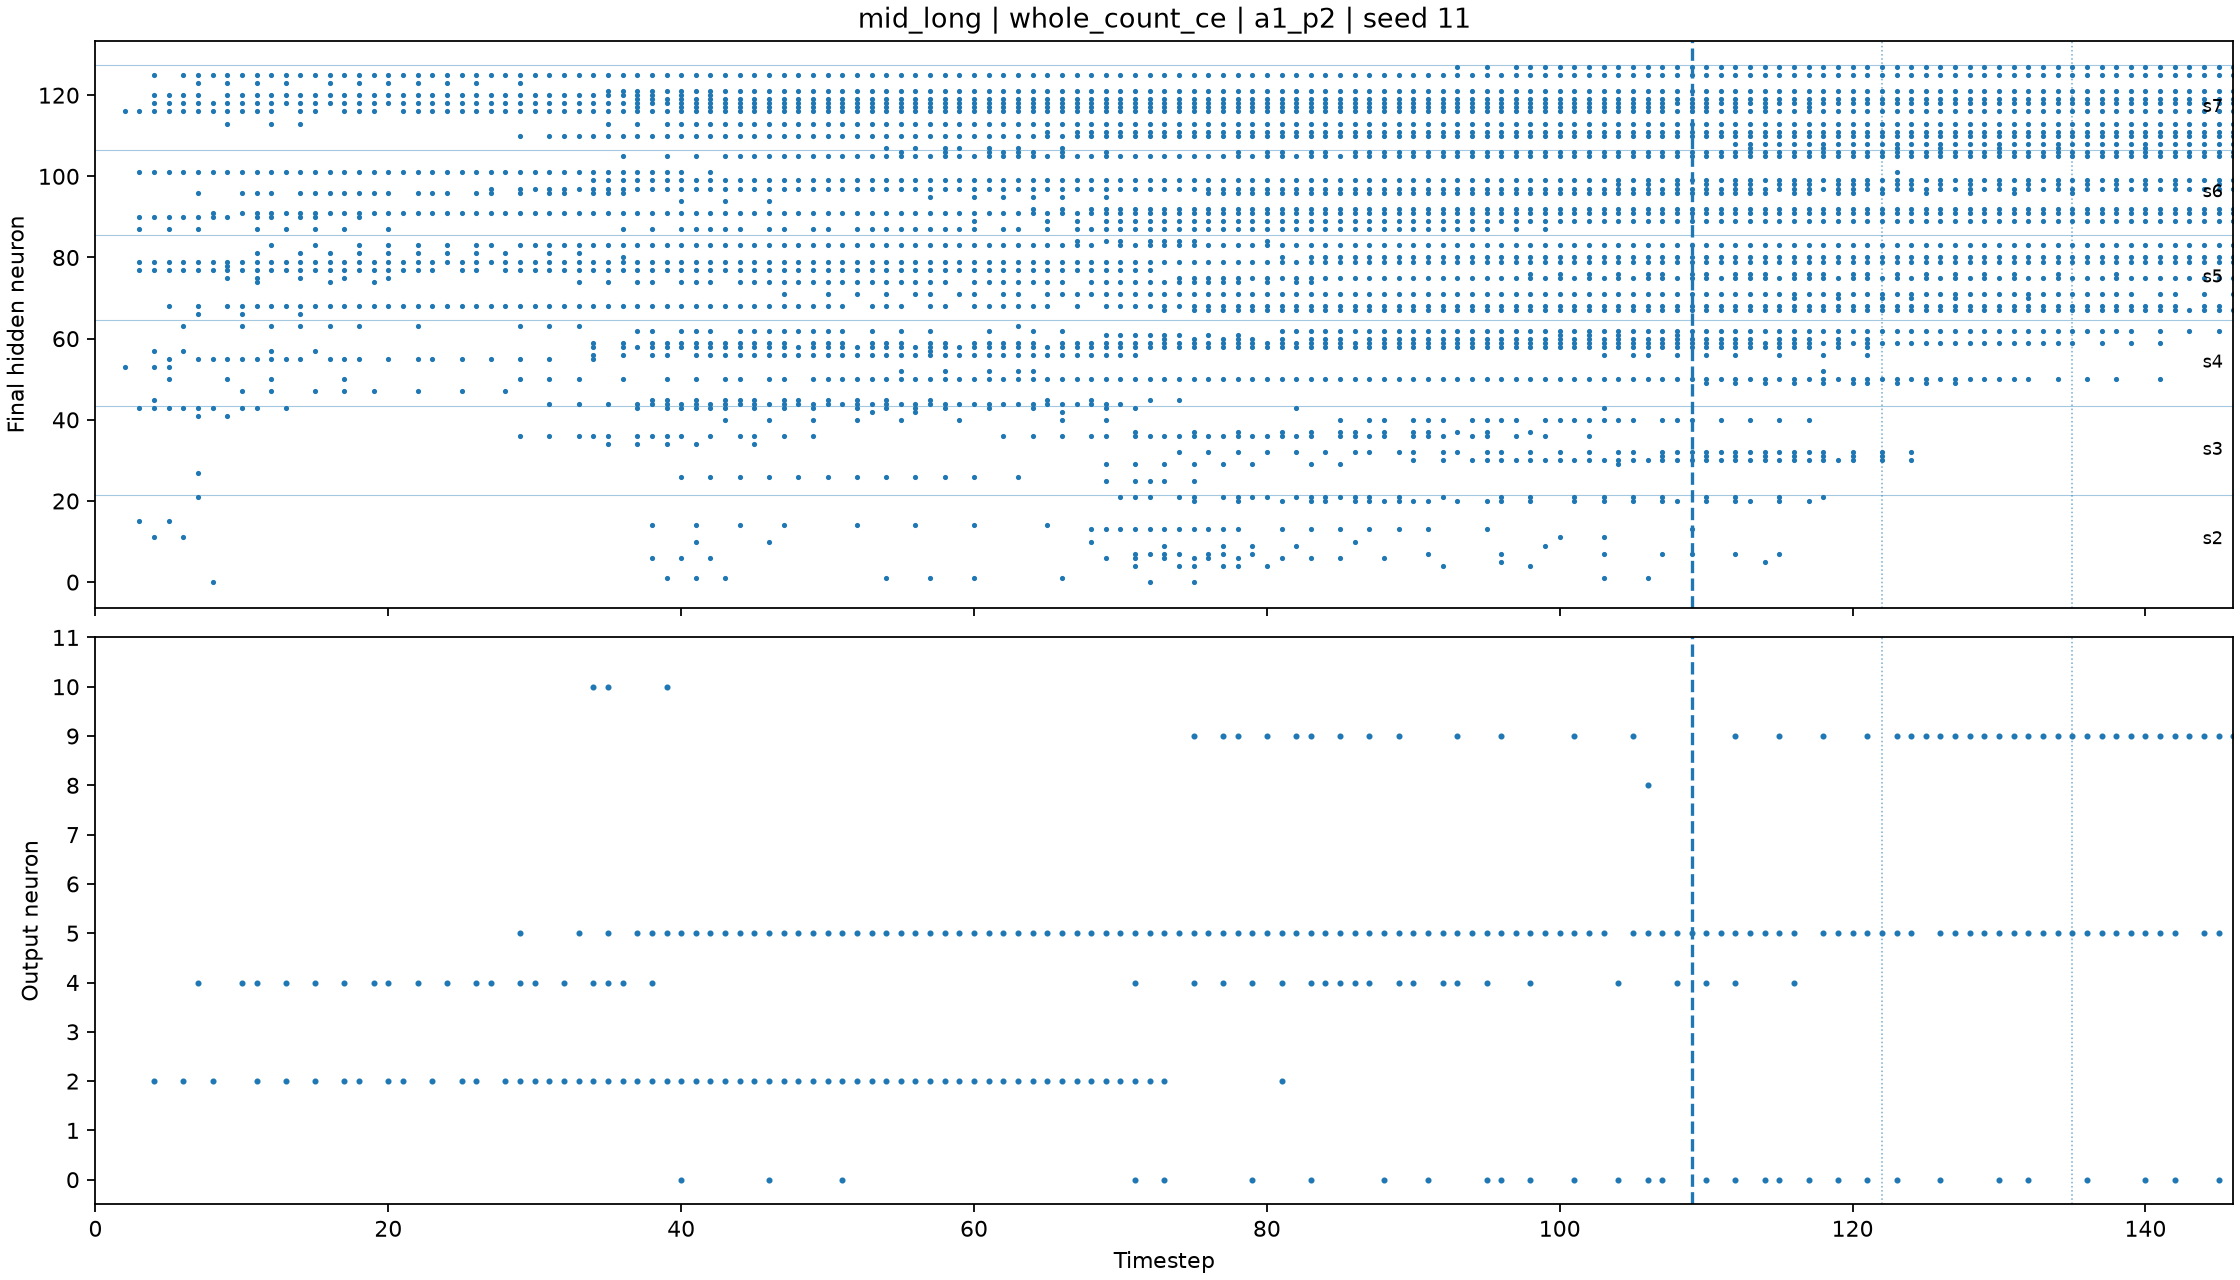

mid_long whole_count_ce a1_tail seed 11


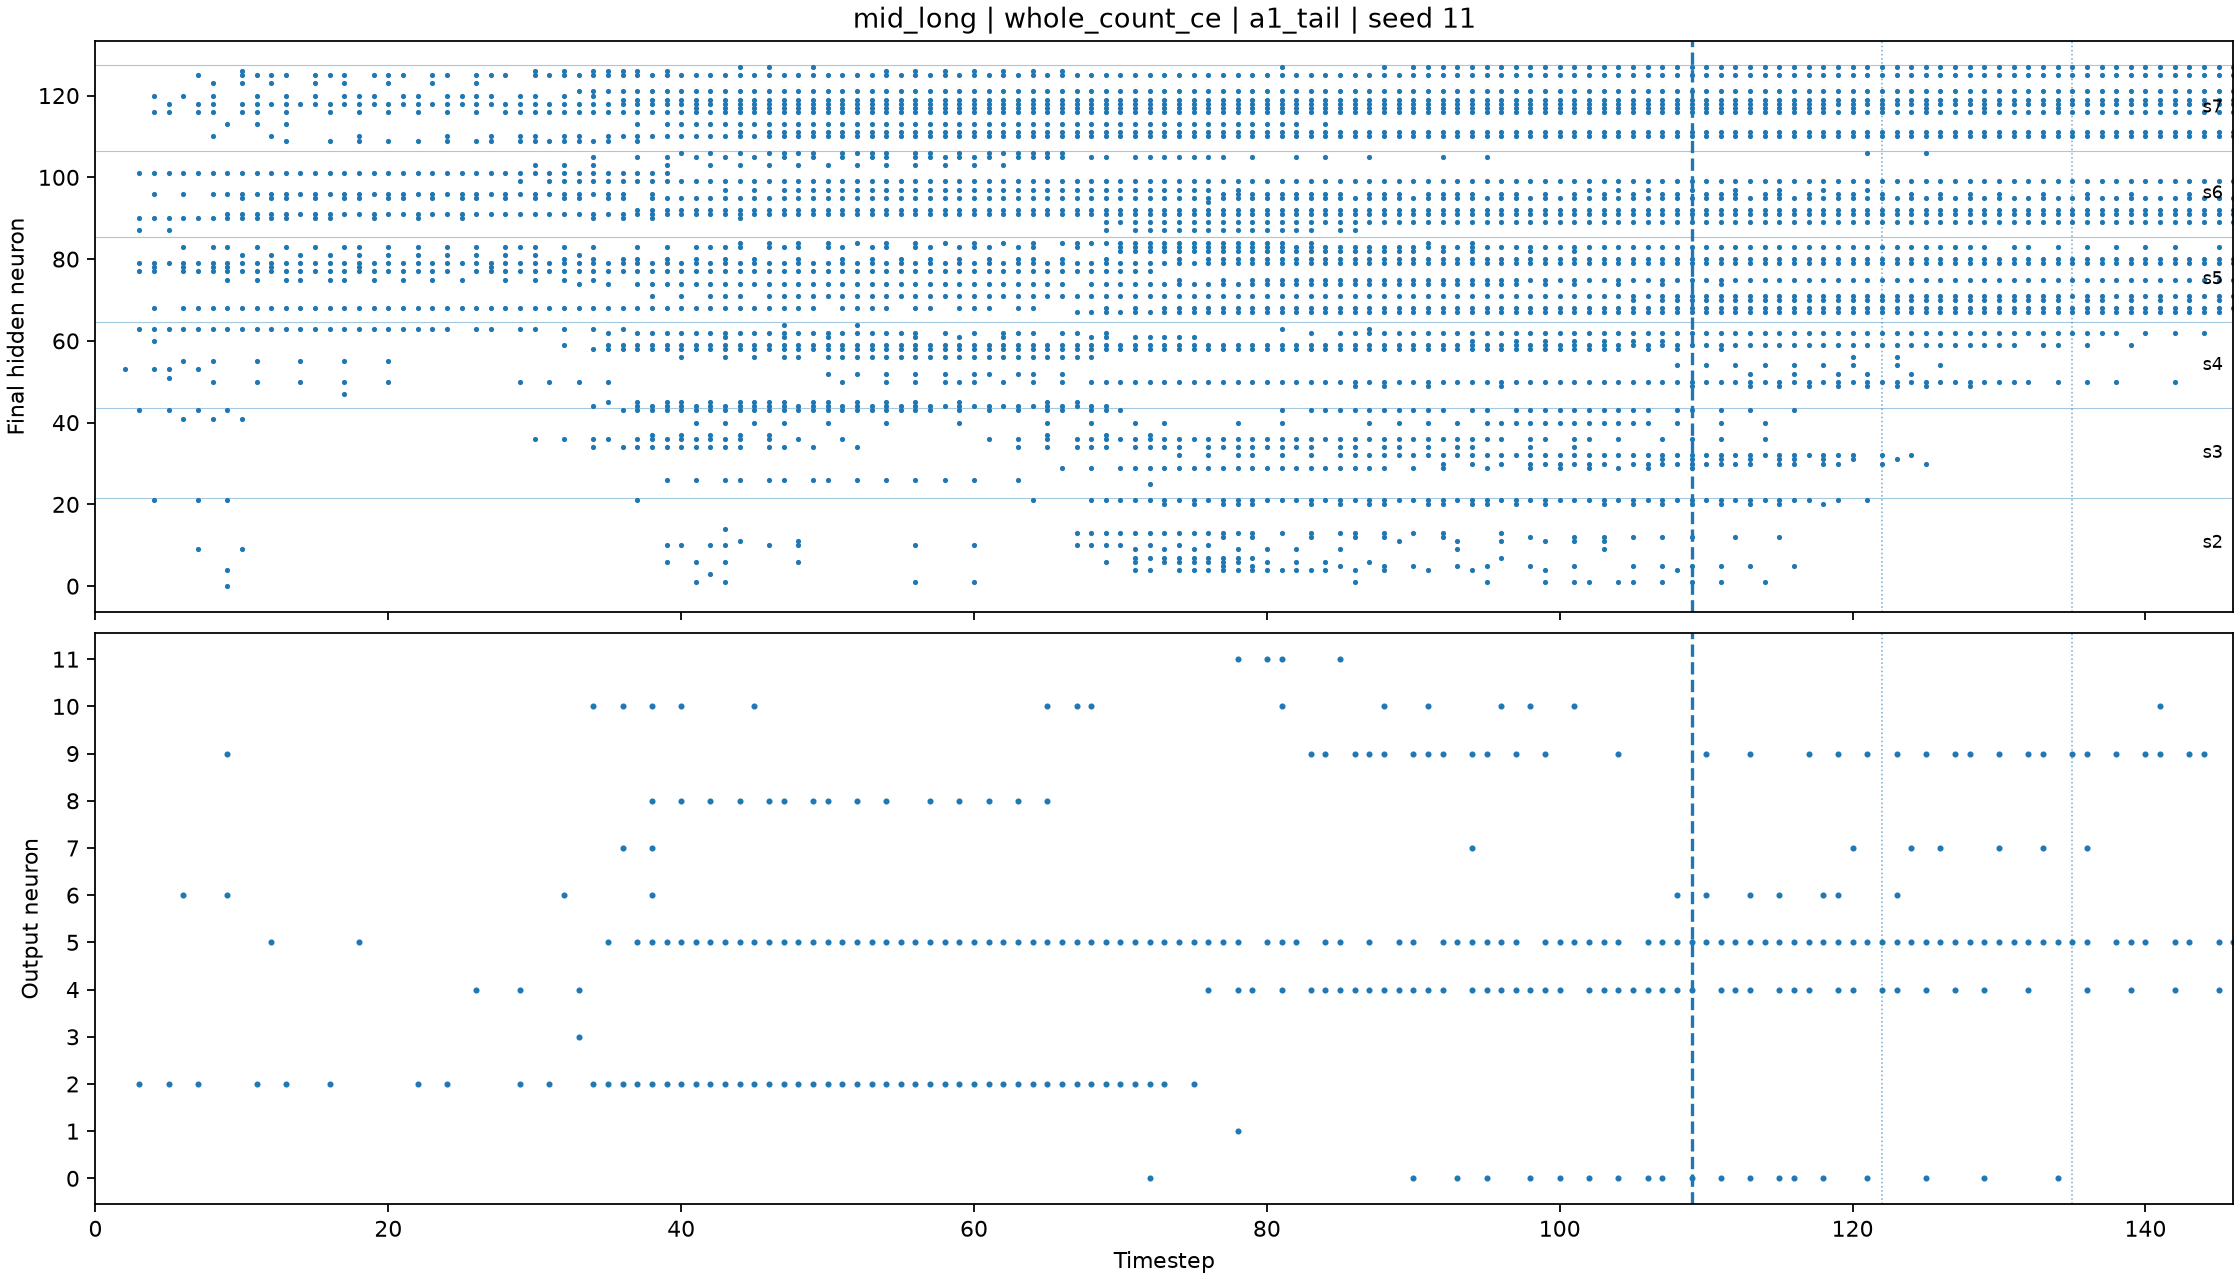

mid_long whole_count_ce none seed 11


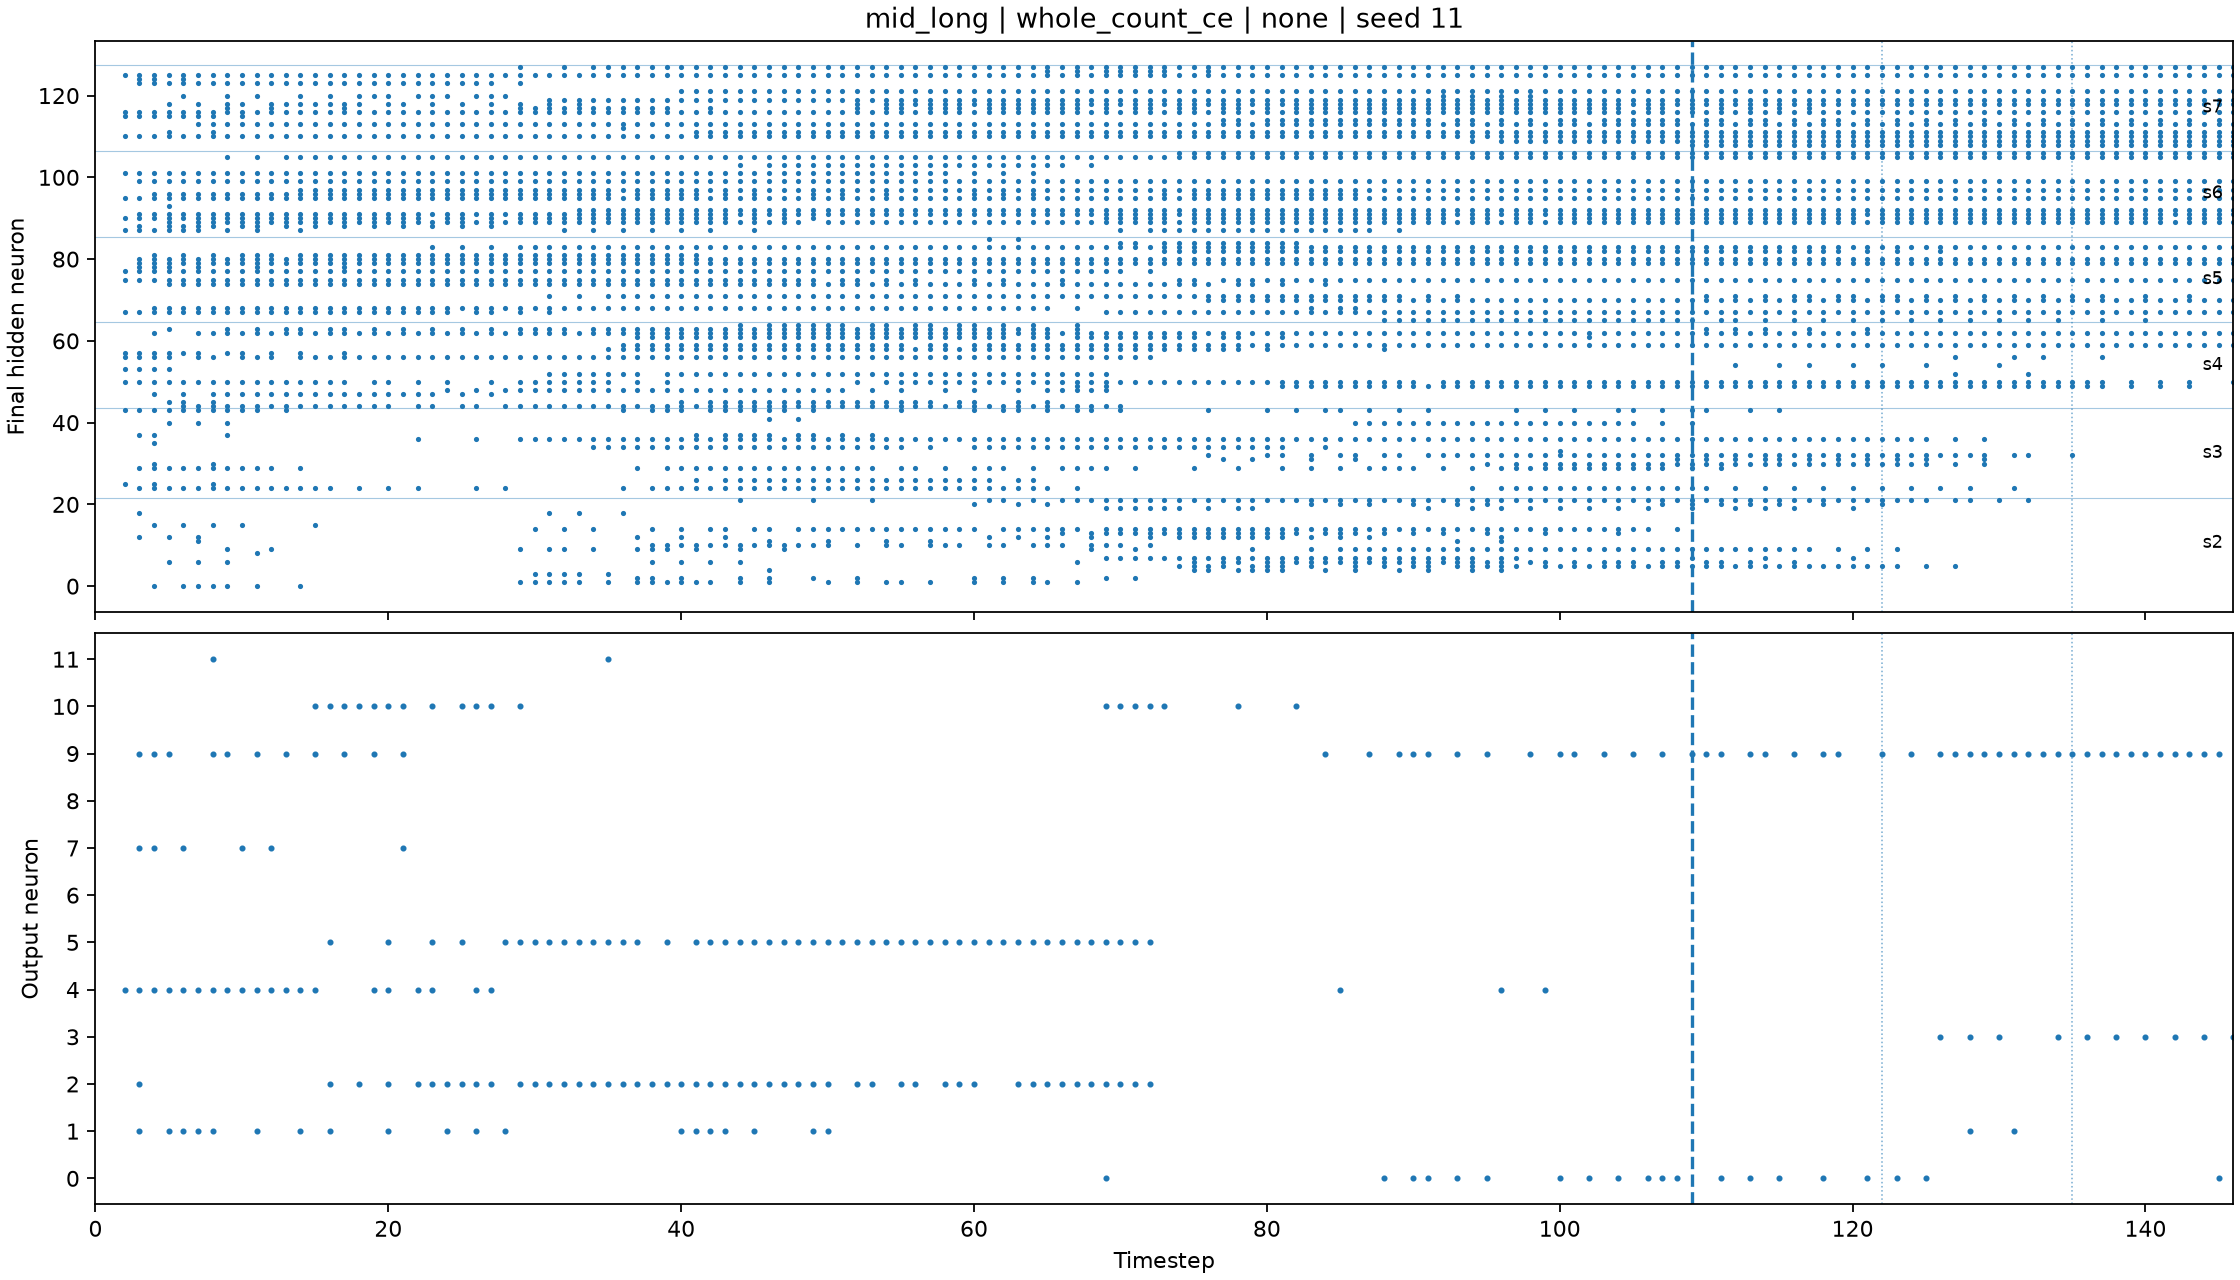

mid_long whole_count_ce tail seed 11


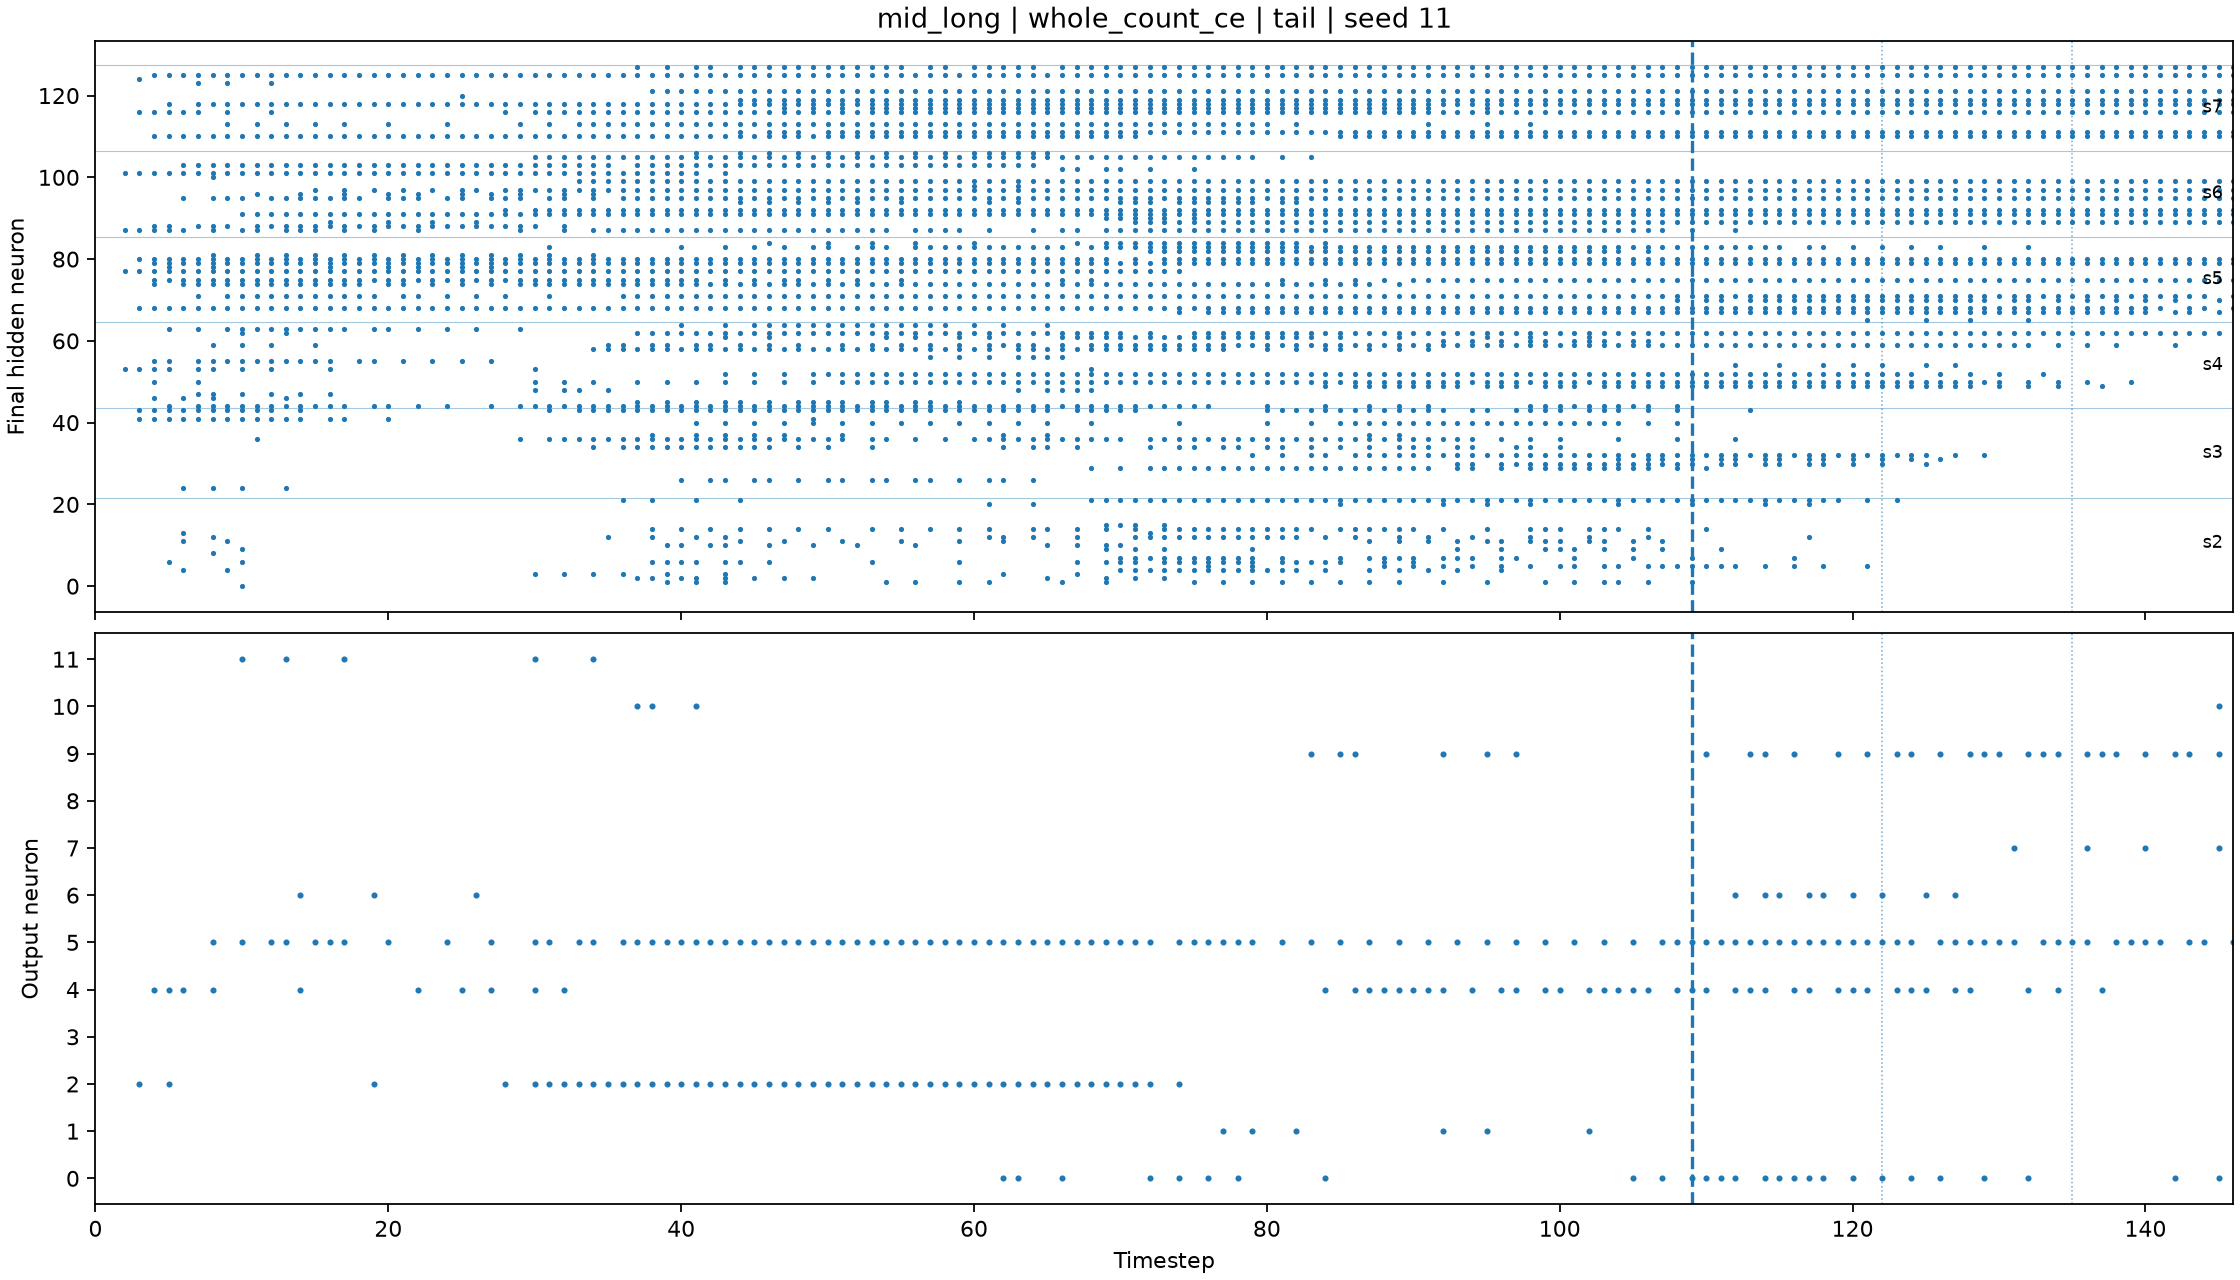

short_mid timestep_ce a1 seed 11


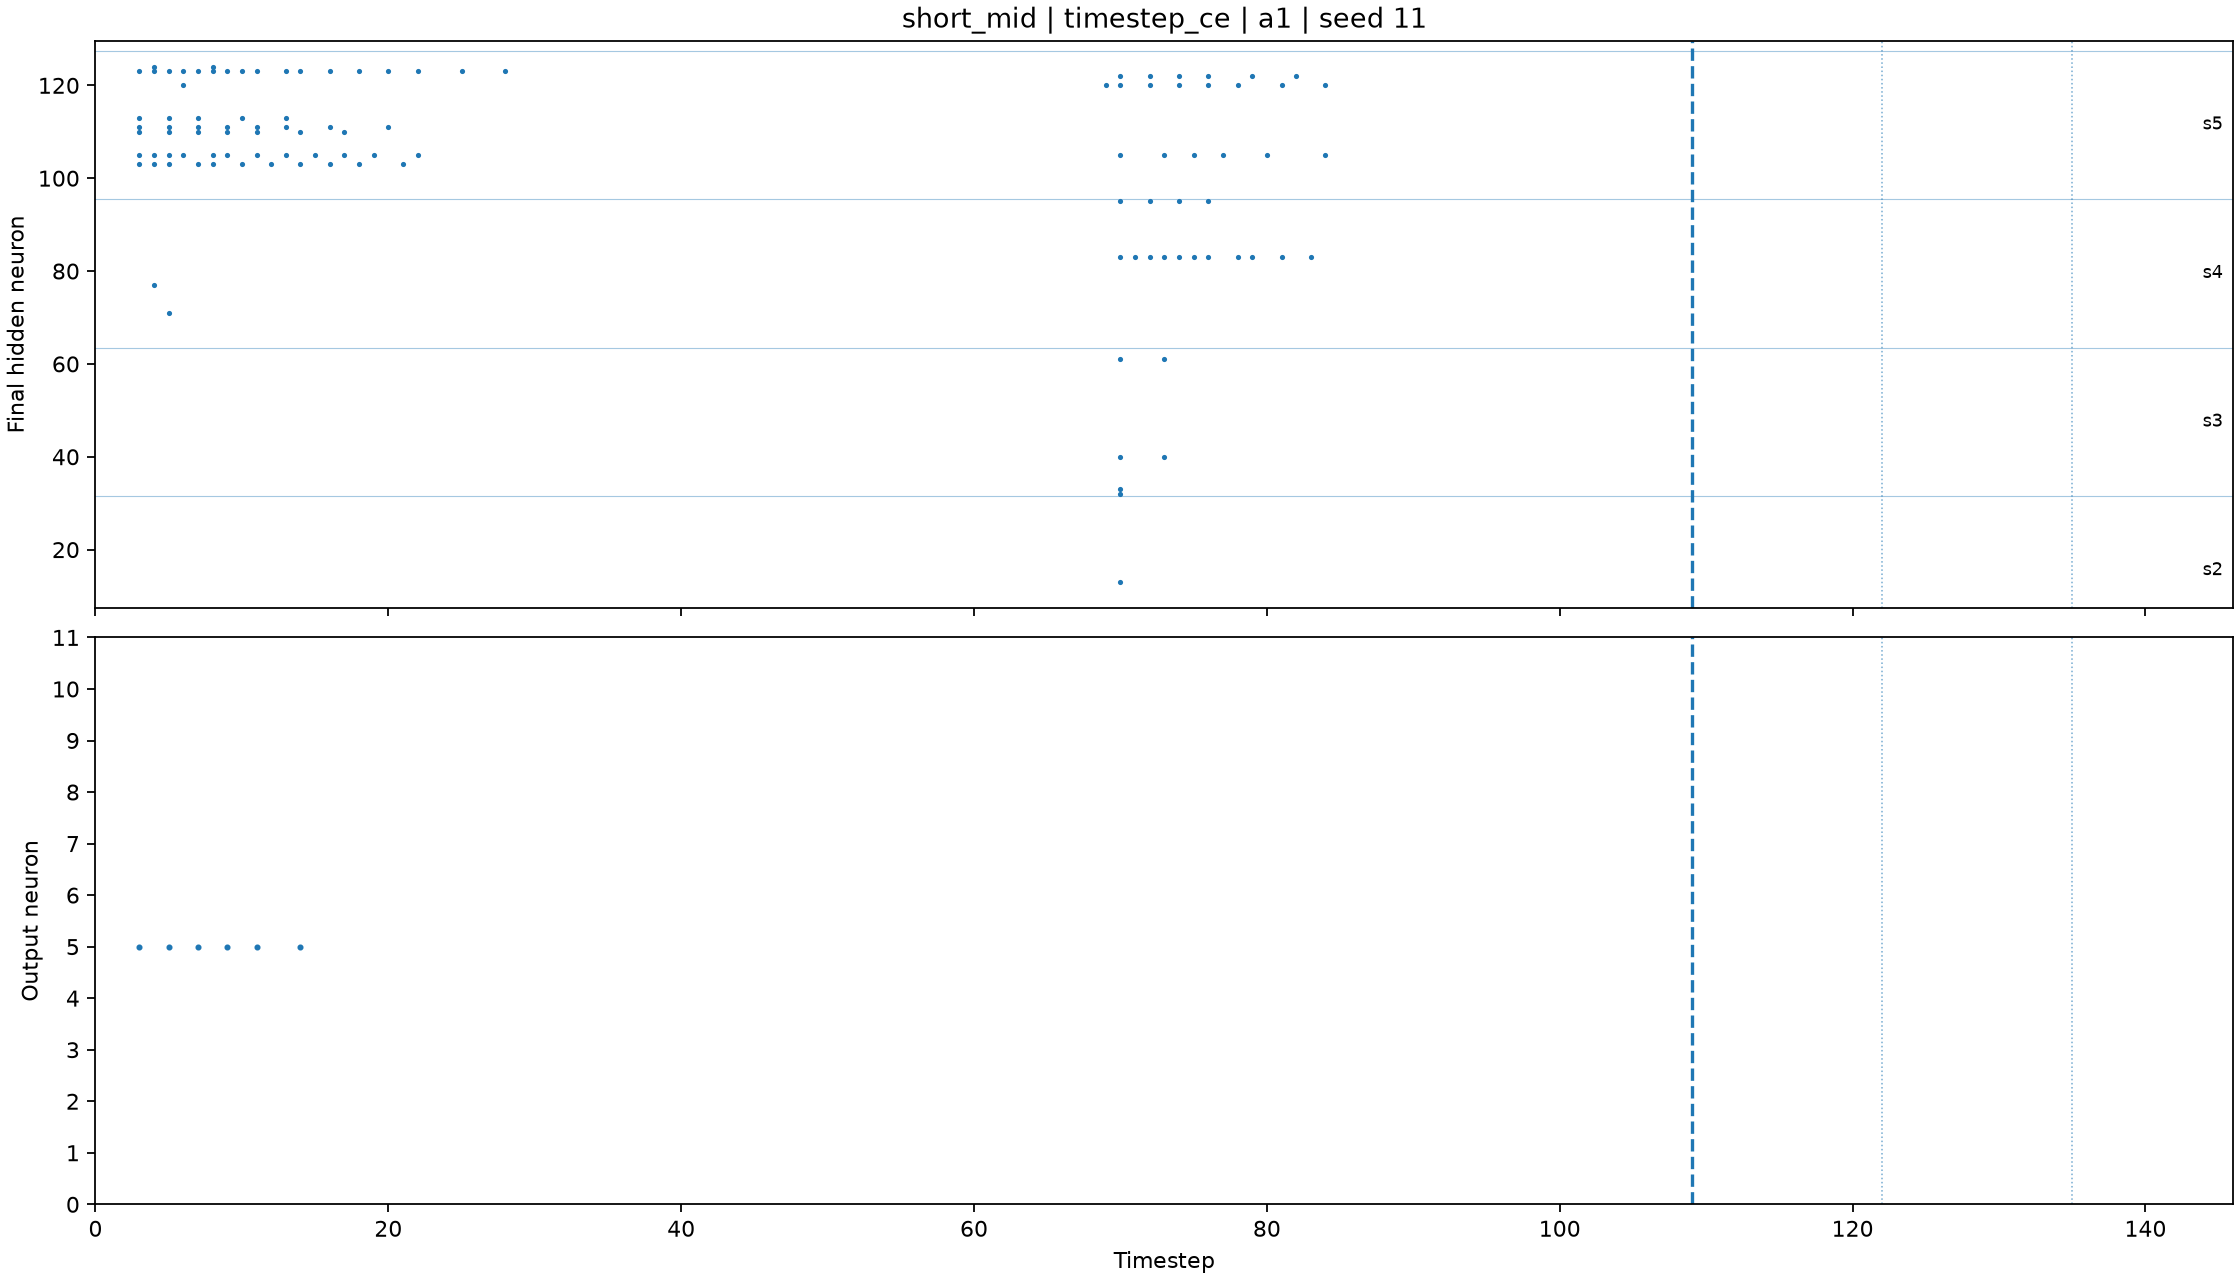

short_mid timestep_ce a1_p2 seed 11


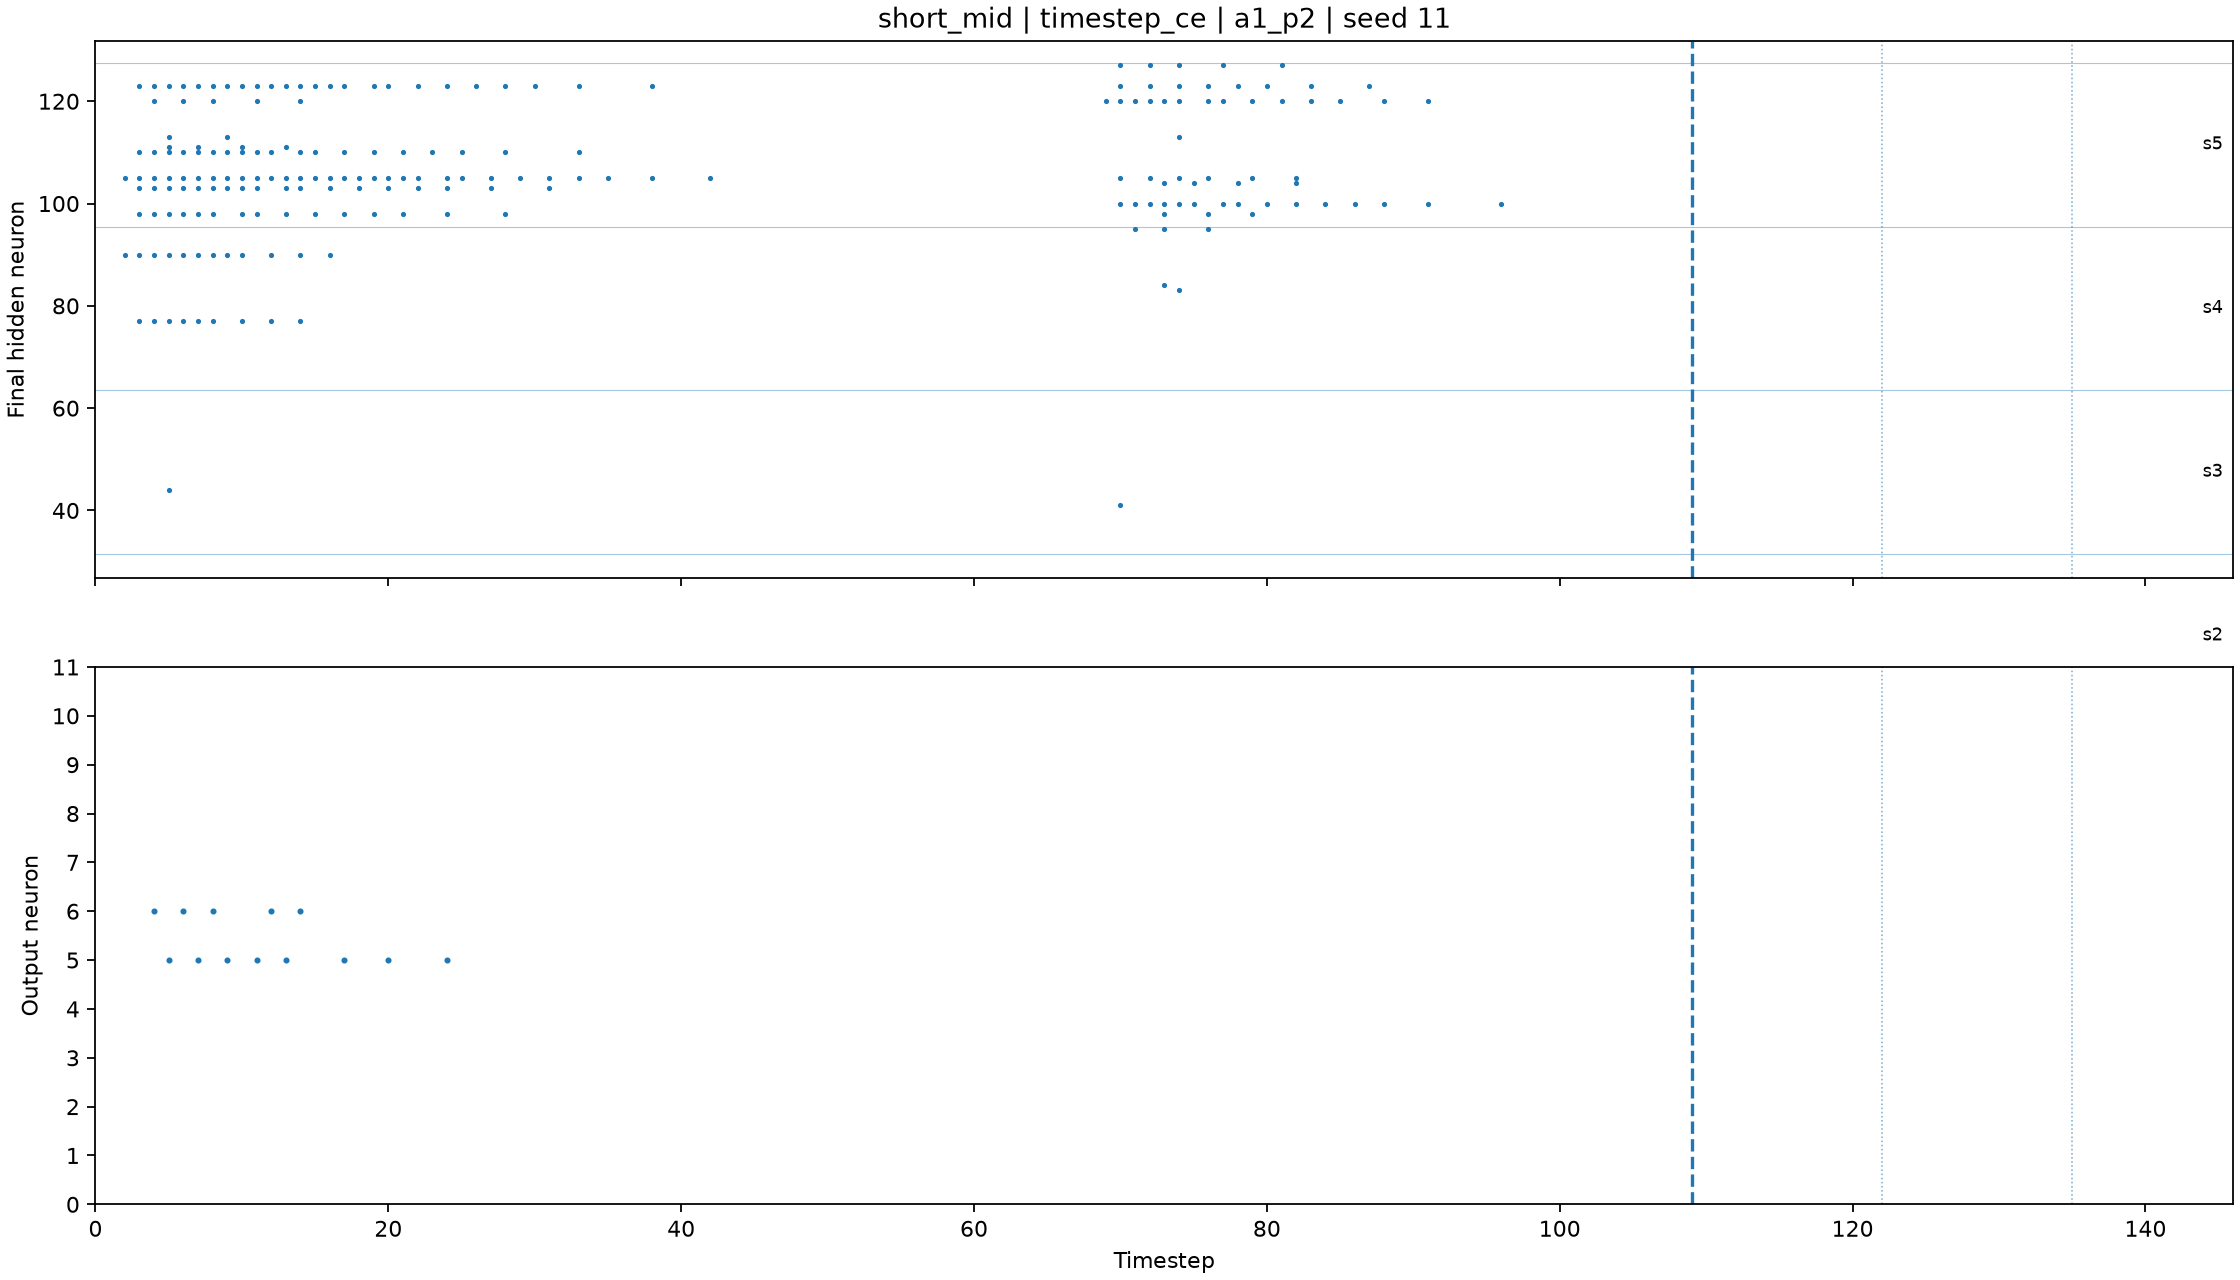

short_mid timestep_ce a1_tail seed 11


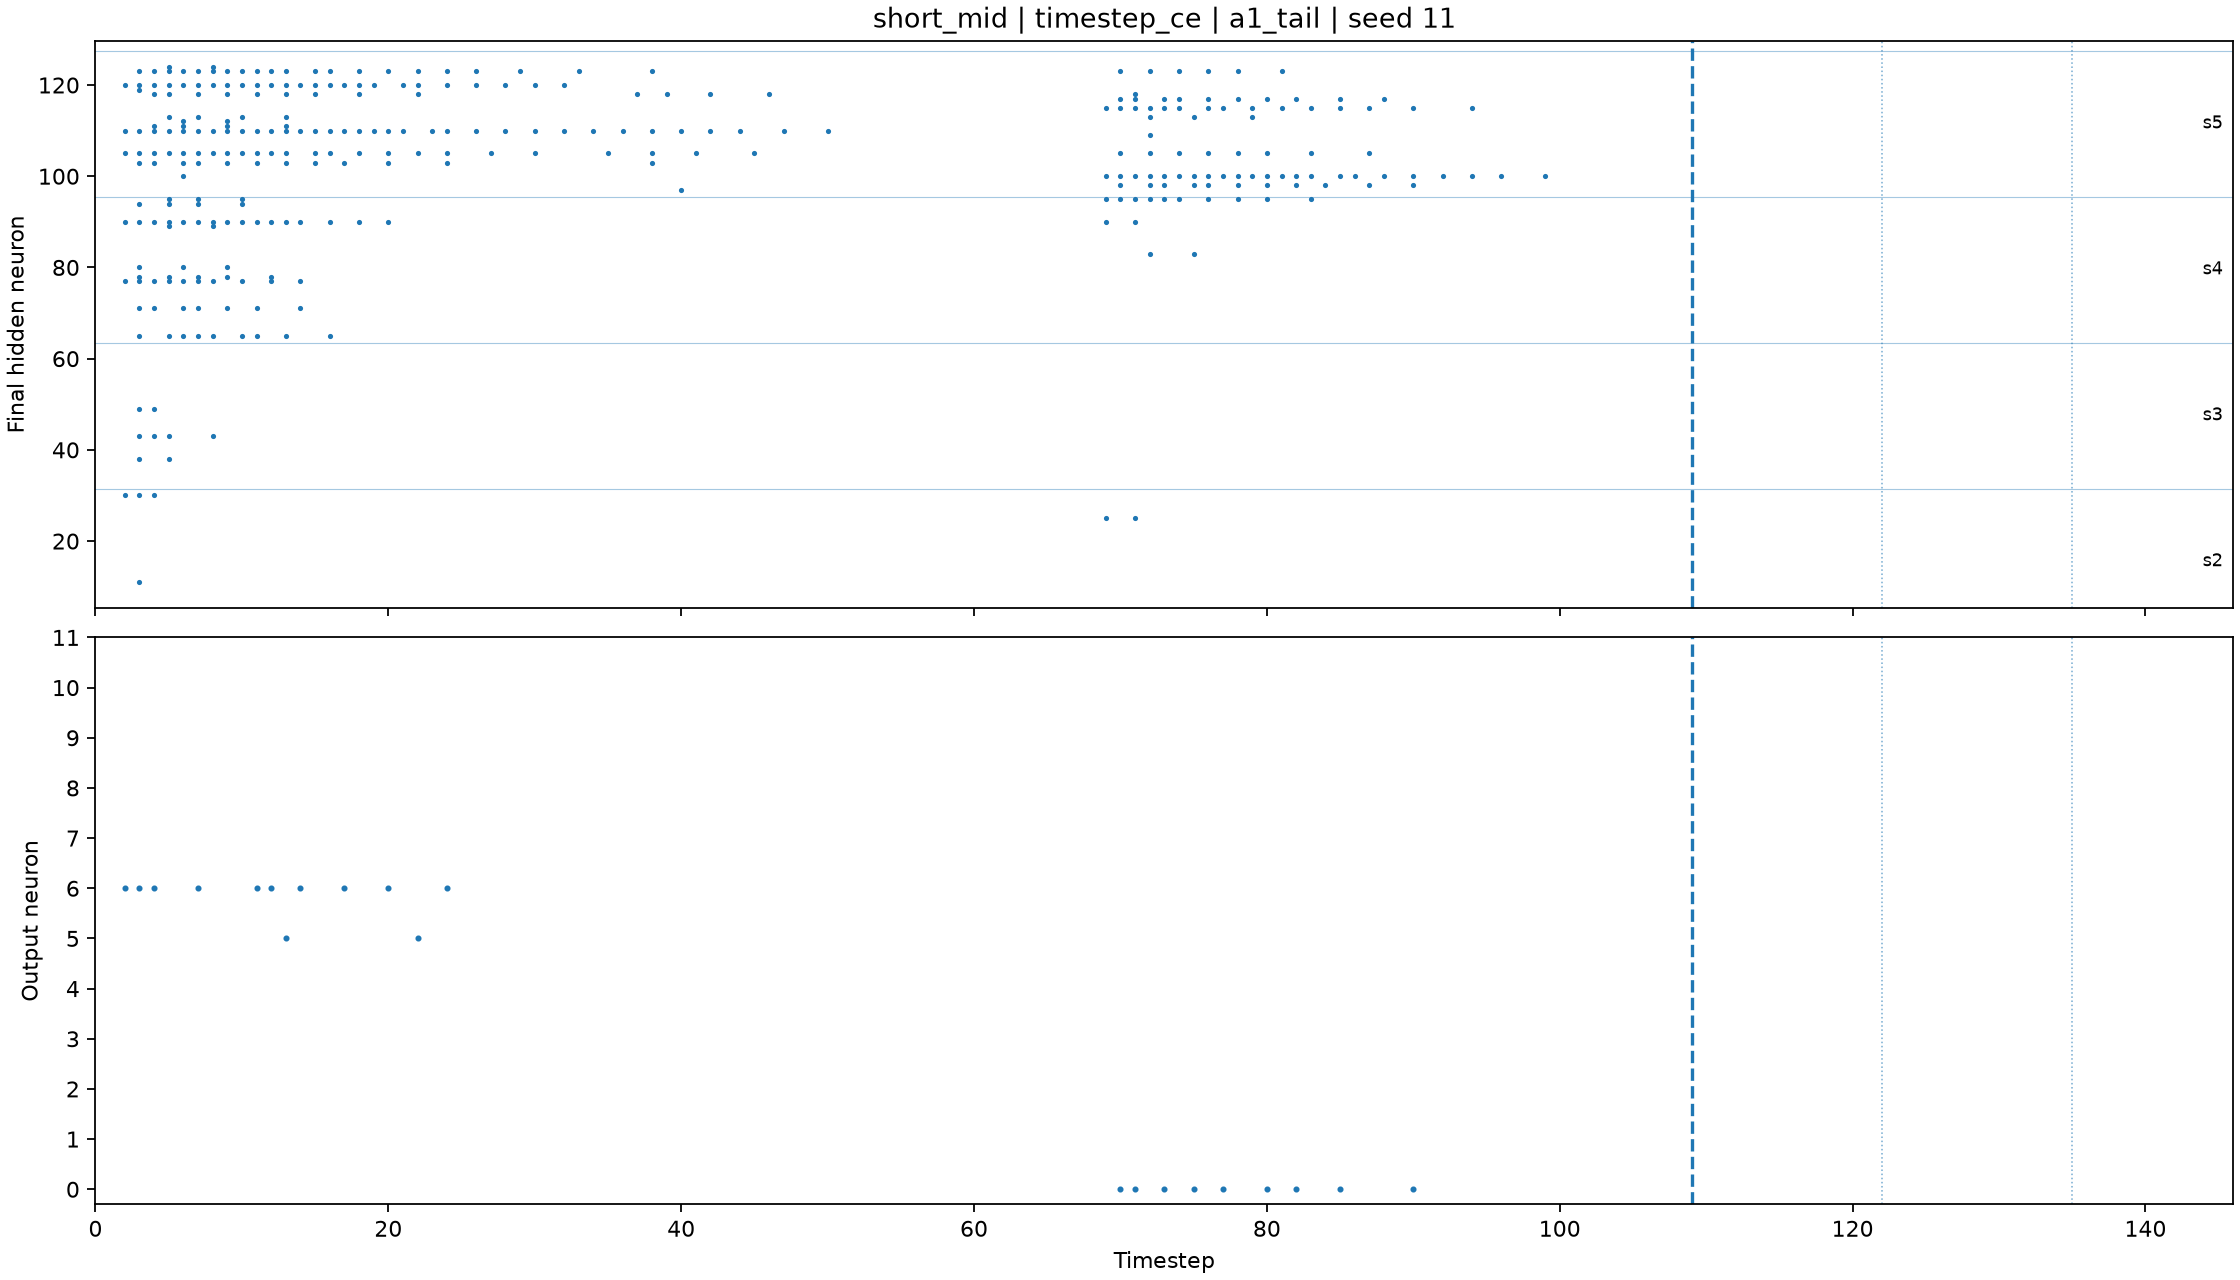

short_mid timestep_ce none seed 11


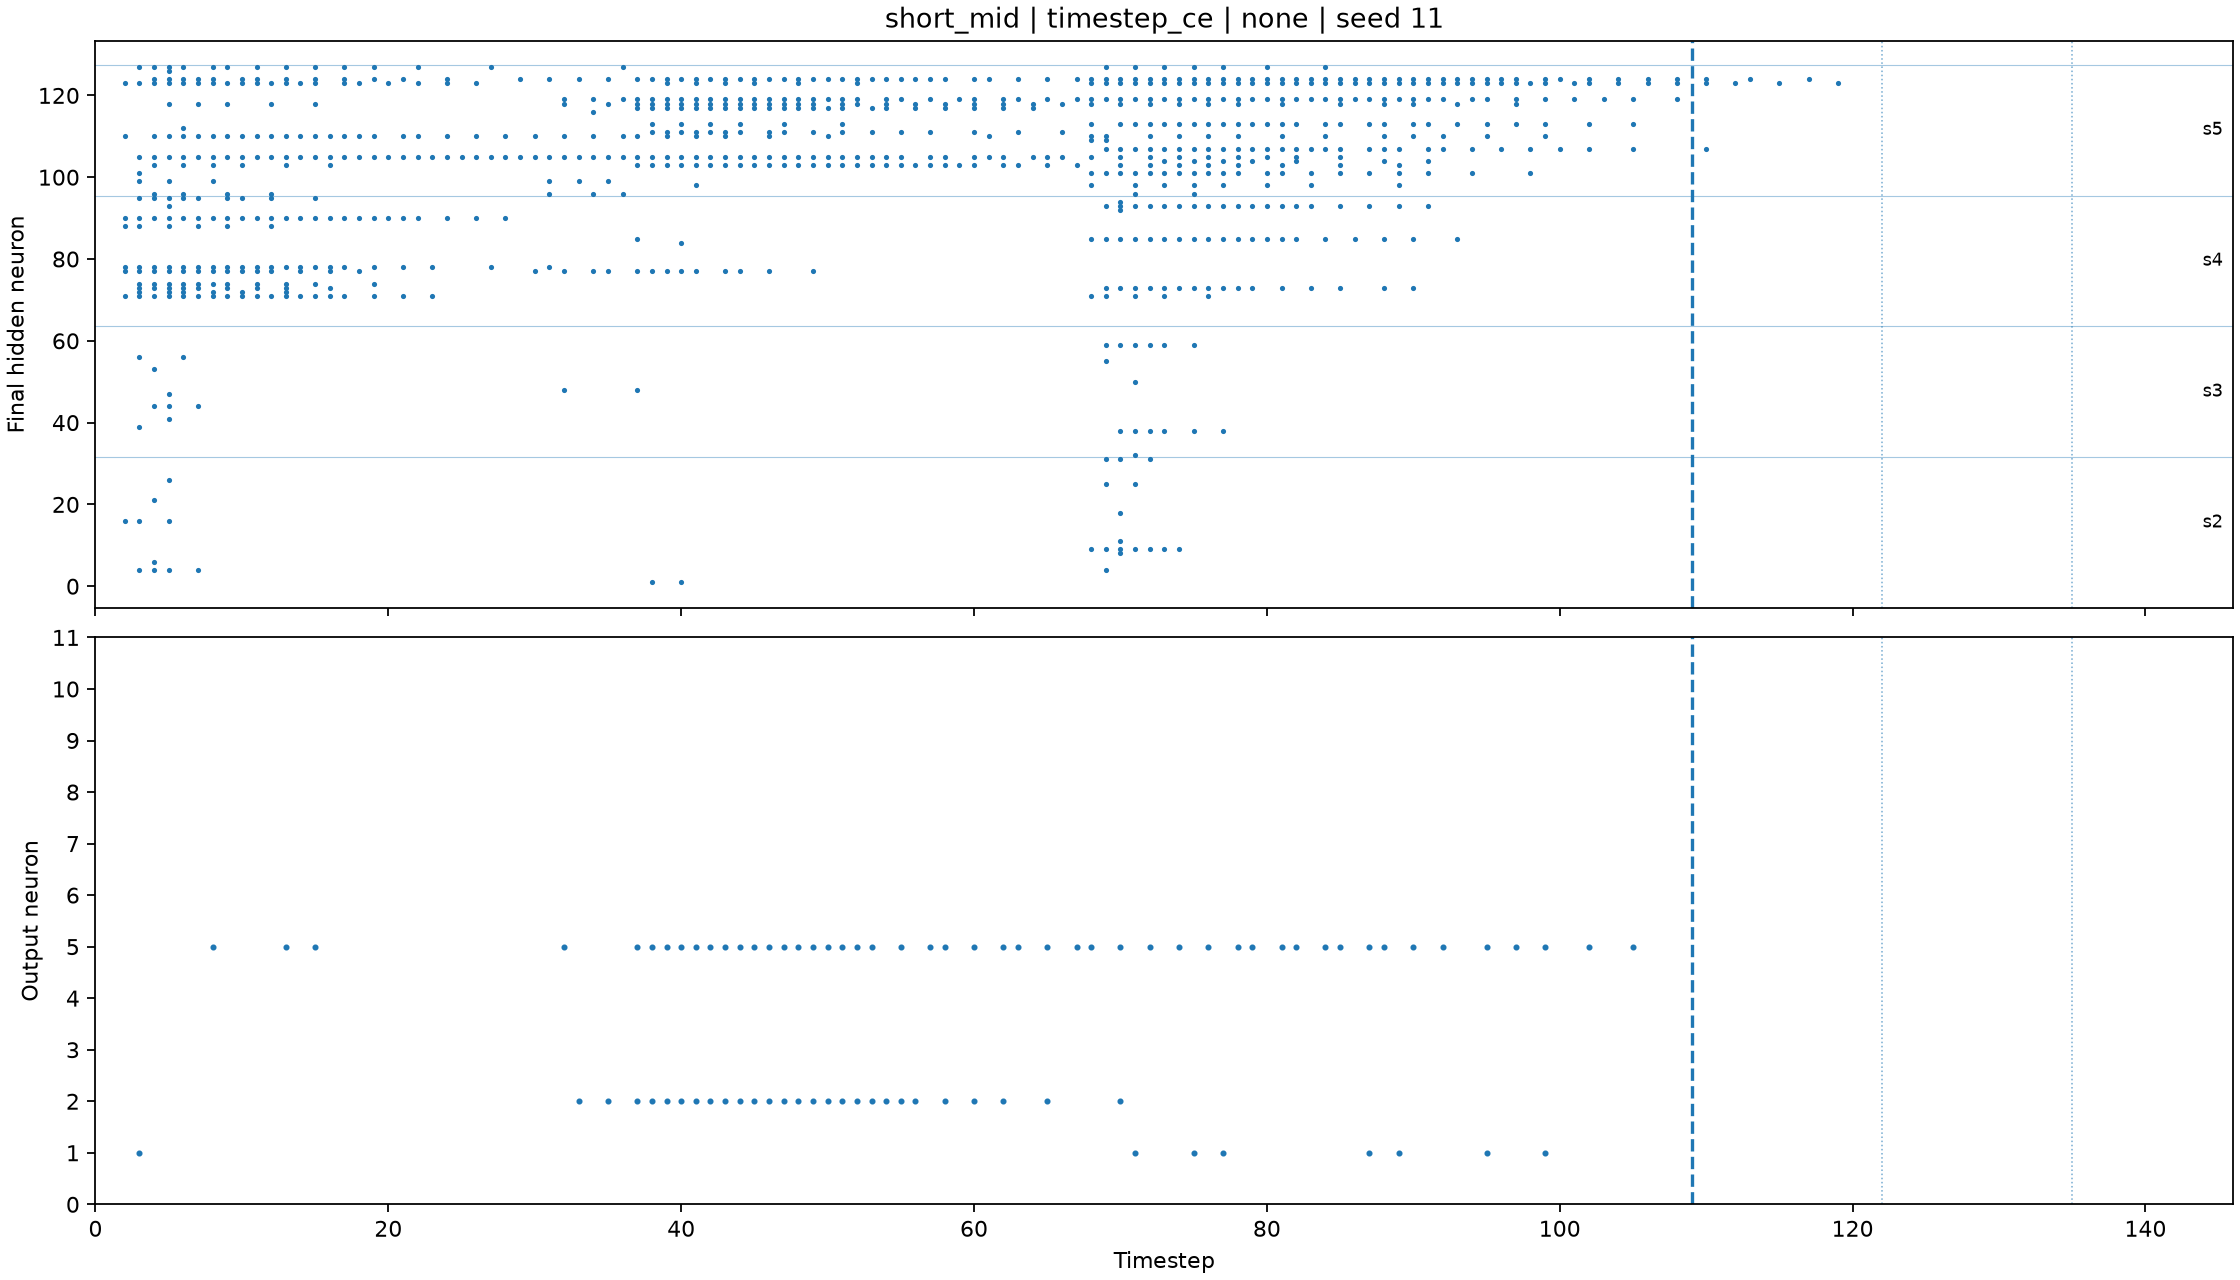

short_mid timestep_ce tail seed 11


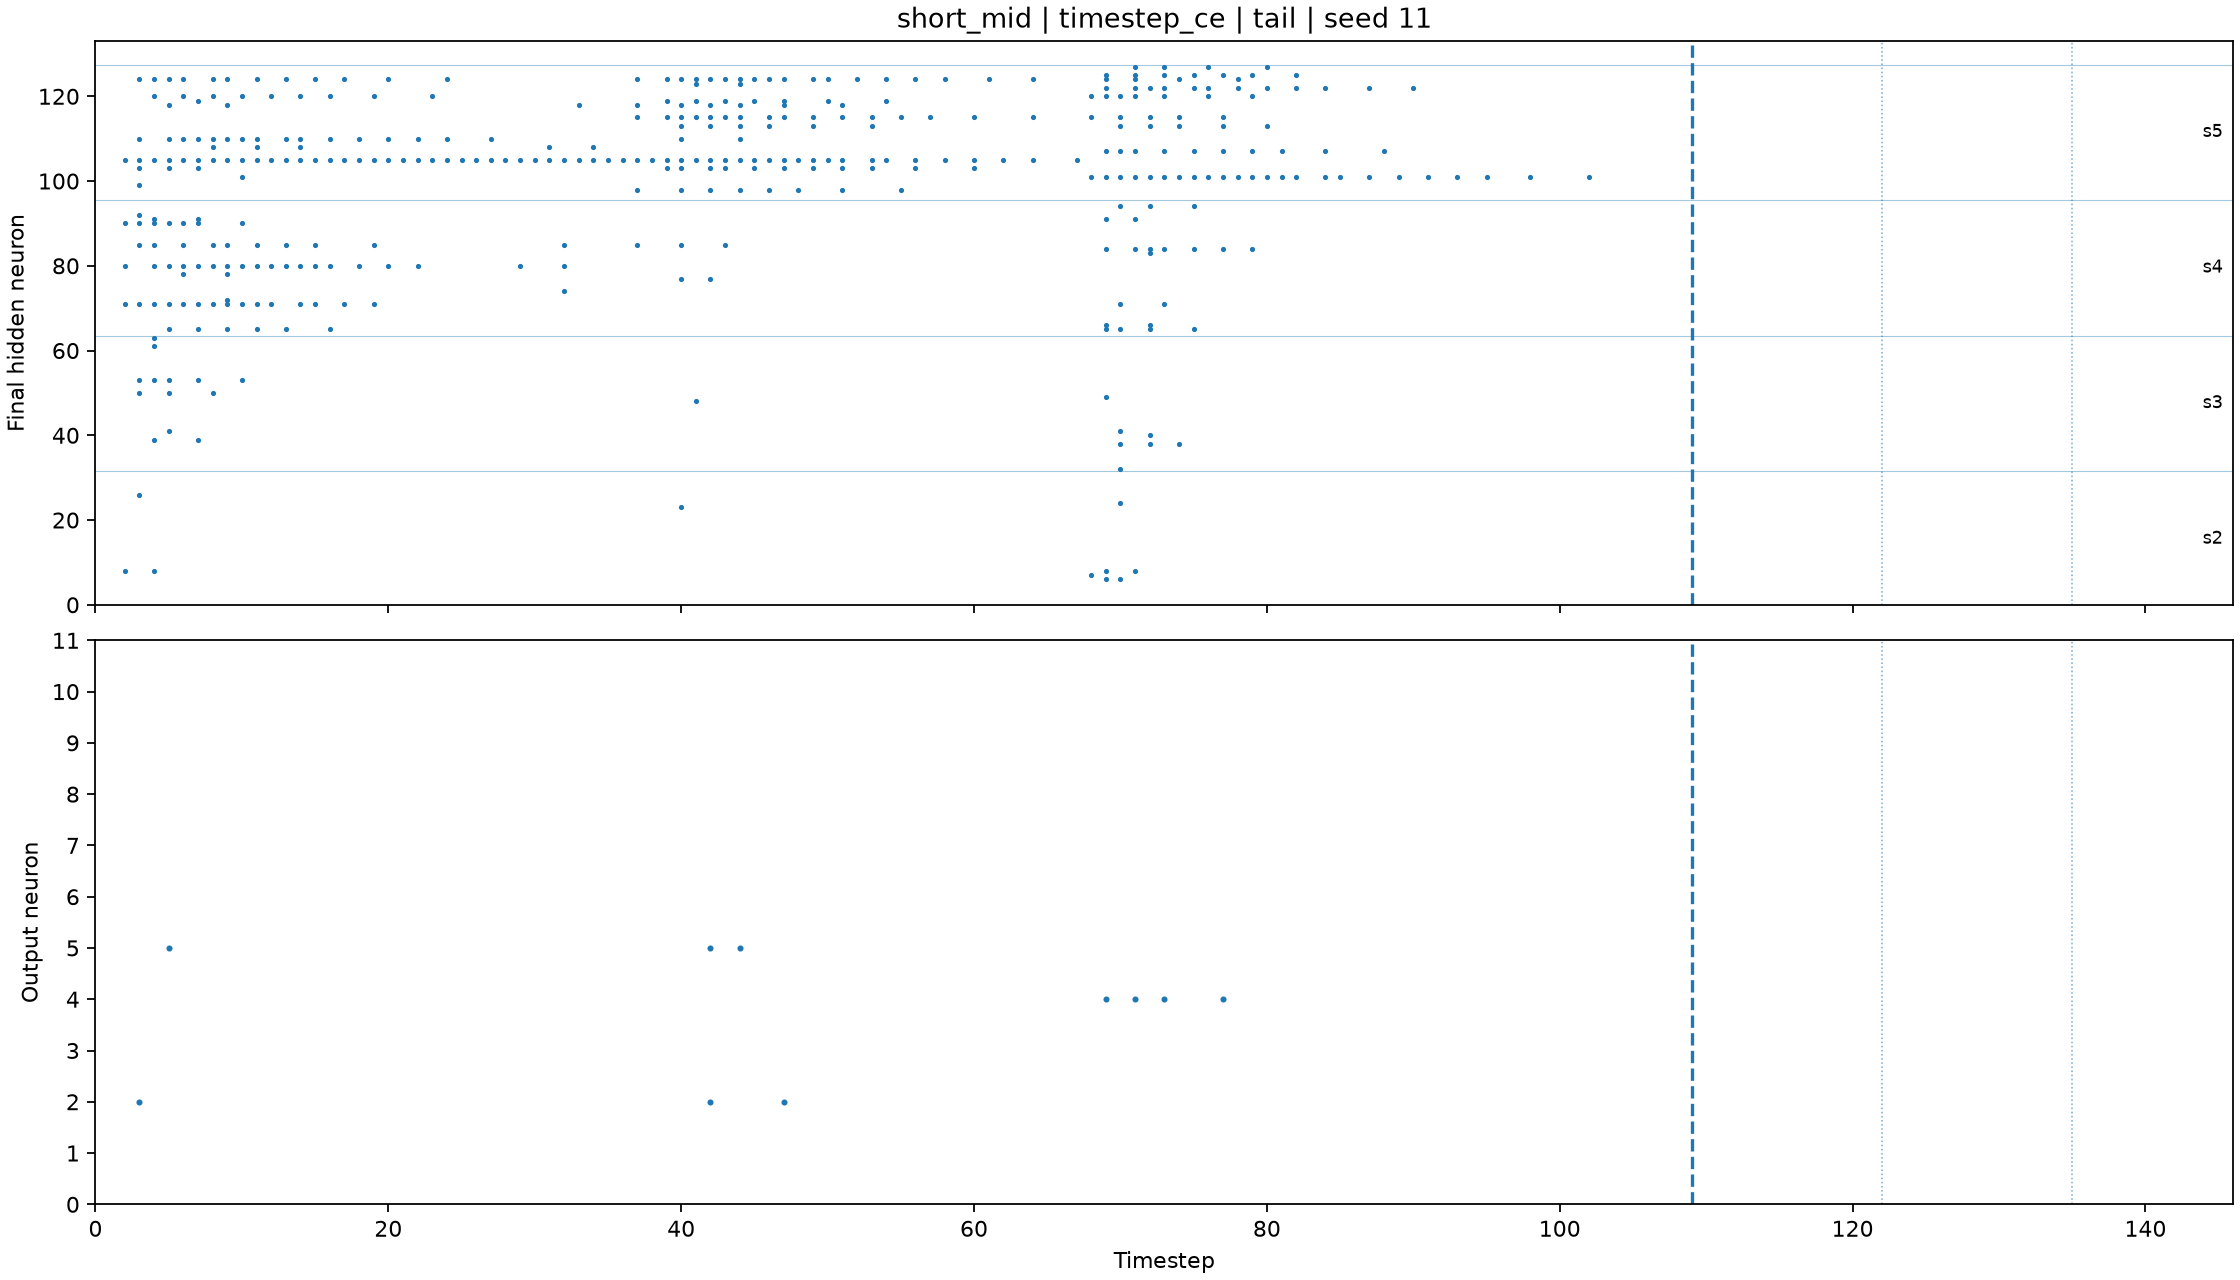

short_mid whole_count_ce a1 seed 11


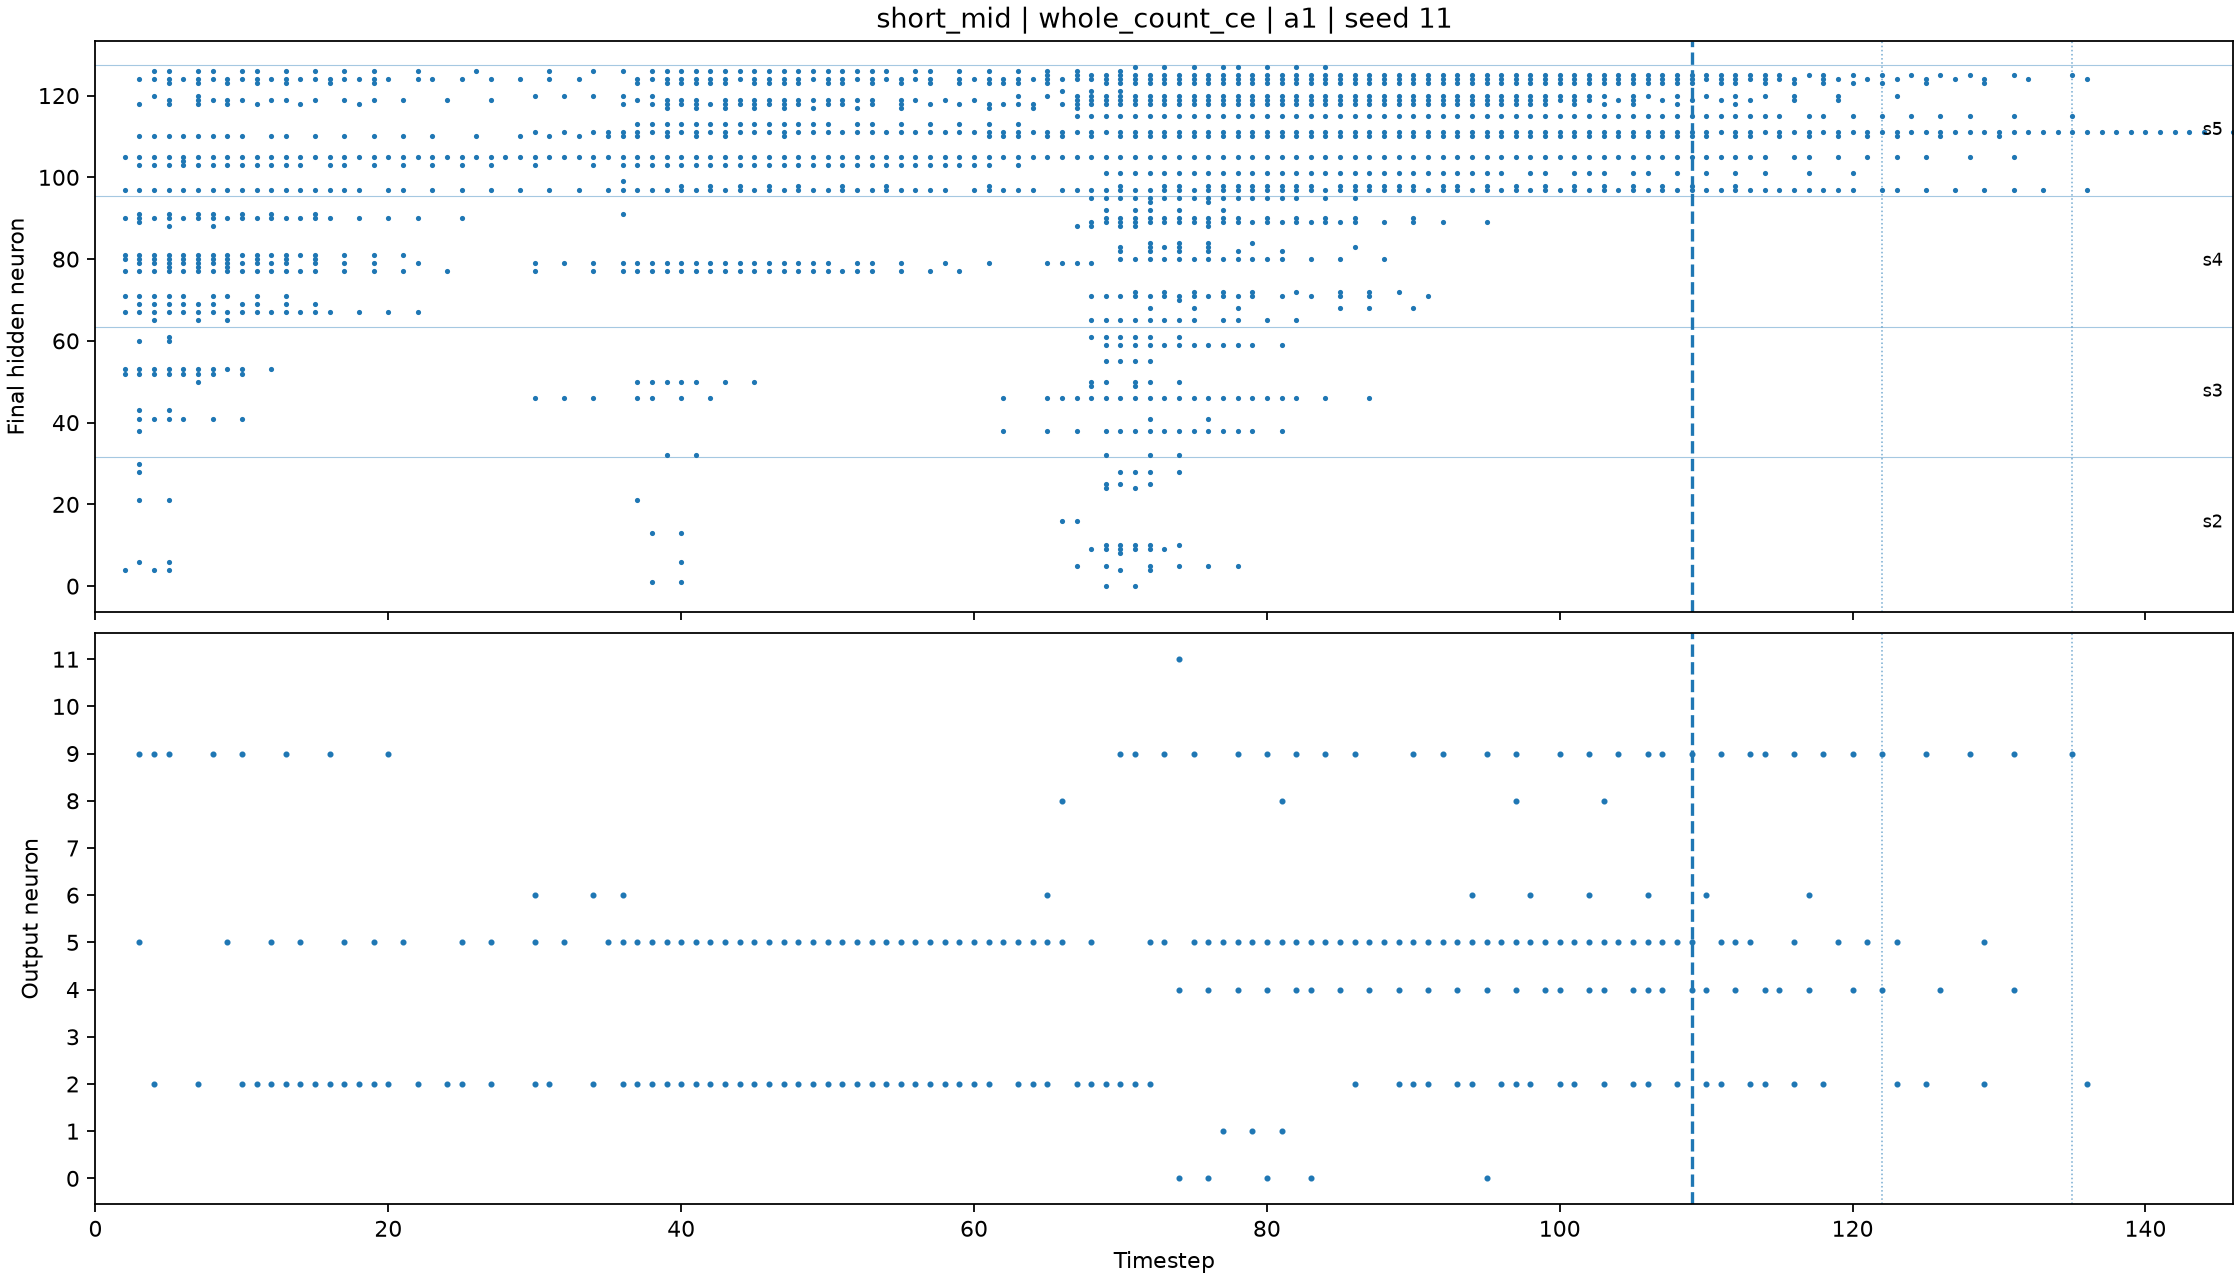

short_mid whole_count_ce a1_p2 seed 11


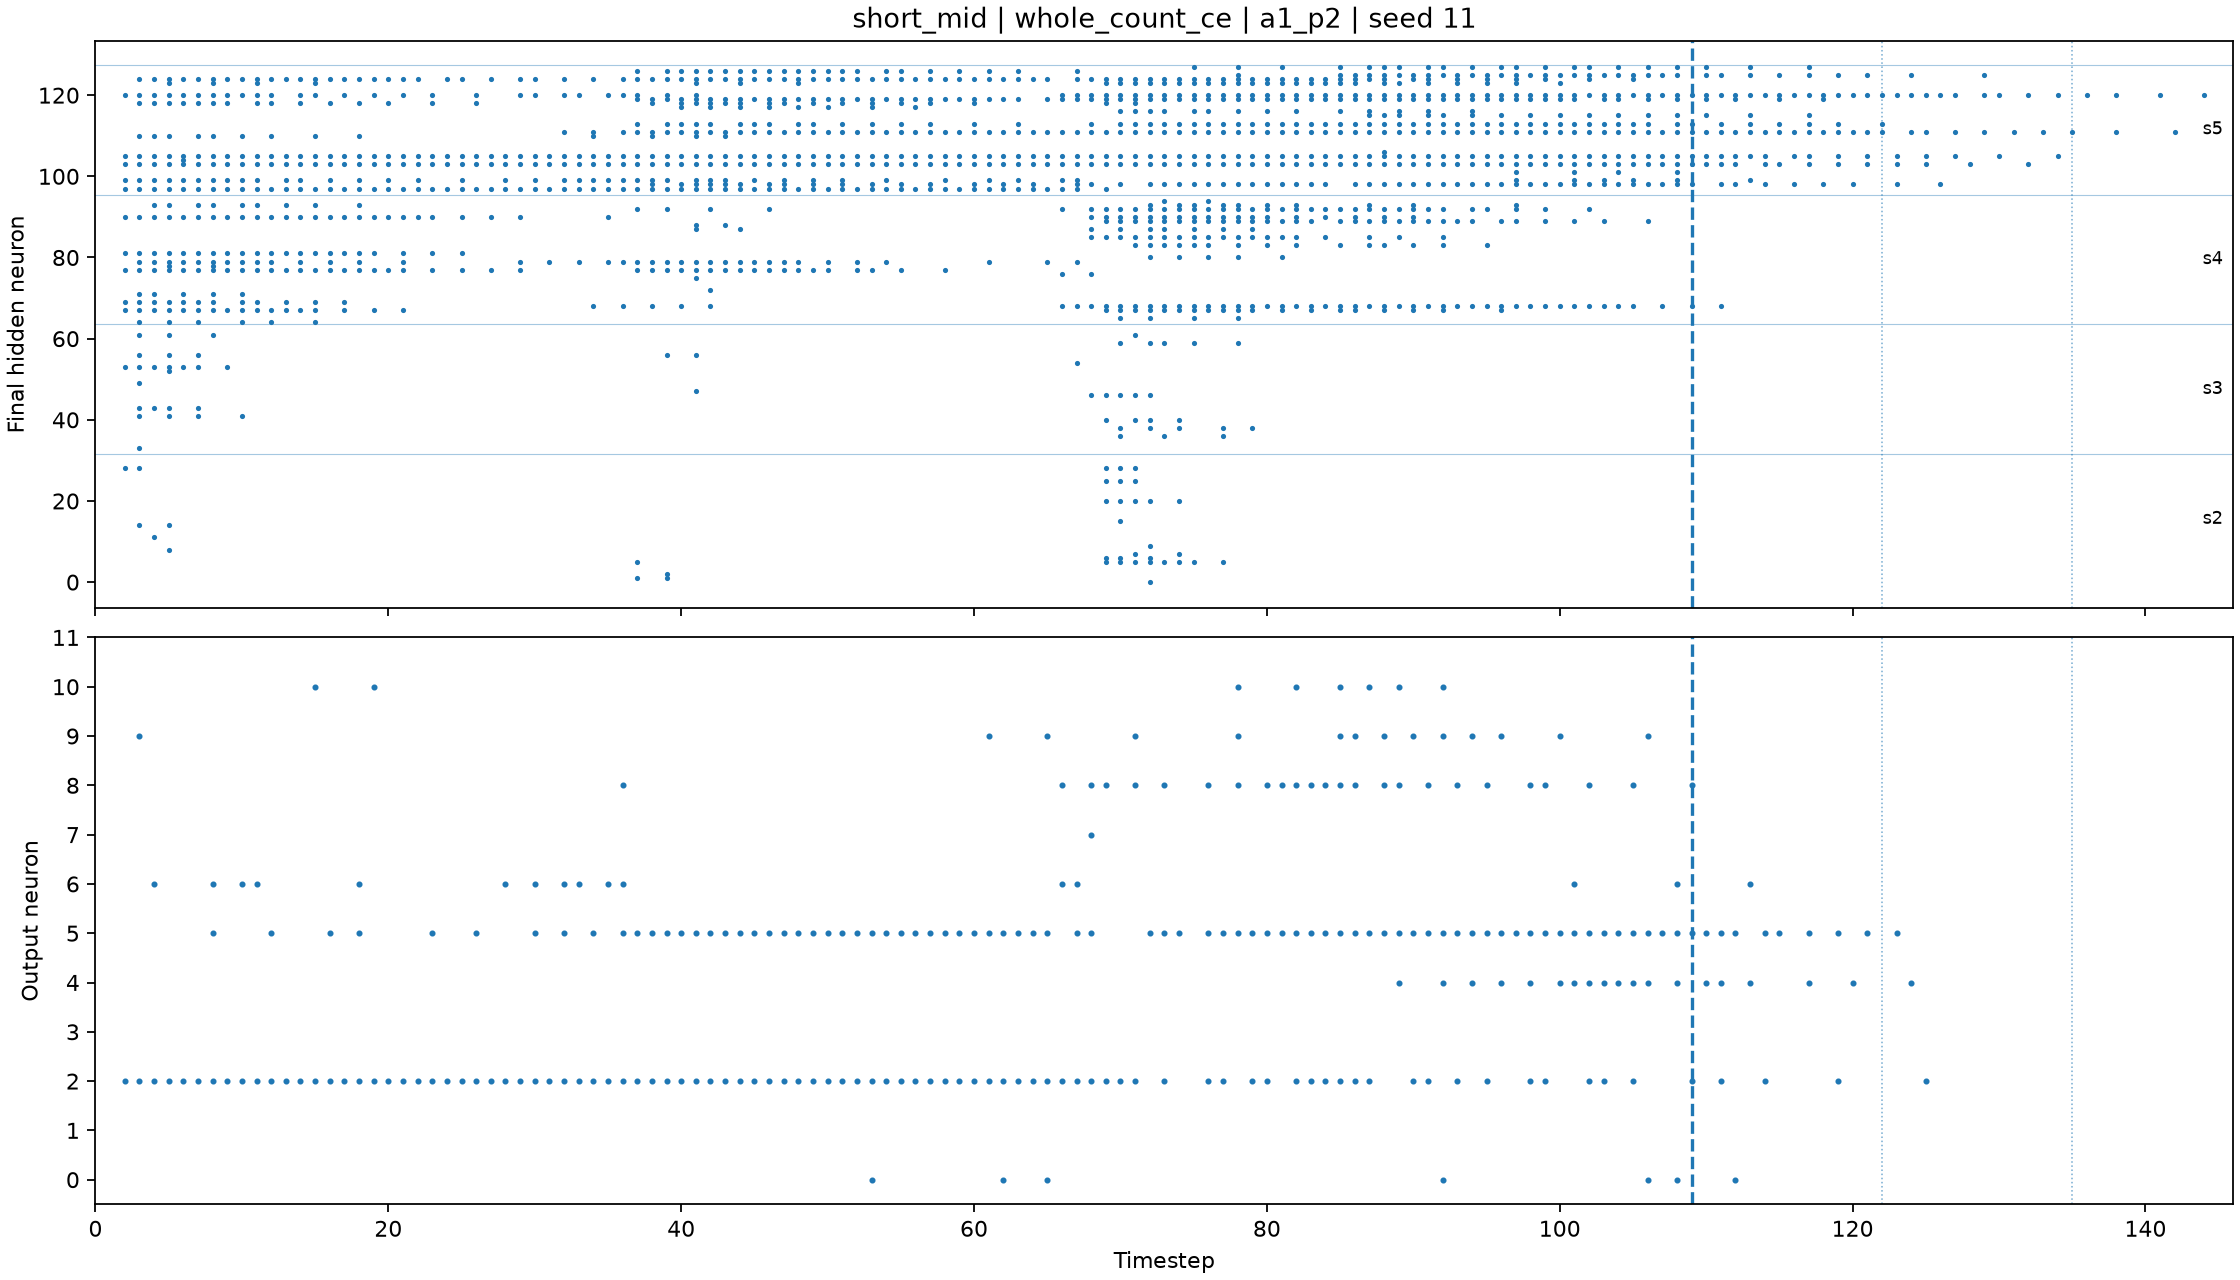

short_mid whole_count_ce a1_tail seed 11


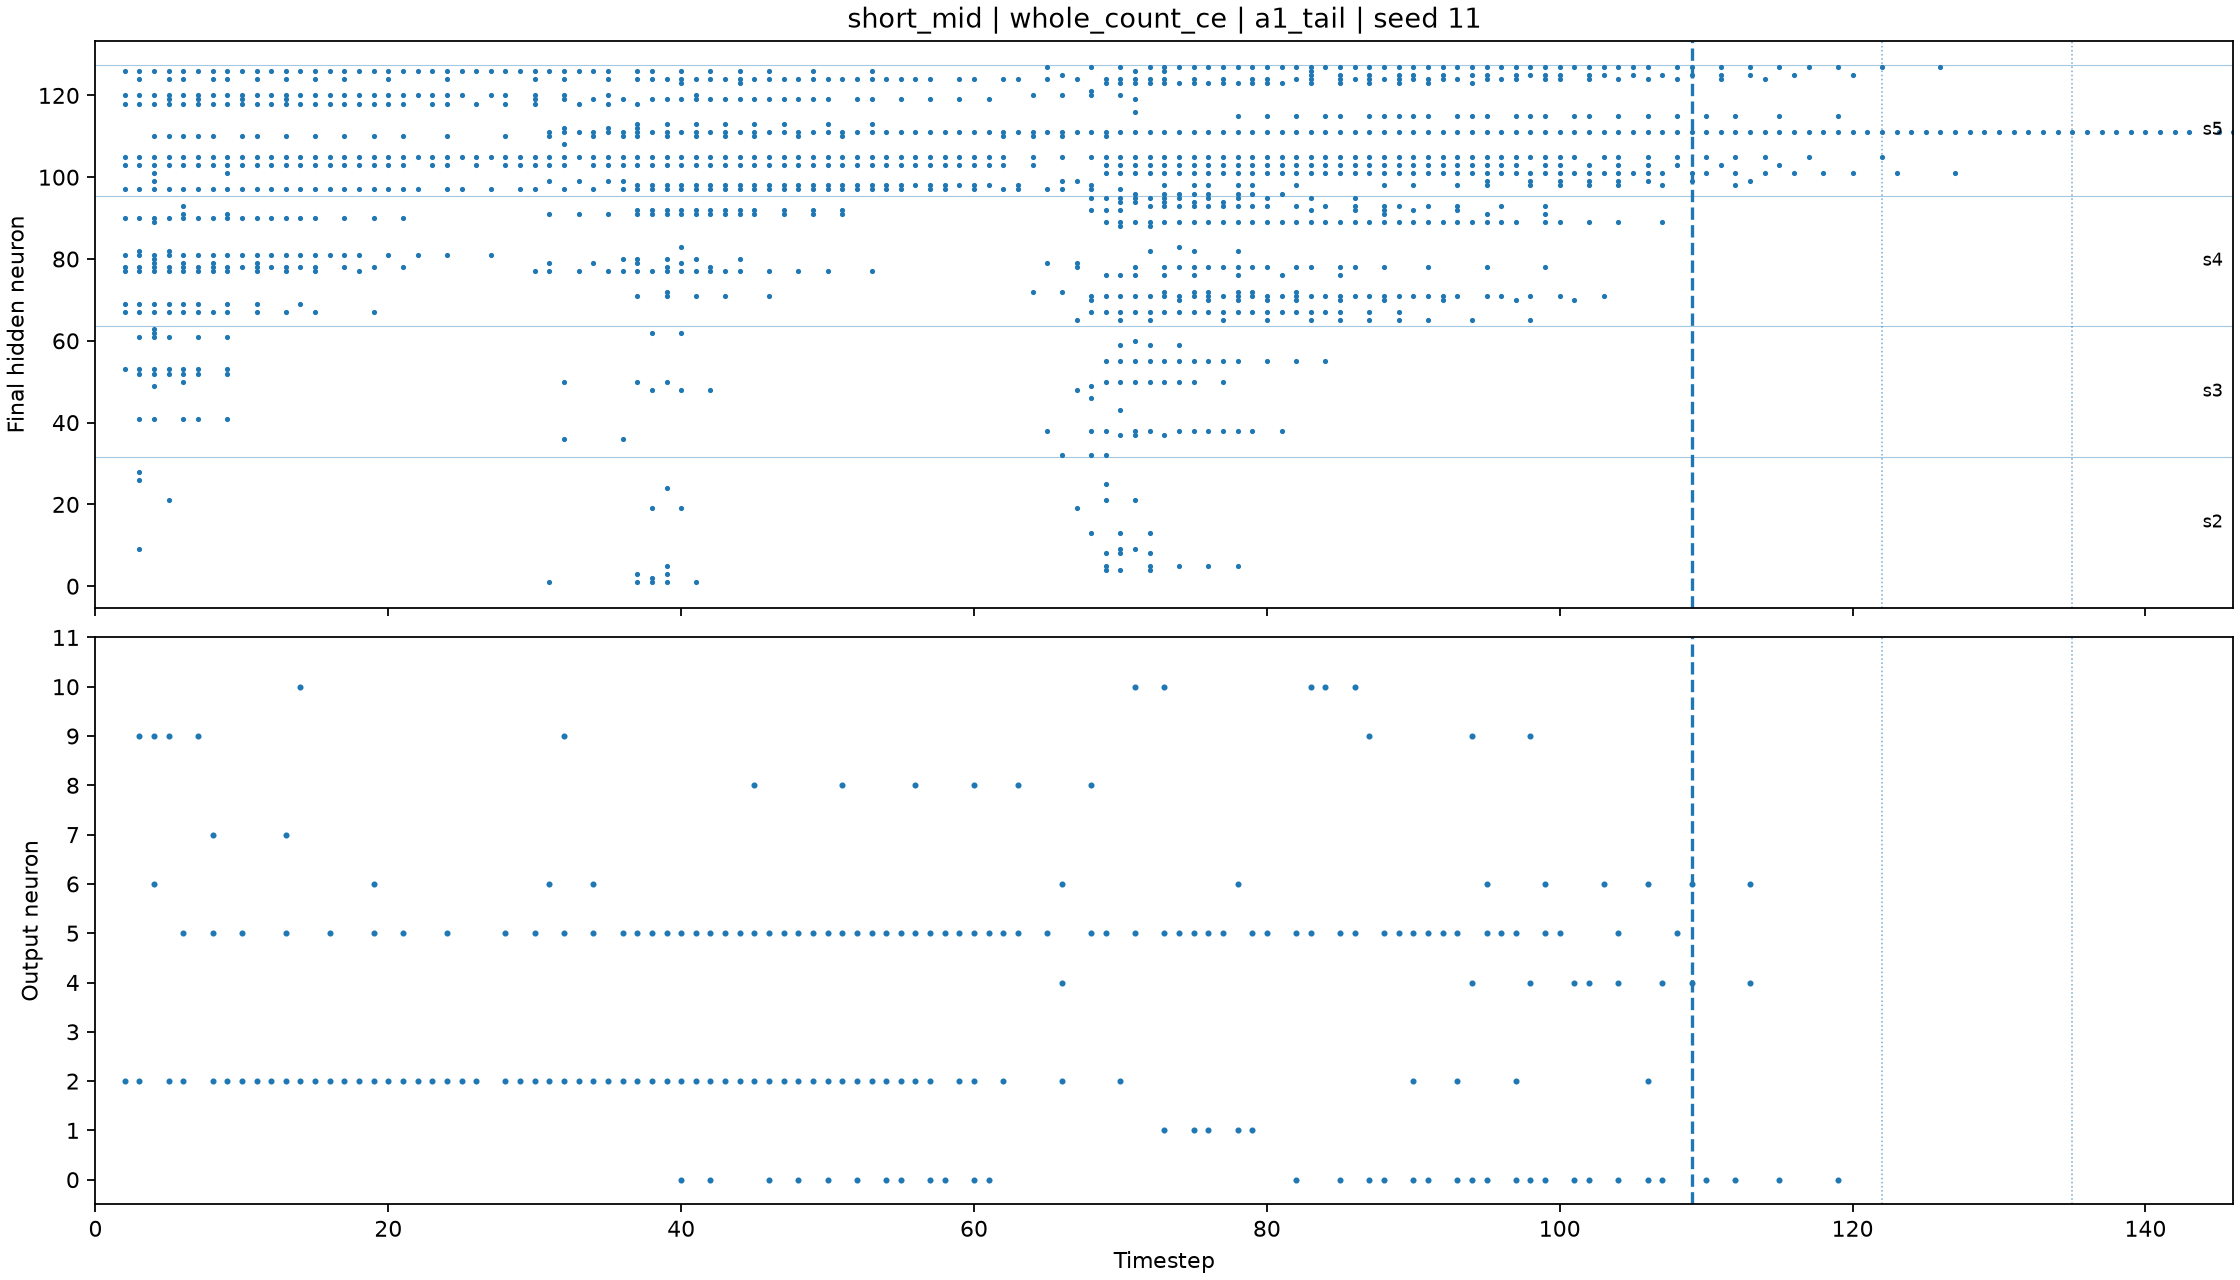

short_mid whole_count_ce none seed 11


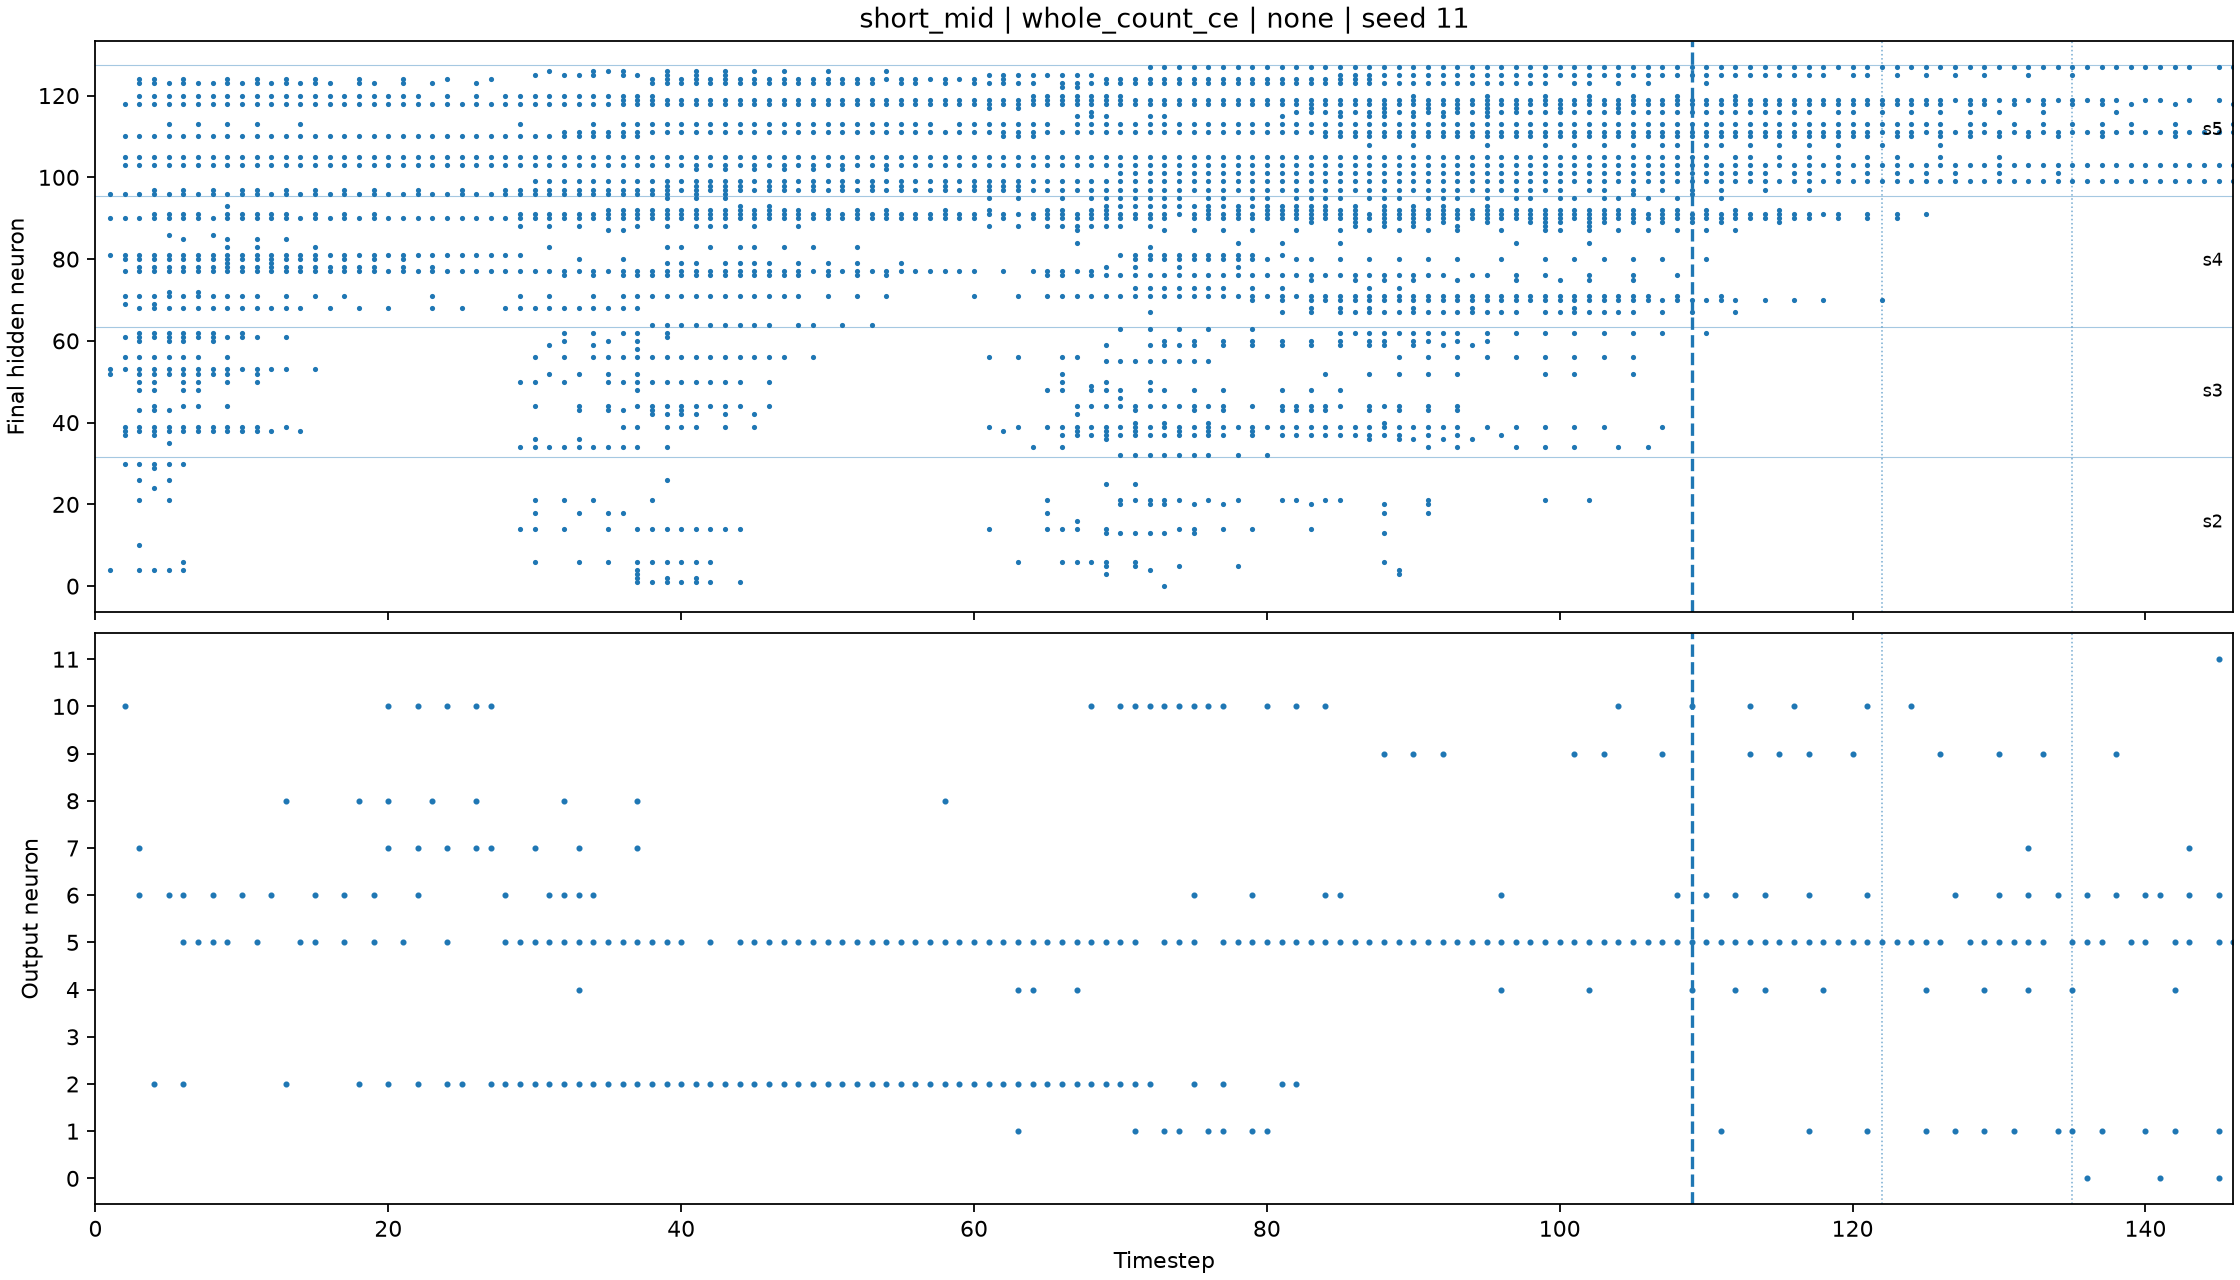

short_mid whole_count_ce tail seed 11


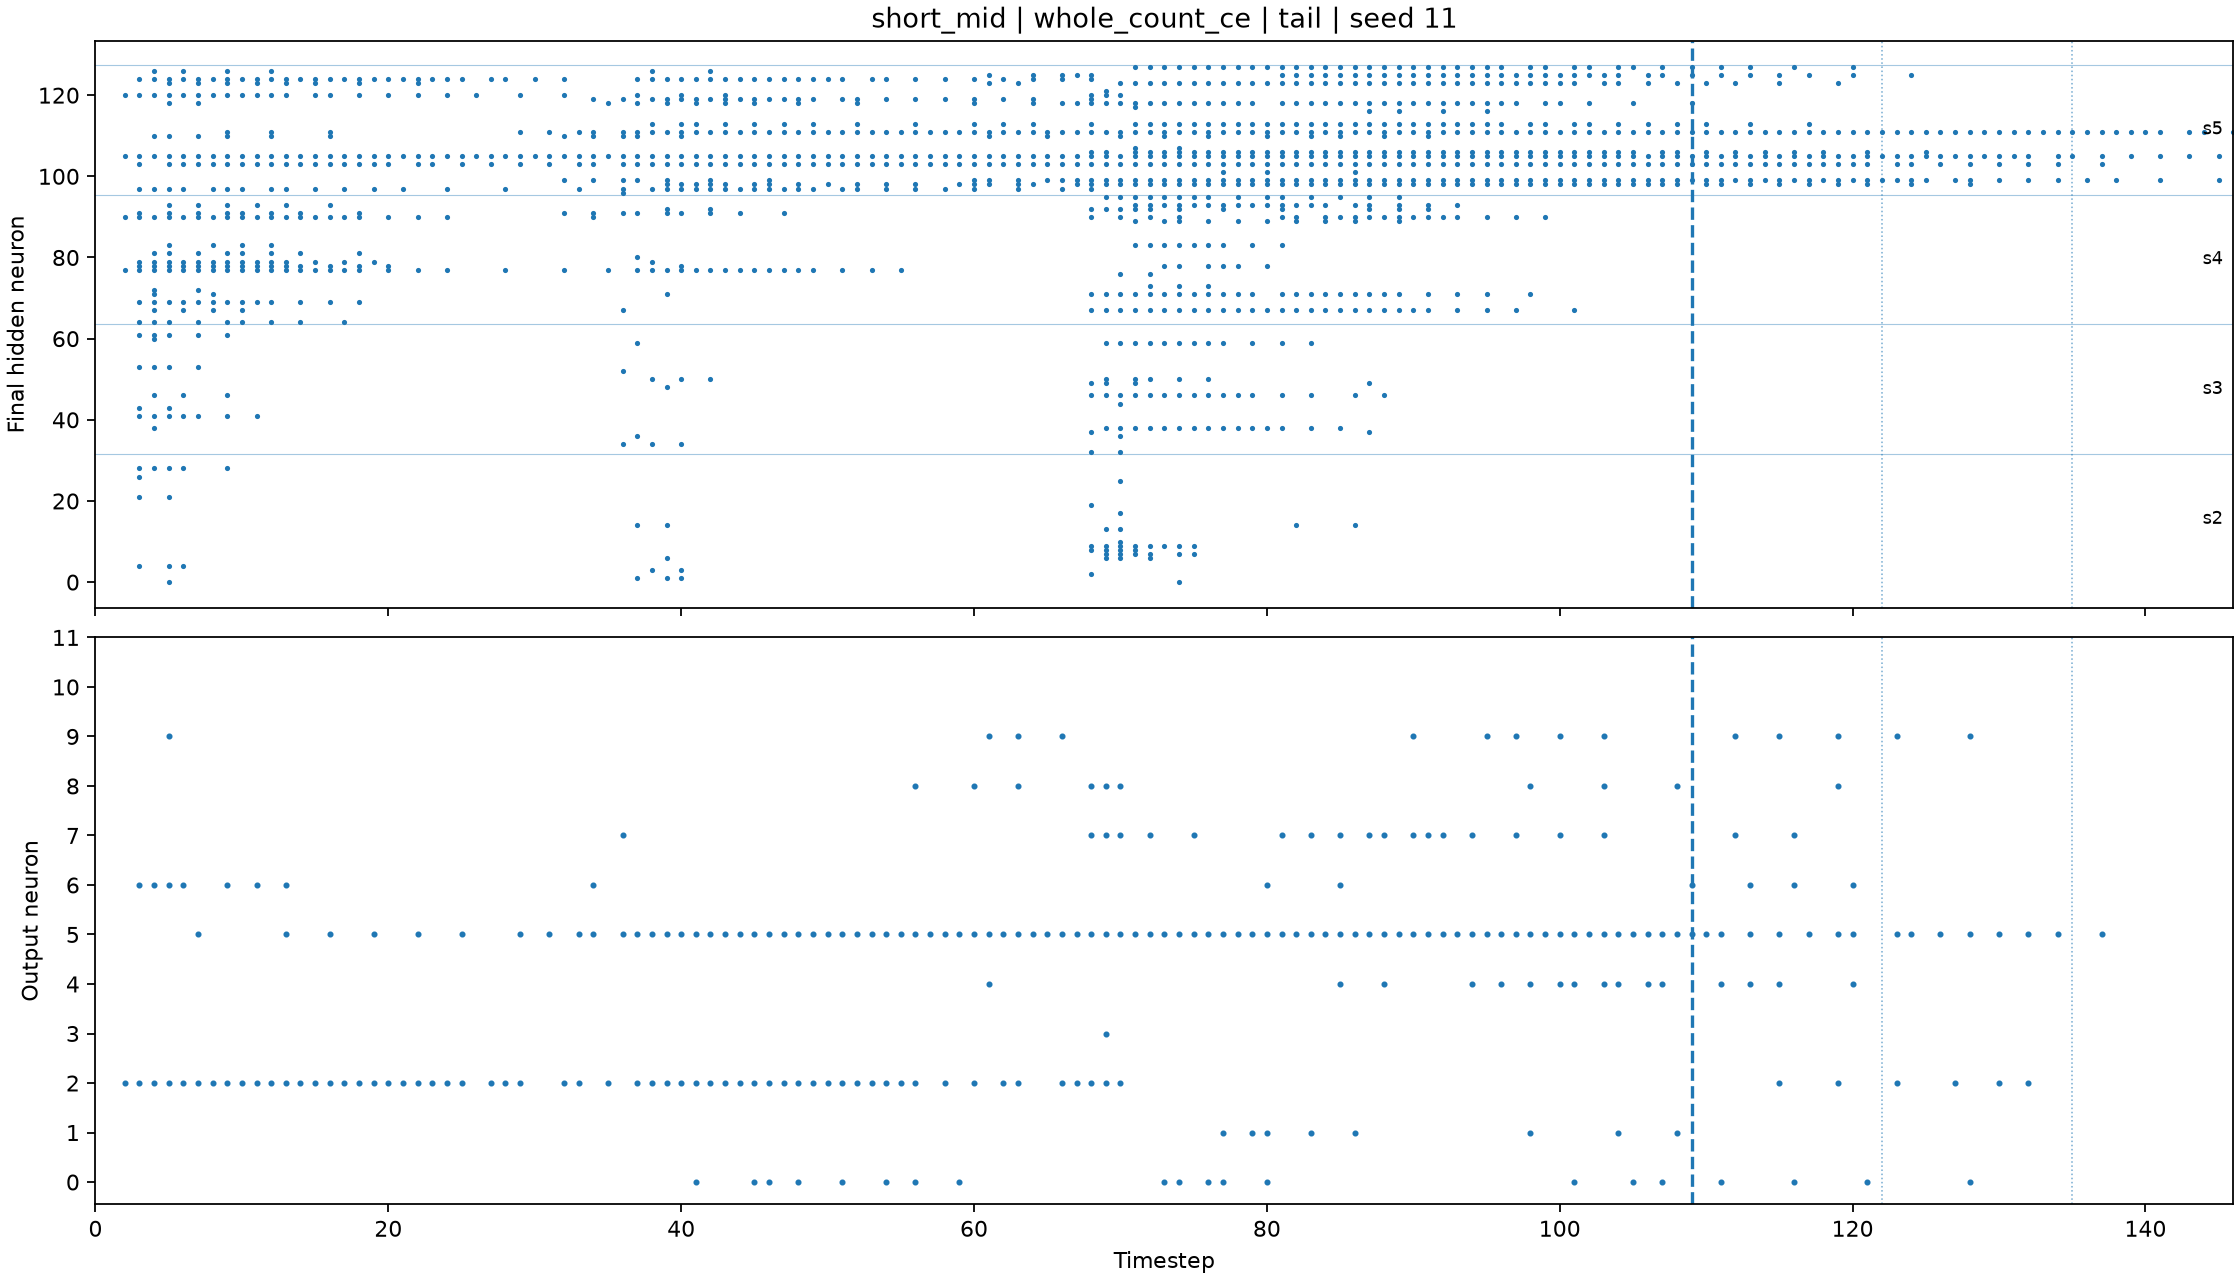

short_mid_long timestep_ce a1 seed 11


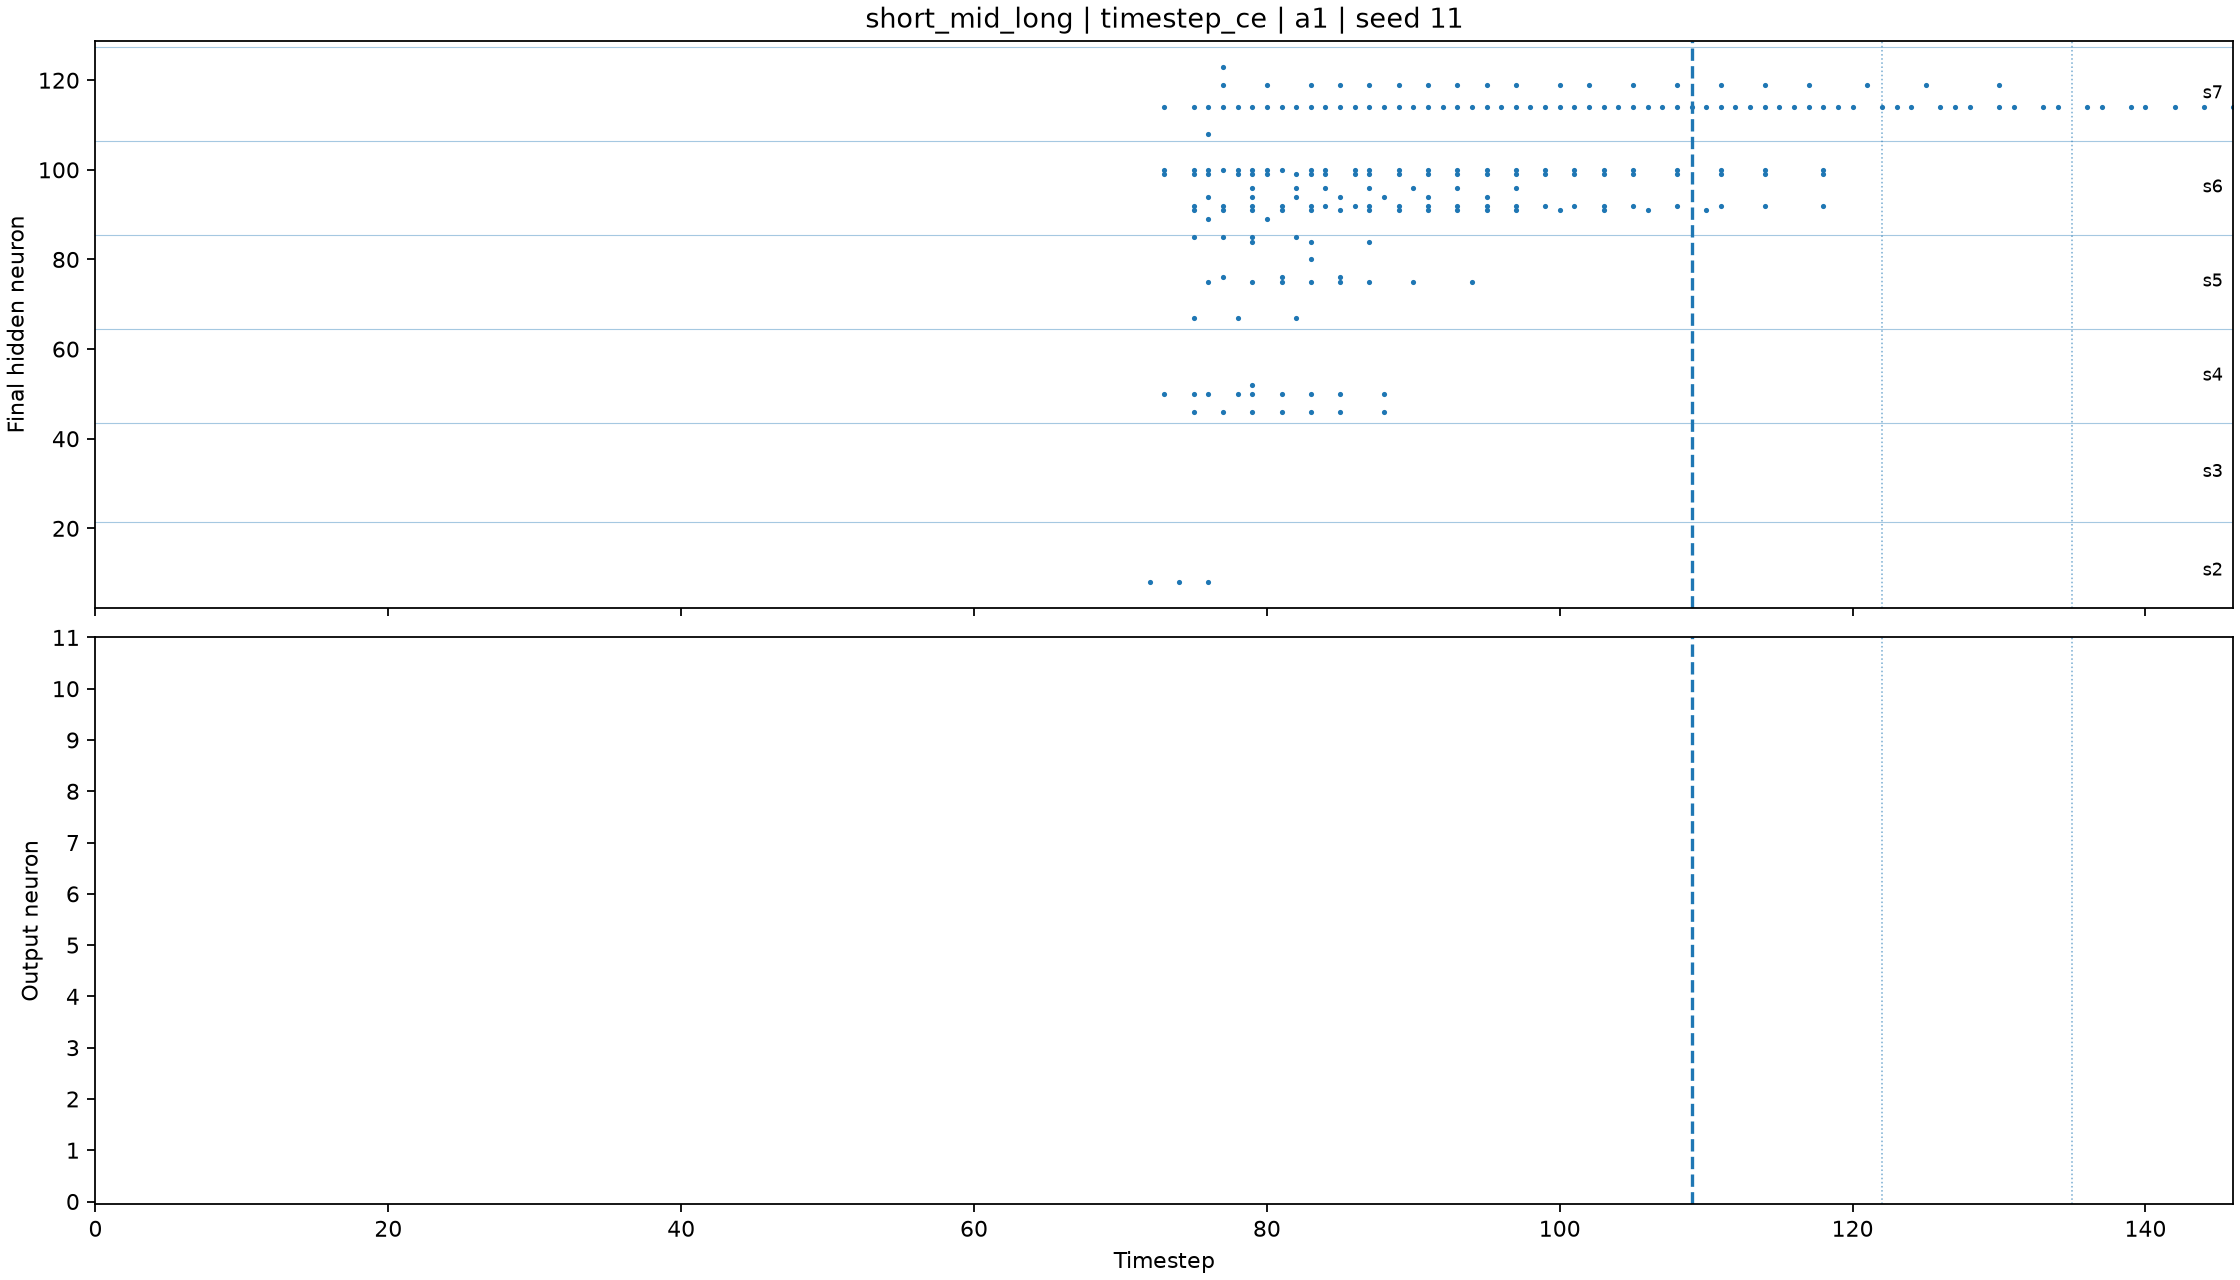

short_mid_long timestep_ce a1_p2 seed 11


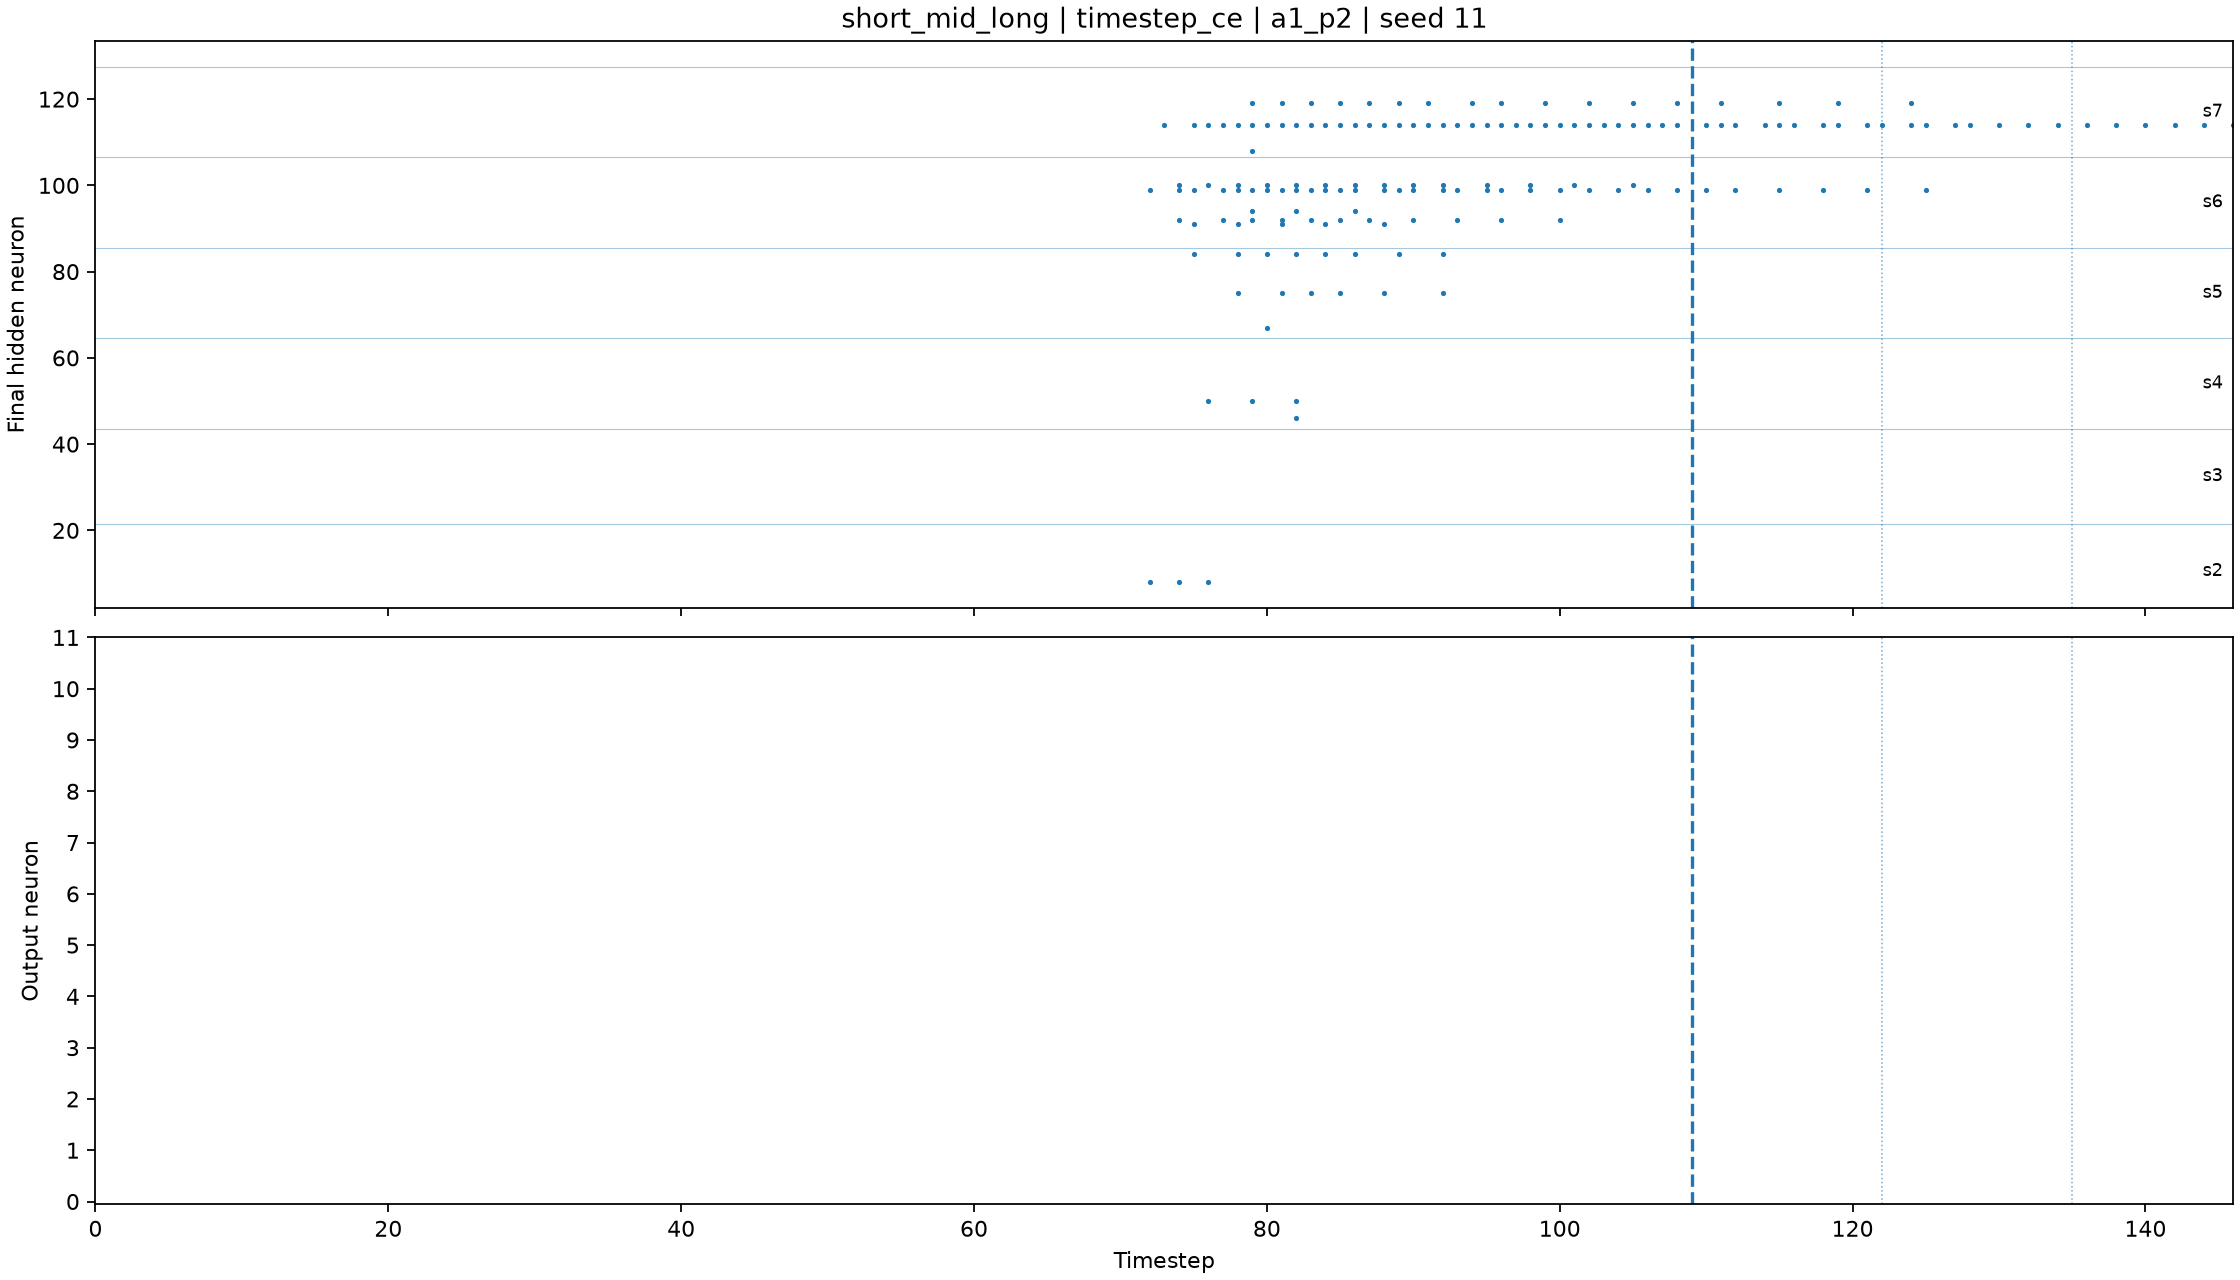

short_mid_long timestep_ce a1_tail seed 11


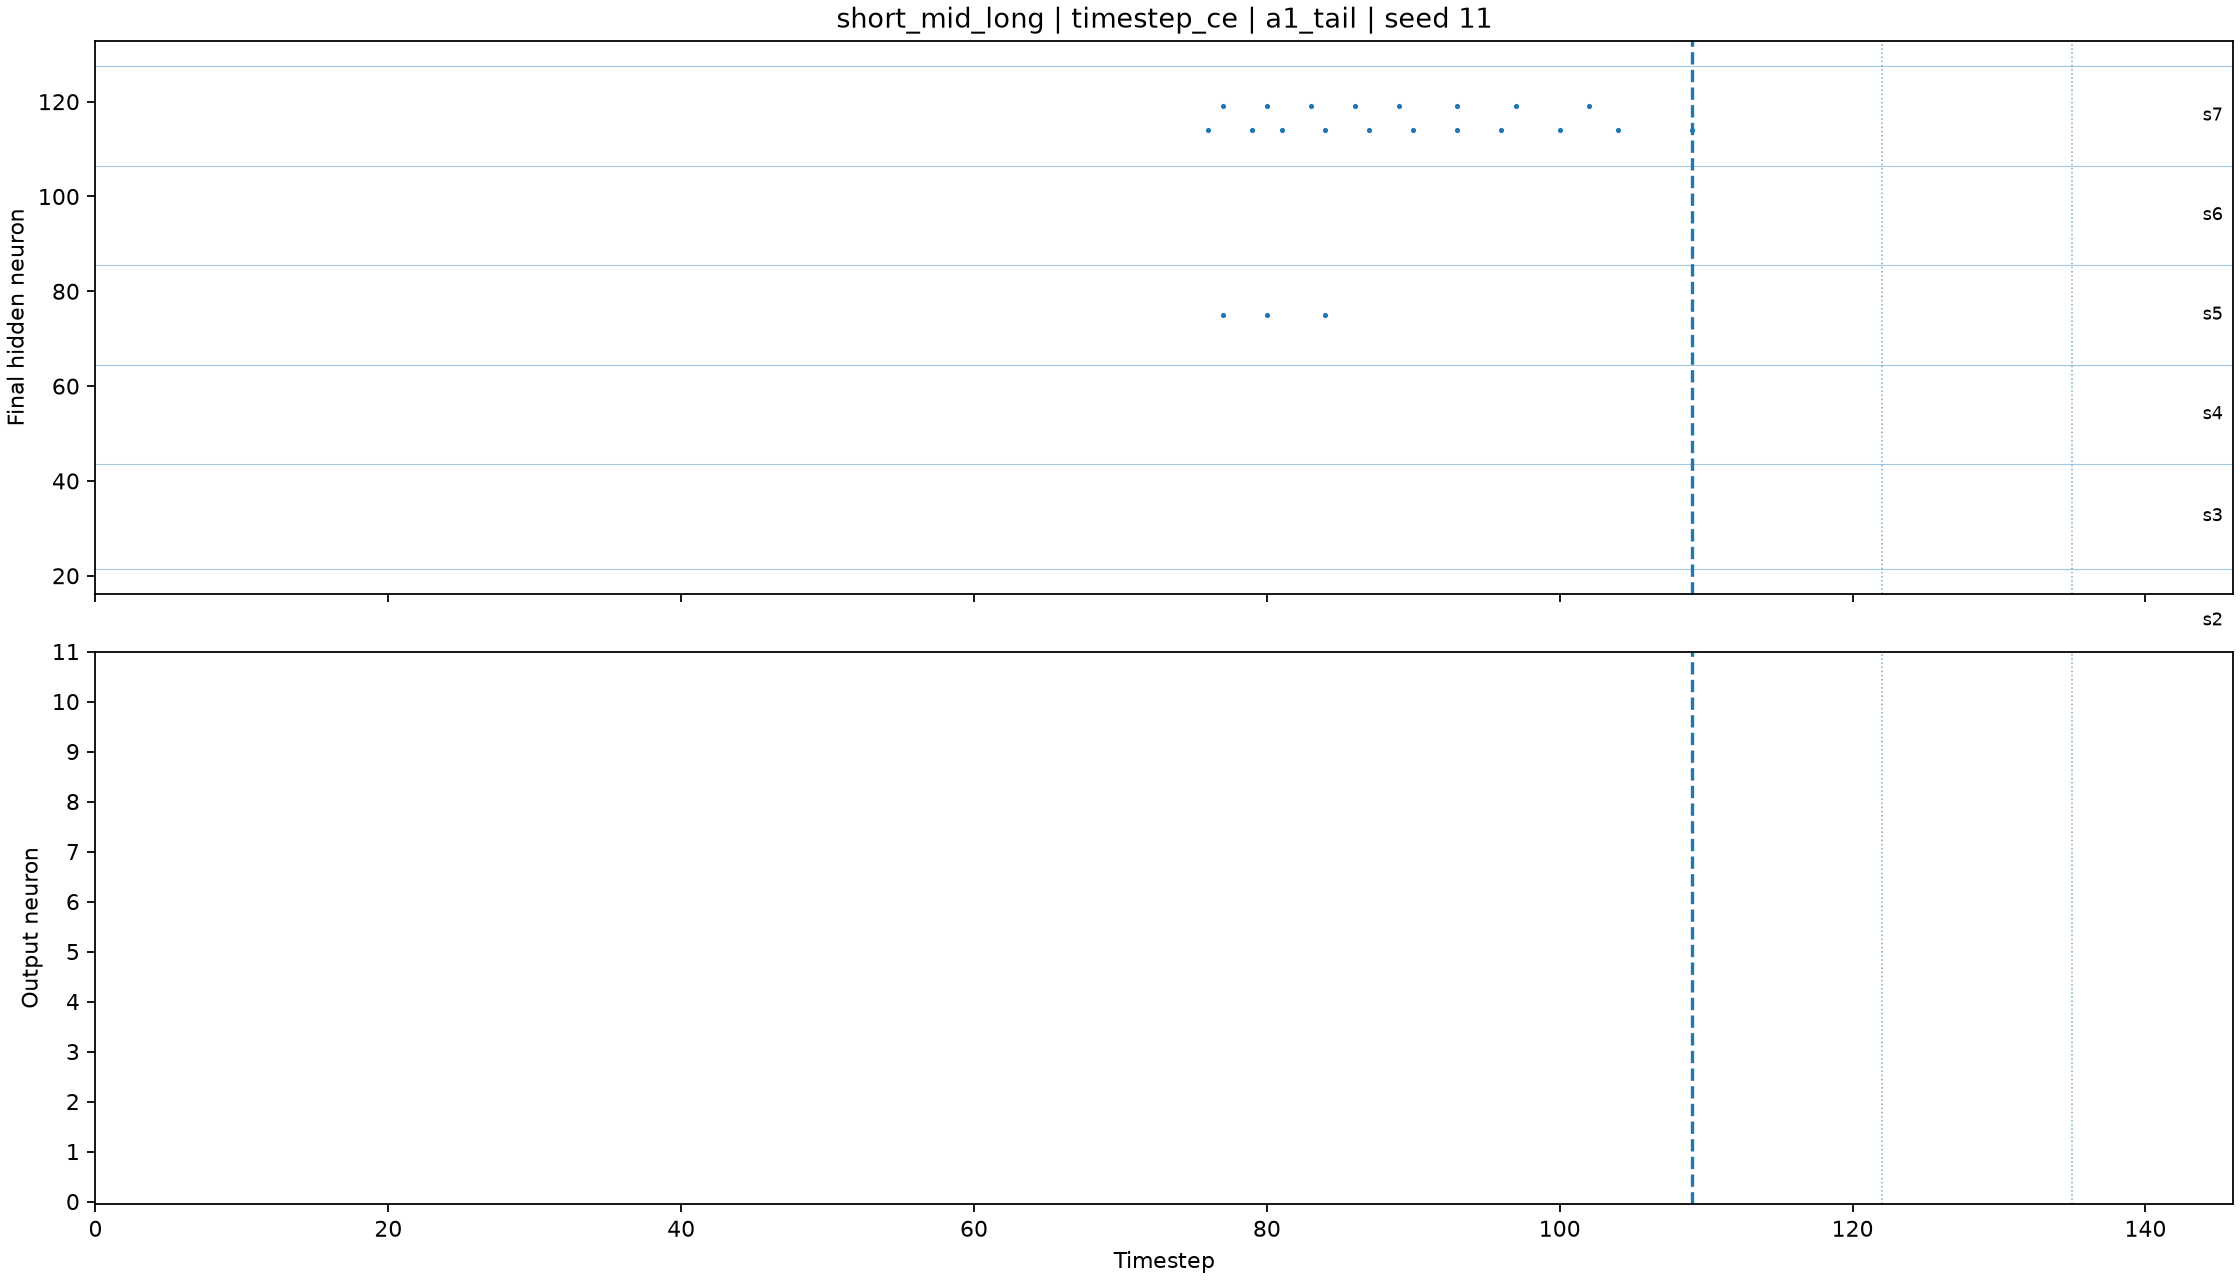

short_mid_long timestep_ce none seed 11


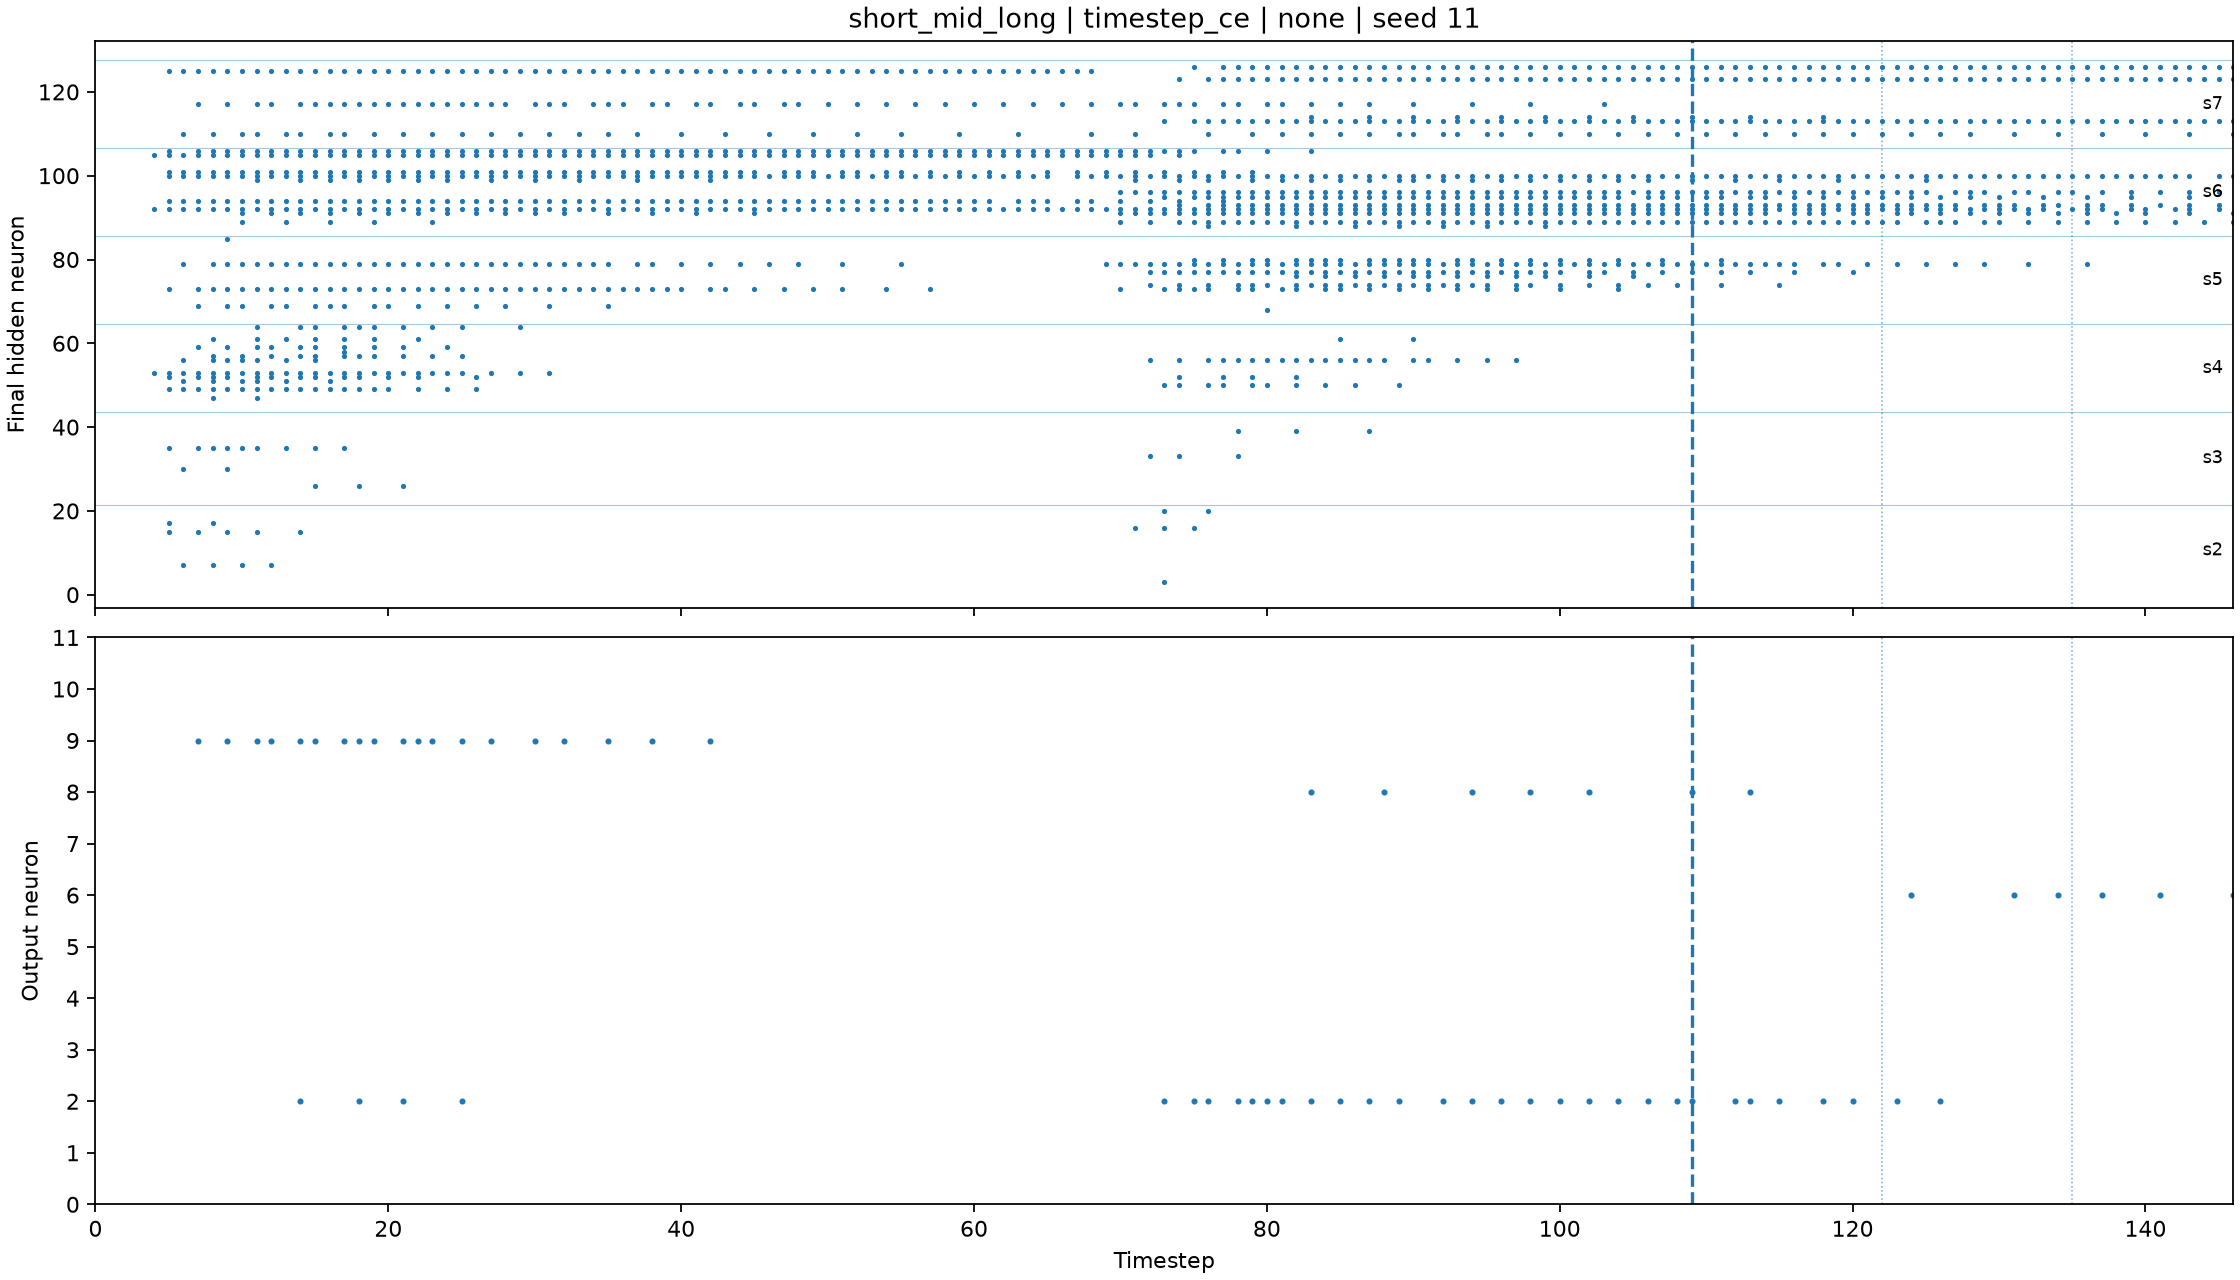

short_mid_long timestep_ce tail seed 11


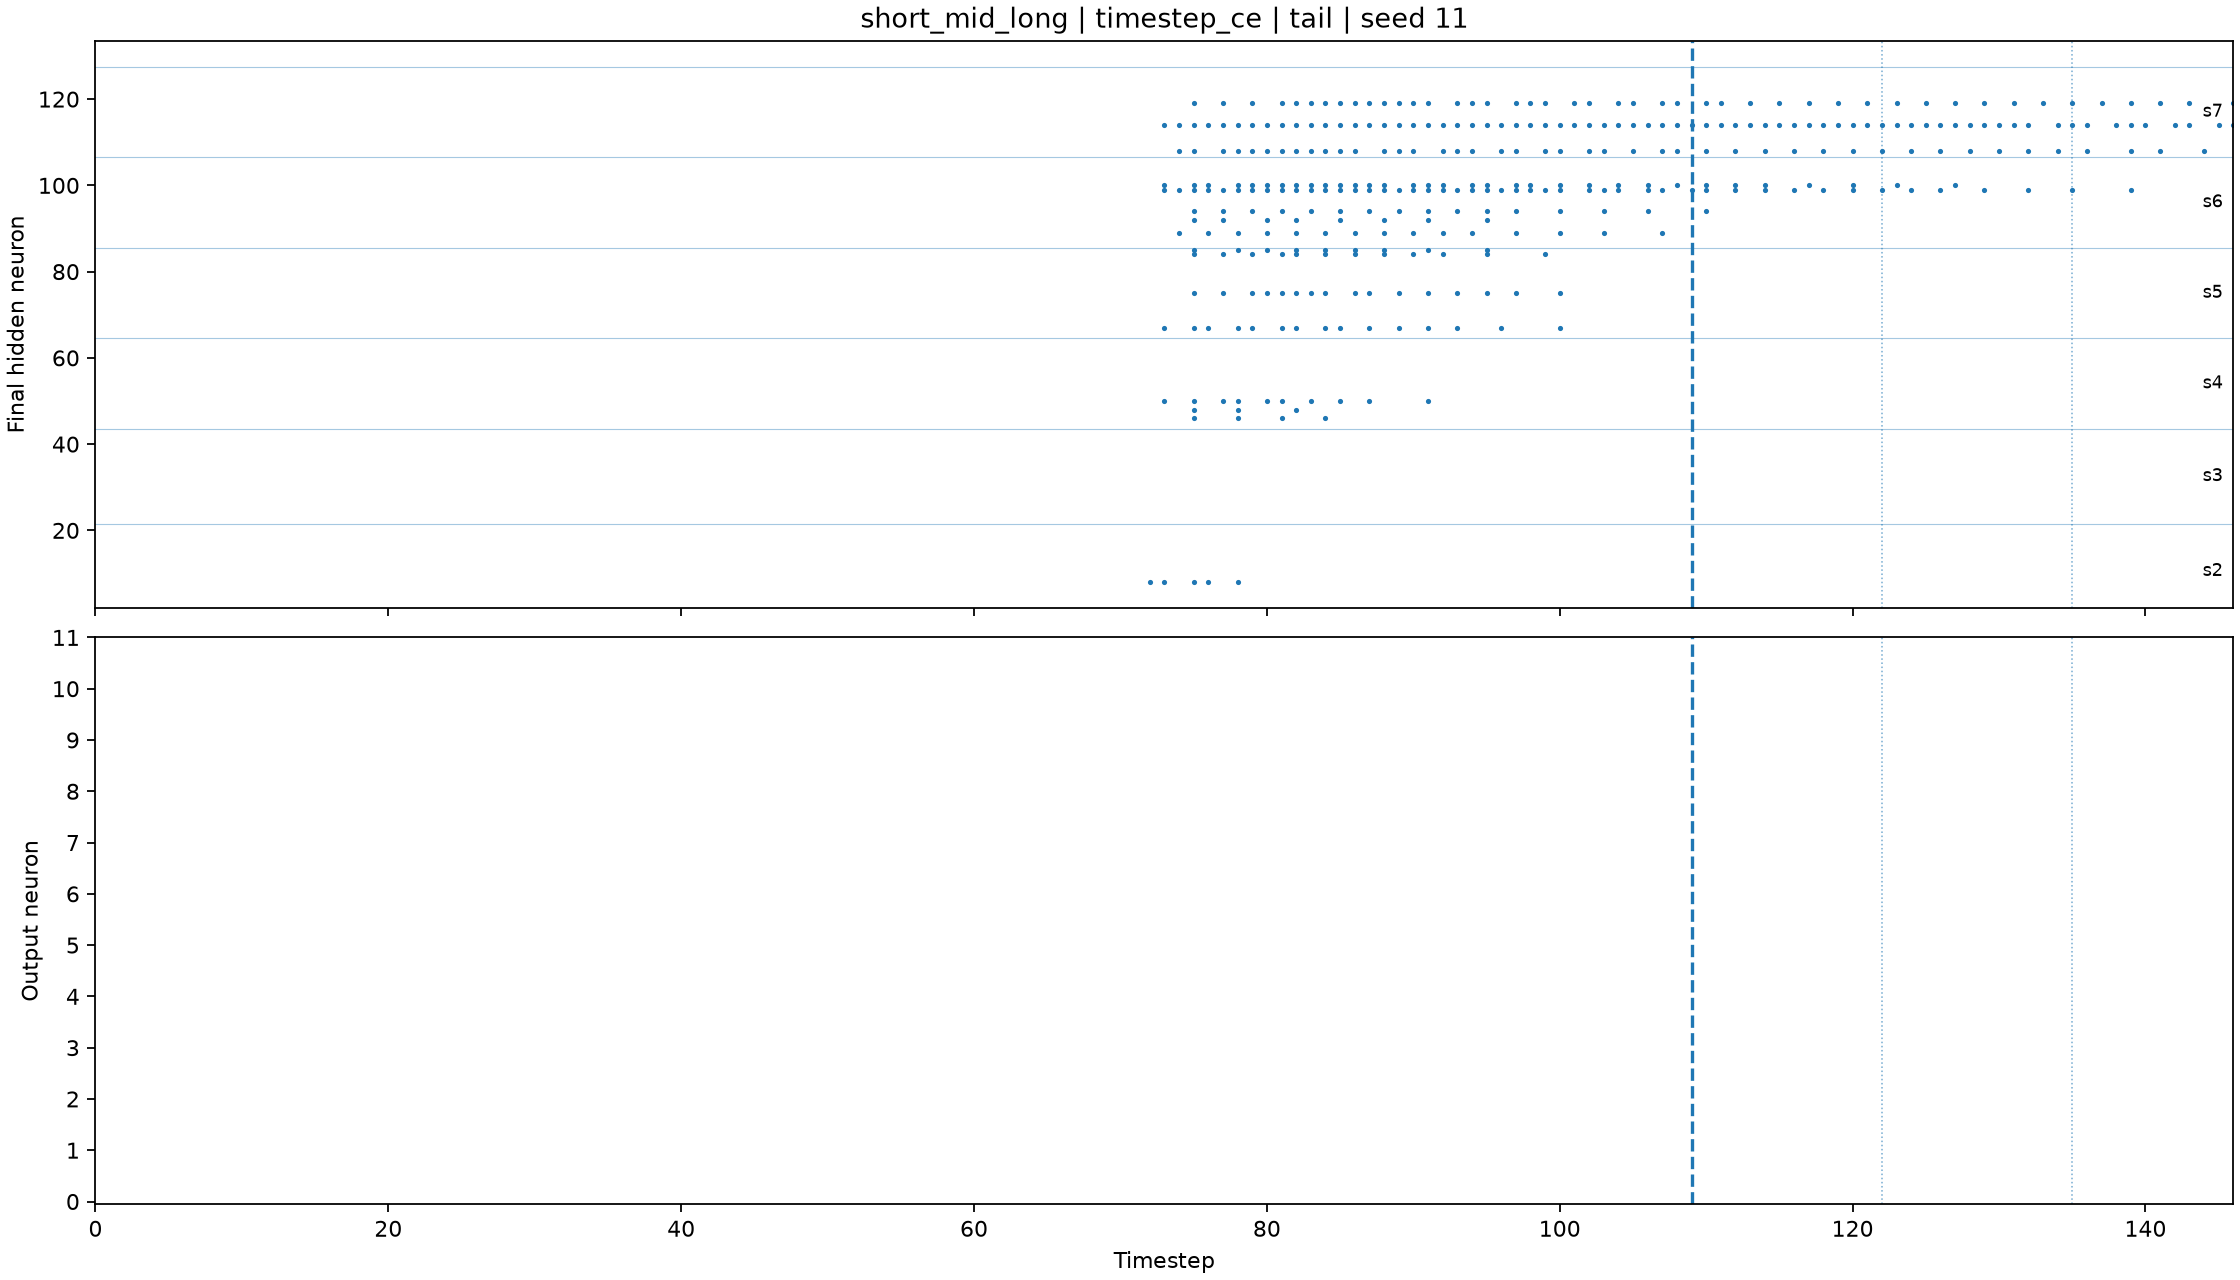

short_mid_long whole_count_ce a1 seed 11


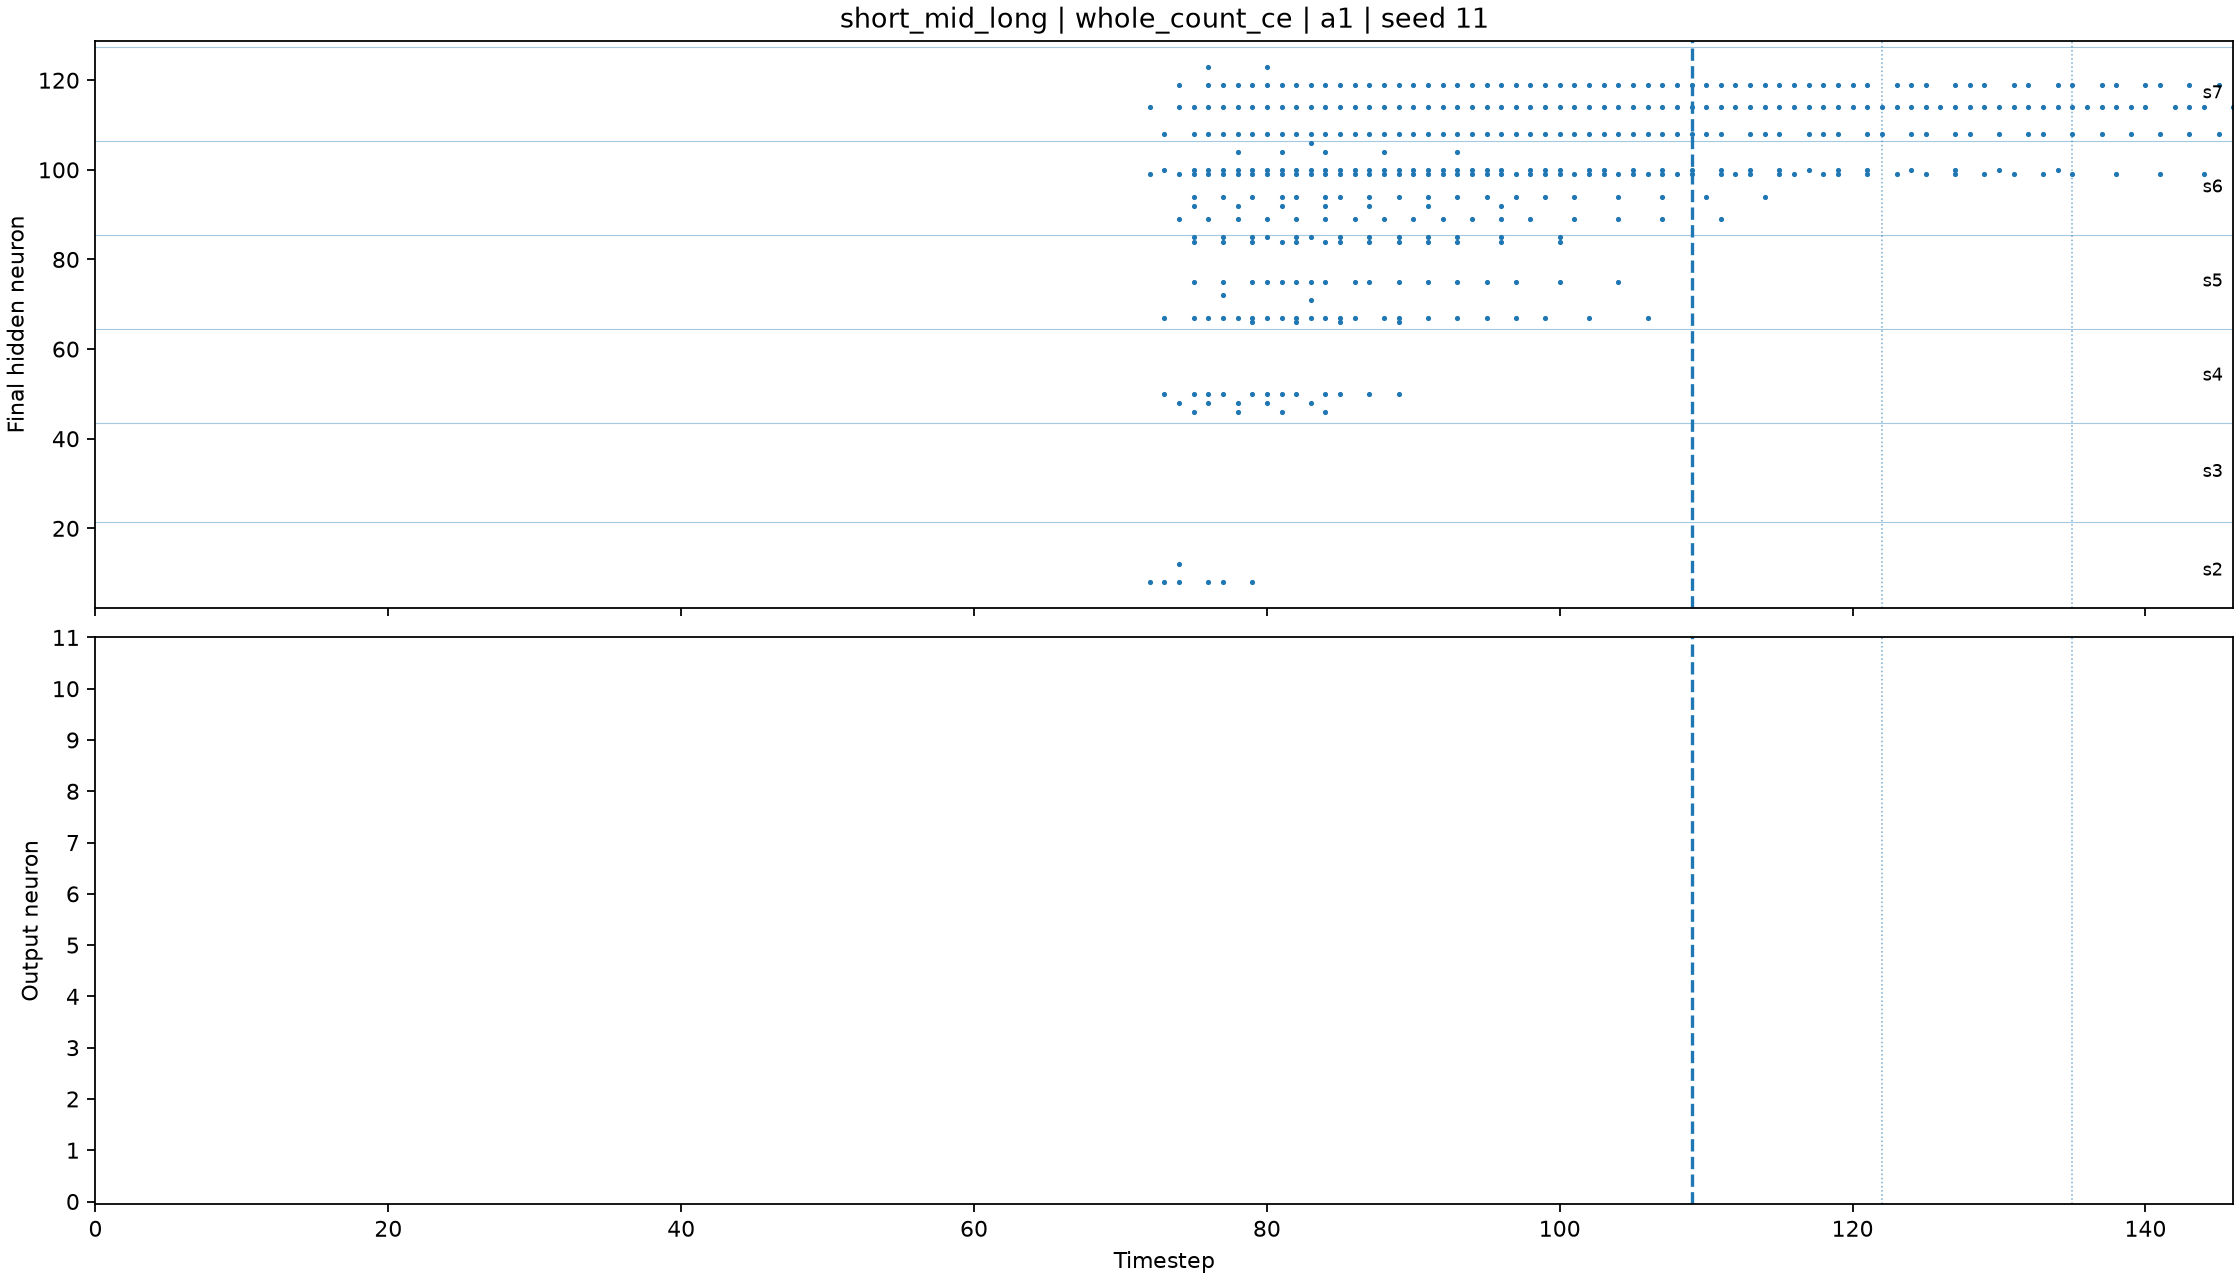

short_mid_long whole_count_ce a1_p2 seed 11


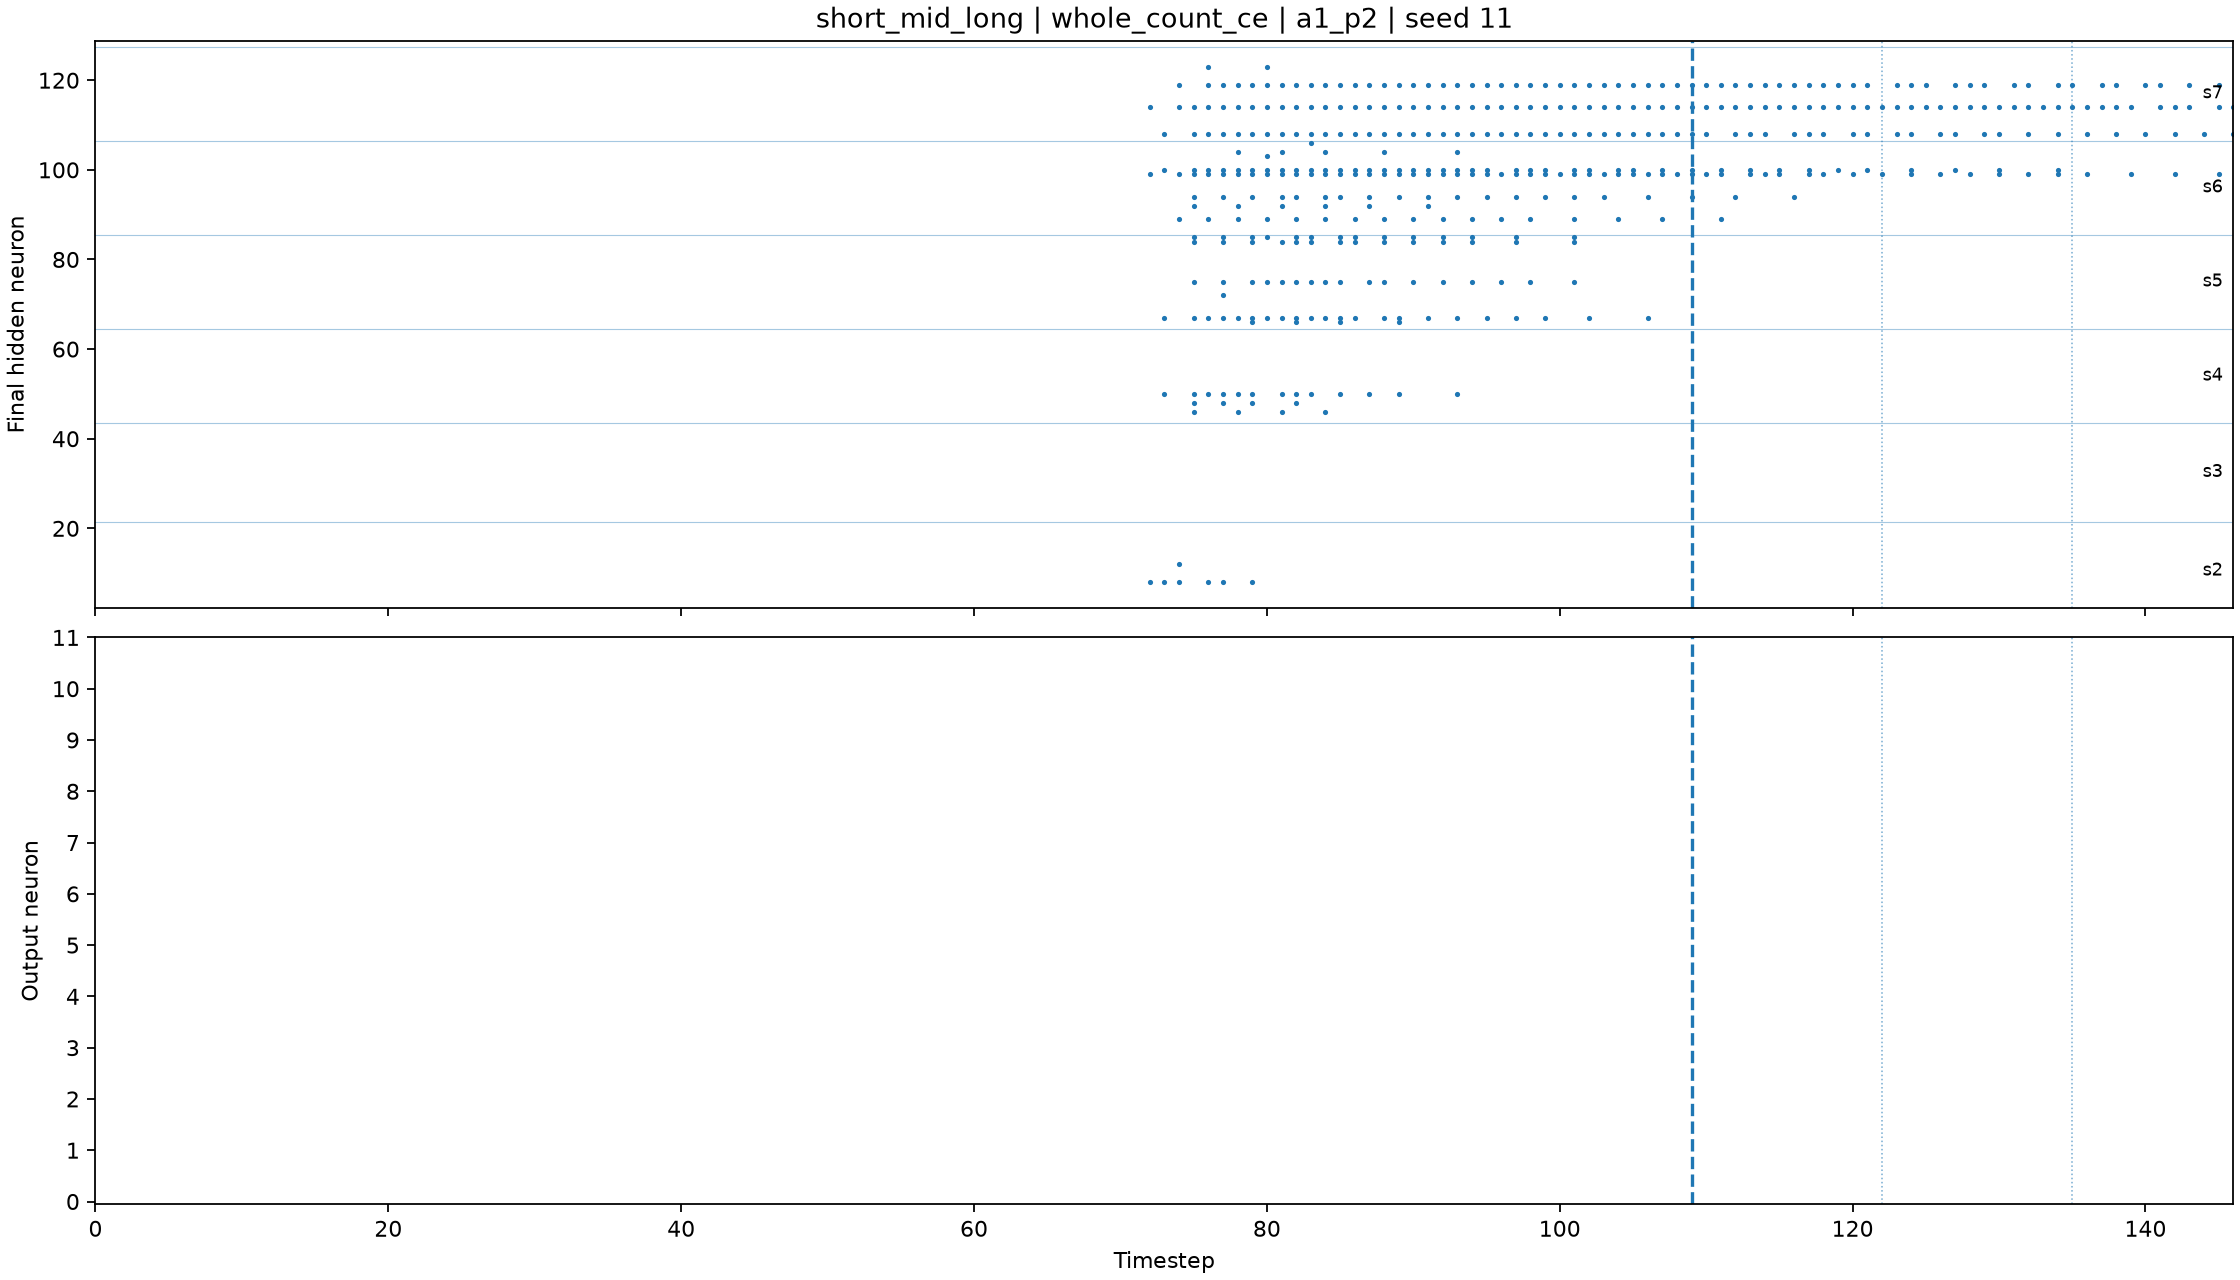

short_mid_long whole_count_ce a1_tail seed 11


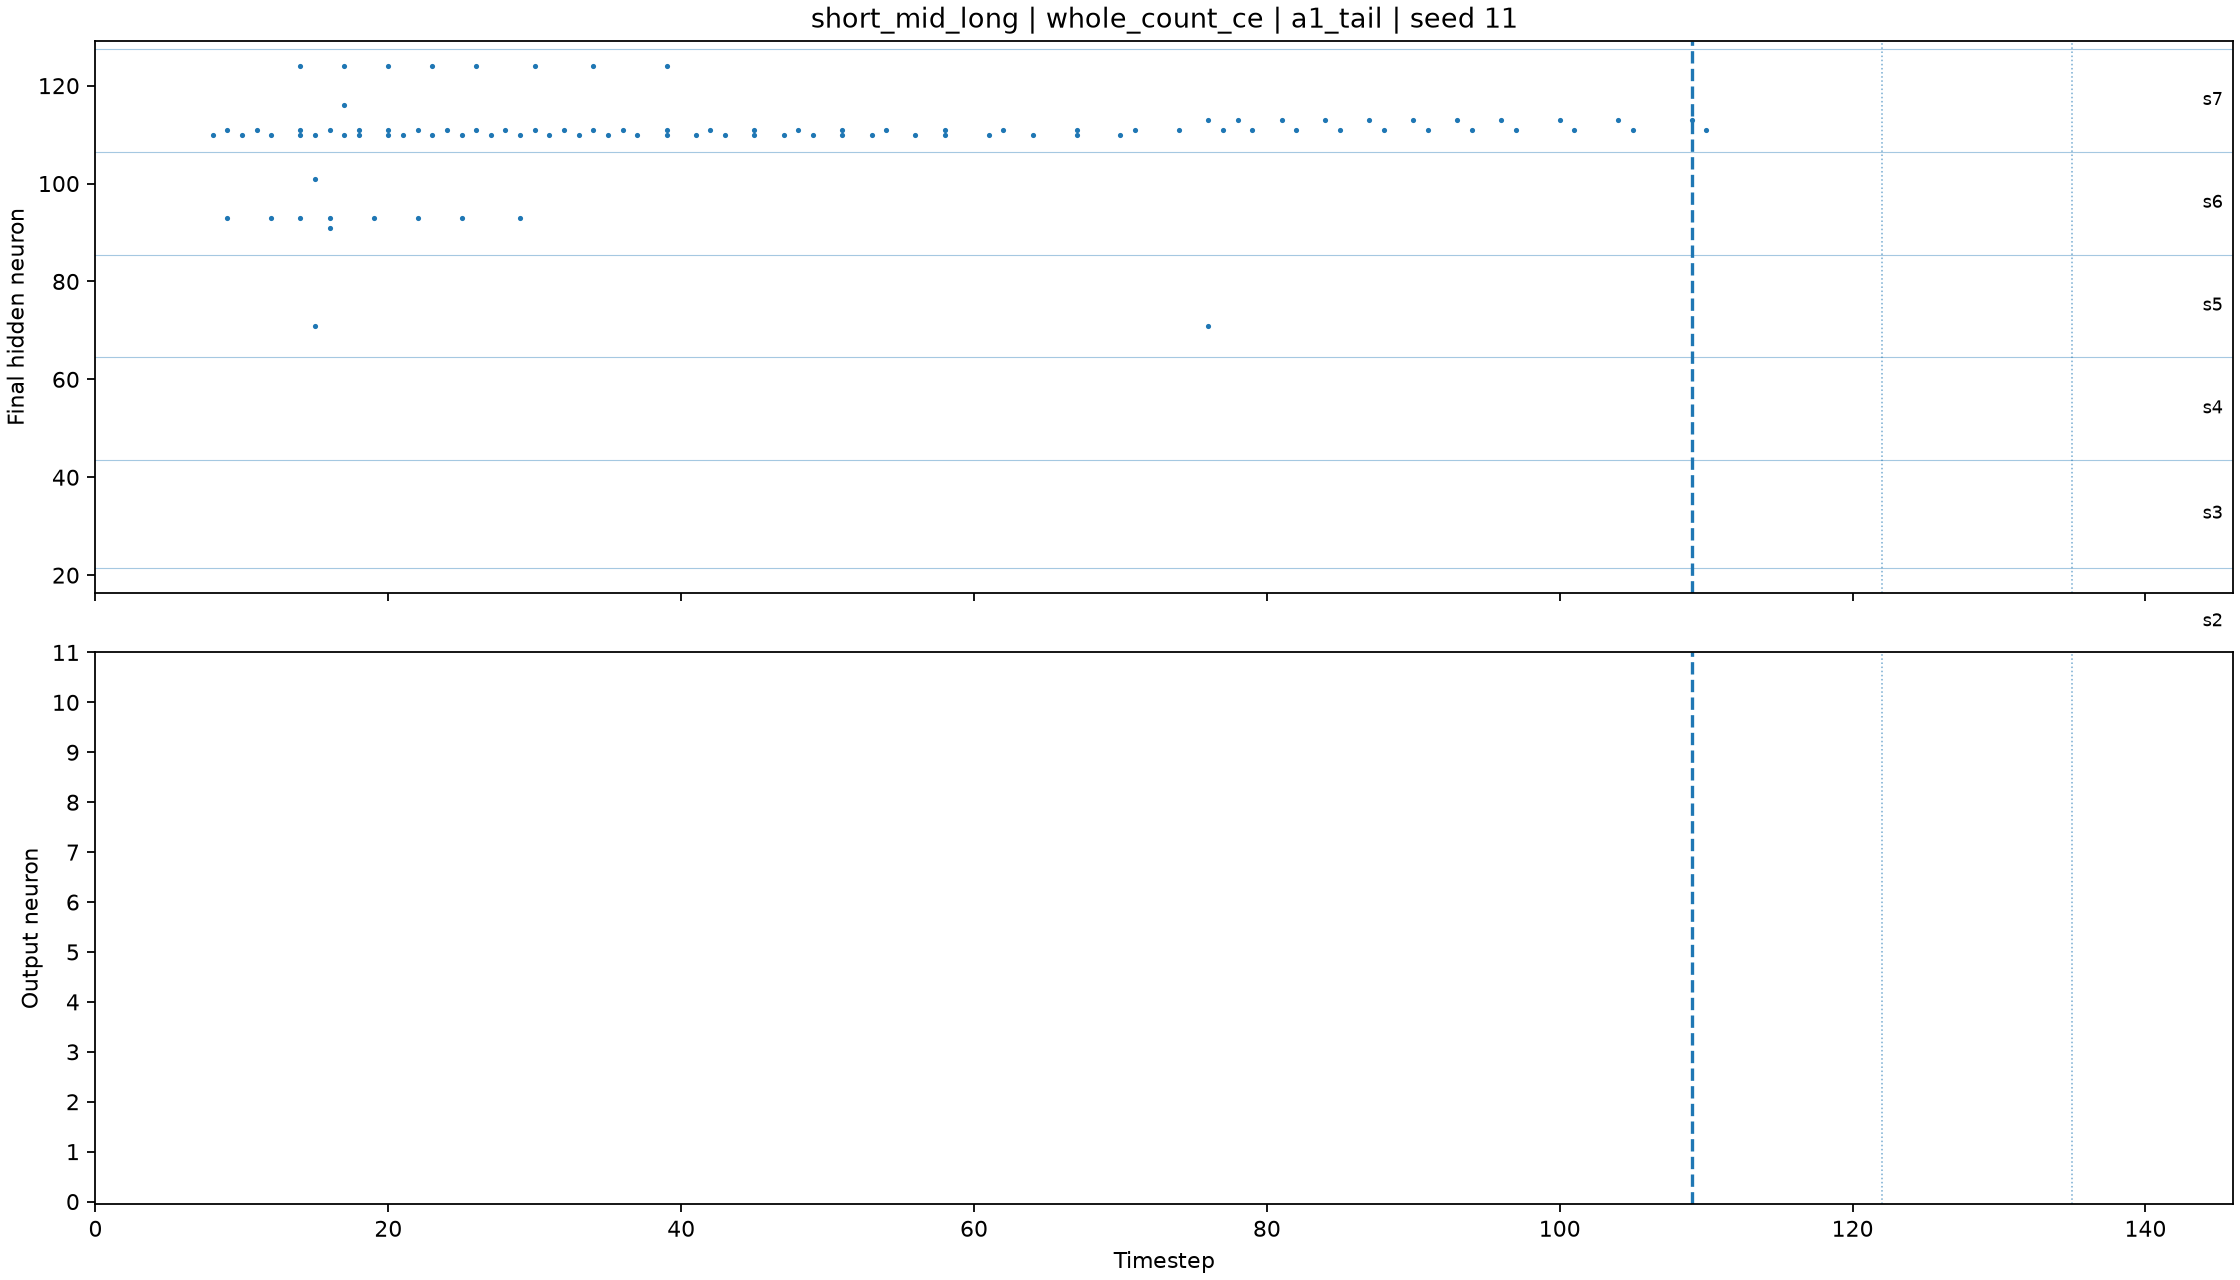

short_mid_long whole_count_ce none seed 11


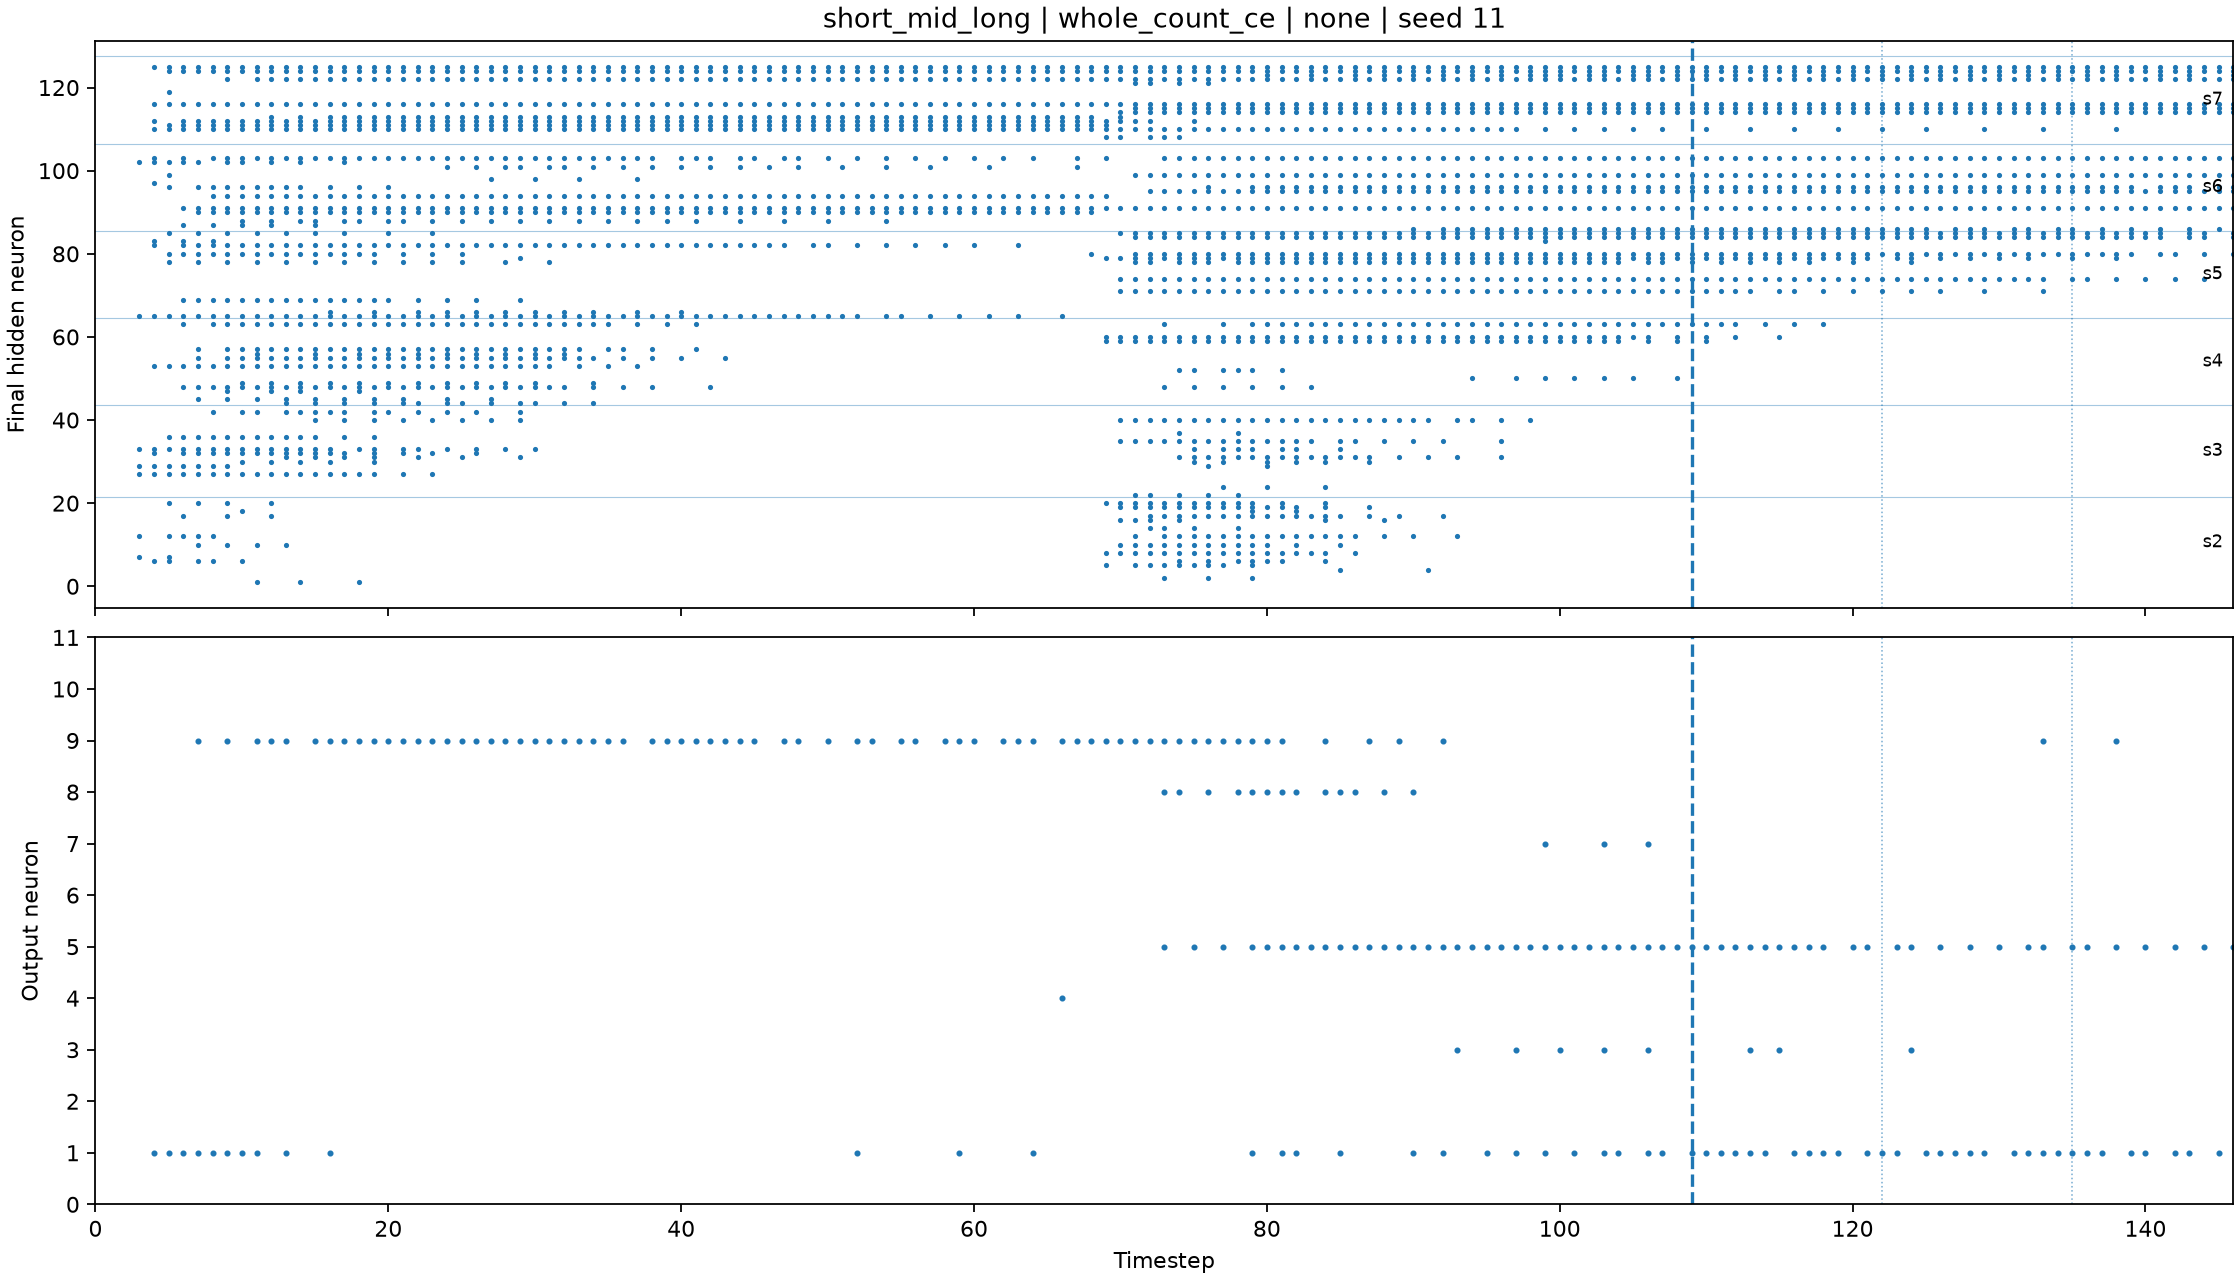

short_mid_long whole_count_ce tail seed 11


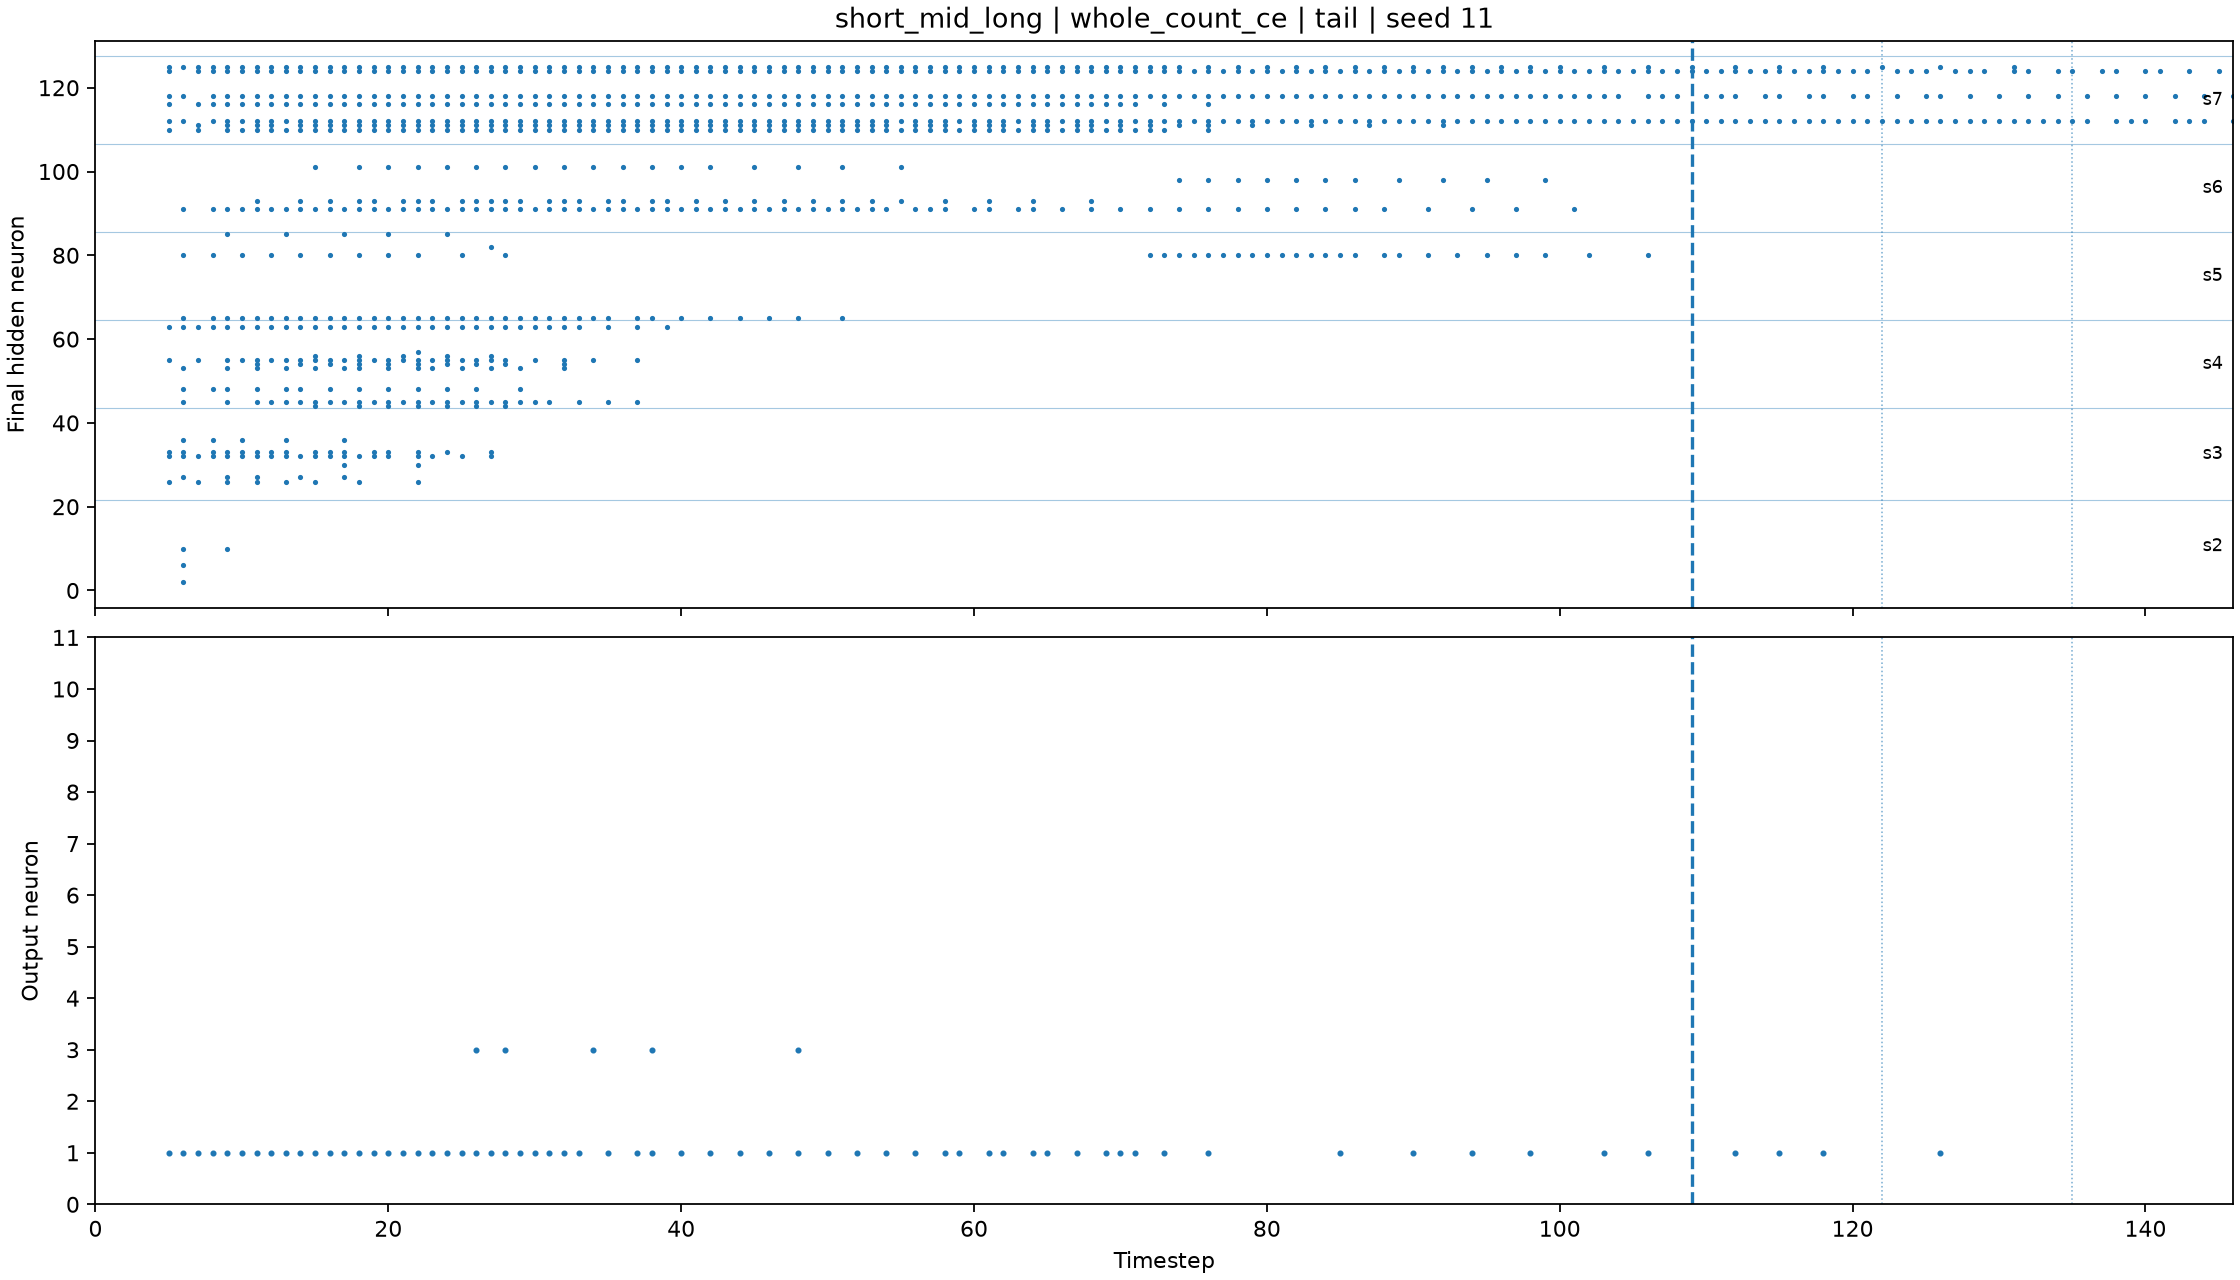

In [7]:
view = raster_index[raster_index['seed'] == DISPLAY_SEED].sort_values(['architecture', 'objective', 'profile'])
for row in view.itertuples(index=False):
    print(row.architecture, row.objective, row.profile, 'seed', row.seed)
    display(Image(filename=str(ARTIFACT_ROOT / row.raster_png)))
